**INTRODUCCION ANALISIS EXPLORATORIO DE DATOS**

El 15 de Abril de 1912 el Titanic se hundio luego de chocar con un Iceberg.

Murieron 1502 de los 2224 pasajeros y tripulantes.



**PassengerId:** Es el id del pasajero

**Survived:** Es la variable target que intentamos predecir(0 or 1)

1 = Sobrevivio 0 = No Sobrevivio

**Pclass: (Passenger Class)** es la clase socio-economica del pasajero y corresponde a una caracteristica ordinal categorica con solo 3 valores (1, 2 or 3):

1 = Clase Alta

2 = Clase Media

3 = Clase Baja

**Name, Sex and Age:** significado obvio

**SibSp:** Hermanos y esposa

**Parch:** Padres e hijos

**Ticket:** Numero de ticket del pasajero

**Fare:** Tarifa del pasaje

**Cabin:** numero de cabina del pasajero

**Embarked:** puerto de embarque es una caracteristica categorica con 3 unicos valores (C, Q or S):

C = Cherbourg Q = Queenstown S = Southampton

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
sns.set_style('darkgrid')
import matplotlib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold

import string
import warnings
warnings.filterwarnings('ignore')
SEED = 42

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def concat_df(train_data, test_data):
    # Returna un dataframe concatenado con los conjuntos de entrenamiento y prueba
    return pd.concat([train_data, test_data], sort=True).reset_index(drop=True)

def divide_df(all_data):
    # Returna dfs divididos de los conjuntos de entrenamiento y prueba
    return all_data.loc[:890], all_data.loc[891:].drop(['Survived'], axis=1)

#df_train = pd.read_csv('/content/drive/MyDrive/CTIC_UNI/DATA_SCIENCE/COURSE_01_MAY_2022/SESION01/titanic_train.csv')
#df_test = pd.read_csv('/content/drive/MyDrive/CTIC_UNI/DATA_SCIENCE/COURSE_01_MAY_2022/SESION01/titanic_test.csv')
df_train = pd.read_csv('/content/drive/MyDrive/titanic_train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/titanic_test.csv')
df_all = concat_df(df_train, df_test)

df_train.name = 'Conjunto de entrenamiento'
df_test.name = 'Conjunto de prueba'
df_all.name = 'Conjunto Total'

dfs = [df_train, df_test]
#print(df_test.shape)

print('Numero de ejemplos de entrenamiento = {}'.format(df_train.shape[0]))
print('Numero de features de entrenamiento = {}'.format(df_train.shape[1]))
print('Numero de ejemplos de prueba = {}\n'.format(df_test.shape[0]))
print('Entrenamiento X Shape = {}'.format(df_train.shape))
print('Entrenamiento y Shape = {}\n'.format(df_train['Survived'].shape[0]))
print('Prueba X Shape = {}'.format(df_test.shape))
print('Prueba y Shape = {}\n'.format(df_test.shape[0]))
print(df_train.columns)
print(df_test.columns)

Numero de ejemplos de entrenamiento = 891
Numero de features de entrenamiento = 12
Numero de ejemplos de prueba = 418

Entrenamiento X Shape = (891, 12)
Entrenamiento y Shape = 891

Prueba X Shape = (418, 11)
Prueba y Shape = 418

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [4]:
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [6]:
df_all

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket
0,22.0,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,1,3,male,1,0.0,A/5 21171
1,38.0,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1.0,PC 17599
2,26.0,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,3,female,0,1.0,STON/O2. 3101282
3,35.0,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1.0,113803
4,35.0,NaN,S,8.0500,"Allen, Mr. William Henry",0,5,3,male,0,0.0,373450
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,NaN,NaN,S,8.0500,"Spector, Mr. Woolf",0,1305,3,male,0,NaN,A.5. 3236
1305,39.0,C105,C,108.9000,"Oliva y Ocana, Dona. Fermina",0,1306,1,female,0,NaN,PC 17758
1306,38.5,NaN,S,7.2500,"Saether, Mr. Simon Sivertsen",0,1307,3,male,0,NaN,SOTON/O.Q. 3101262
1307,NaN,NaN,S,8.0500,"Ware, Mr. Frederick",0,1308,3,male,0,NaN,359309


**¿Cual es nuestro target?**

Quienes sobrevivieron y cual fue la razon de que sobrevivan. Como influyeron las diversas variables para la supervivencia de una persona.

In [7]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Asegúrate de que 'Survived' esté en las columnas del DataFrame
if 'Survived' in df_train.columns:
    # Asegúrate de que las columnas numéricas estén en el DataFrame
    numeric_columns = df_train.select_dtypes(include='number').columns

    if len(numeric_columns) > 1:  # Excluyendo 'Survived'
        group_means = df_train.groupby(['Survived'])[numeric_columns].mean()
        print(group_means)
    else:
        print("No hay suficientes columnas numéricas para calcular la media.")
else:
    print("La columna 'Survived' no se encuentra en el DataFrame.")


          PassengerId  Survived    Pclass        Age     SibSp     Parch  \
Survived                                                                   
0          447.016393       0.0  2.531876  30.626179  0.553734  0.329690   
1          444.368421       1.0  1.950292  28.343690  0.473684  0.464912   

               Fare  
Survived             
0         22.117887  
1         48.395408  


In [9]:
numeric_columns = df_train.select_dtypes(include='number').columns
df_train.groupby(['Survived'])[numeric_columns].mean() # 0->No sobrevivieron 1->Sobrevivieron

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,,,,,,,
0,447.016393,0.0,2.531876,30.626179,0.553734,0.329690,22.117887
1,444.368421,1.0,1.950292,28.343690,0.473684,0.464912,48.395408


In [10]:
df_train.groupby(['Survived']).count() # 0->No sobrevivieron 1->Sobrevivieron

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Survived,,,,,,,,,,,
0,549,549,549,549,424,549,549,549,549,68,549
1,342,342,342,342,290,342,342,342,342,136,340


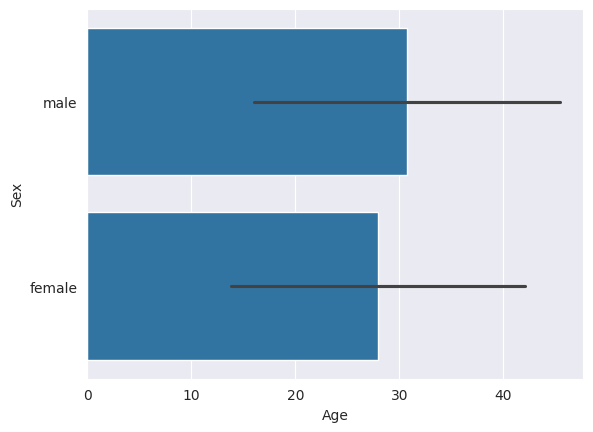

In [11]:
sns.barplot(x=df_train['Age'], y=df_train['Sex'], ci = 'sd') #intervalo de confianza puede ser None o un flotante
plt.show()

In [12]:
df_train.groupby(['Sex'])[numeric_columns].mean() #Sex es categorica



,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
Sex,,,,,,,
female,431.028662,0.742038,2.159236,27.915709,0.694268,0.649682,44.479818
male,454.147314,0.188908,2.389948,30.726645,0.429809,0.235702,25.523893


In [13]:
df_train.groupby(['Sex'])[numeric_columns].std()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
Sex,,,,,,,
female,256.846324,0.438211,0.85729,14.110146,1.156520,1.022846,57.997698
male,257.486139,0.391775,0.81358,14.678201,1.061811,0.612294,43.138263


Text(0, 0.5, 'Cantidad de Pasajeros')

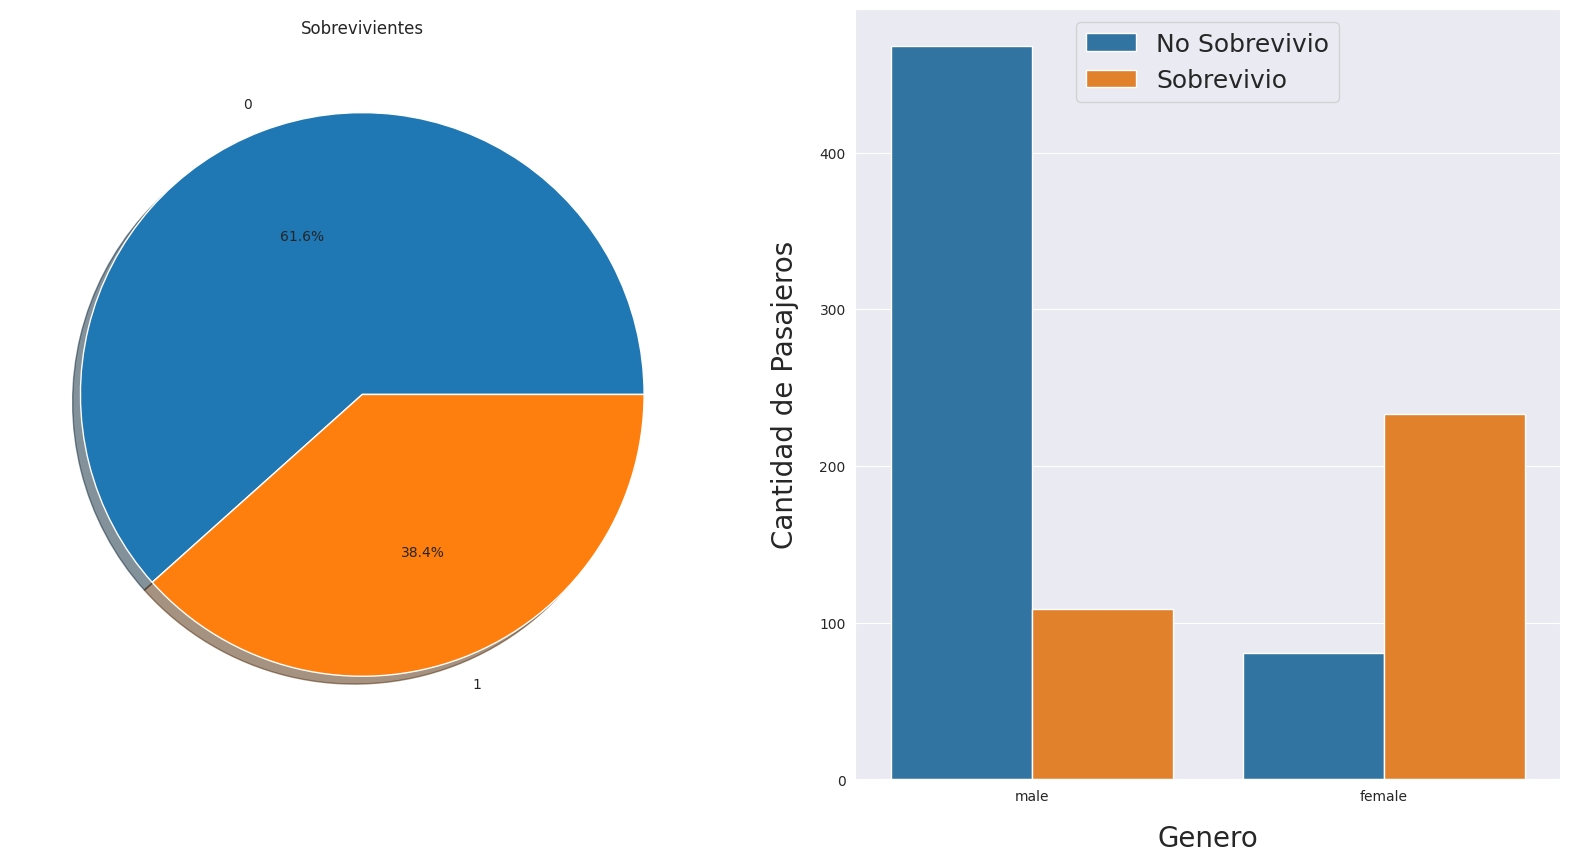

In [14]:
fig, axs = plt.subplots(1, 2, figsize = (20, 10)) #En una fila dos graficos
df_train['Survived'] .value_counts()
df_train['Survived'] .value_counts().plot.pie(autopct = '%1.1f%%', ax =axs[0], shadow = True)

axs[0].set_title('Sobrevivientes')
axs[0].set_ylabel('')

#sns.countplot('Sex', hue = 'Survived', data = df_train, ax = axs[1])
sns.countplot(x='Sex', hue='Survived', data=df_train, ax = axs[1]) #Se agrupa por Survived
plt.legend(['No Sobrevivio', 'Sobrevivio'], loc='upper center', prop={'size': 18})
plt.xlabel('Genero', size=20, labelpad=15)
plt.ylabel('Cantidad de Pasajeros', size=20, labelpad=15)


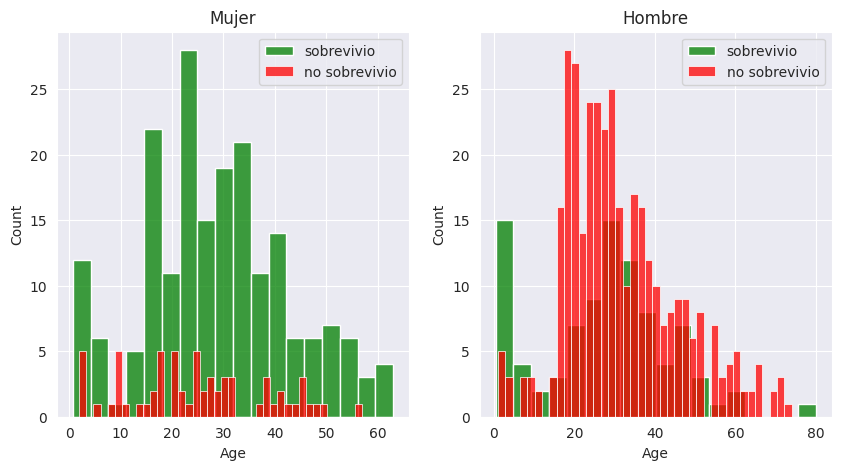

In [15]:
sobrevivio = 'sobrevivio'
no_sobrevivio = 'no sobrevivio'

fig, axes = plt.subplots(nrows=1, ncols=2, figsize = (10, 5)) #En una fila dos graficos
mujeres = df_train[df_train['Sex'] == 'female']
hombres = df_train[df_train['Sex'] == 'male']

ax = sns.histplot(mujeres[mujeres['Survived'] == 1].Age.dropna(), bins=18, label=sobrevivio, color='green', ax=axes[0], kde=False)
ax = sns.histplot(mujeres[mujeres['Survived'] == 0].Age.dropna(), bins=40, label=no_sobrevivio, color='red', ax=axes[0], kde=False)
ax.legend()
ax.set_title('Mujer')

ax = sns.histplot(hombres[hombres['Survived'] == 1].Age.dropna(), bins=18, label=sobrevivio, color='green', ax=axes[1], kde=False)
ax = sns.histplot(hombres[hombres['Survived'] == 0].Age.dropna(), bins=40, label=no_sobrevivio, color='red', ax=axes[1], kde=False)
ax.legend()
_ = ax.set_title('Hombre')


**I ANALISIS DE VARIABLES O CARACTERISTICAS:**

Analizemos las caracteristicas de algunas variables, identifiquemos su tipo y su impacto en la supervicencia.

Variable categorica: Sexo o Genero (Sex)

Variable ordinal: Clase (Pclass)

Variable continua: Edad (Age)


**SEX**

In [16]:
df_all['PassengerId'].count()

1309

In [17]:
df_train['PassengerId'].count()

891

In [18]:
df_test['PassengerId'].count()

418

In [19]:
df_train['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [20]:
df_all.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0.0          81
        1.0         233
male    0.0         468
        1.0         109
Name: Survived, dtype: int64

        Survived
Sex             
female  0.742038
male    0.188908


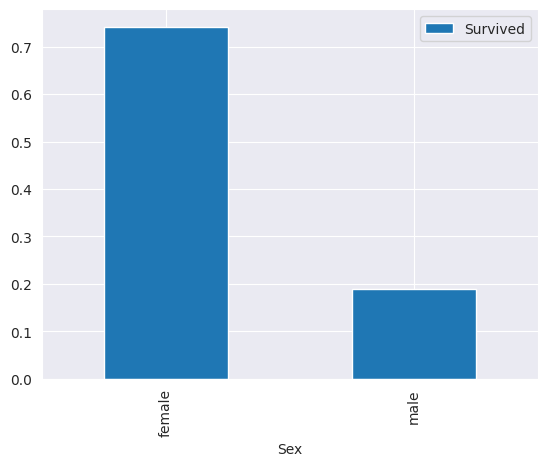

In [21]:
#Promedio de hombres y mujeres sobrevivientes
#Observemos que Sex aun la manejamos como variable categorica
print(df_all[['Sex','Survived']].groupby('Sex').mean())
df_all[['Sex','Survived']].groupby(['Sex']).mean().plot.bar()
plt.show()

**PCLASS**

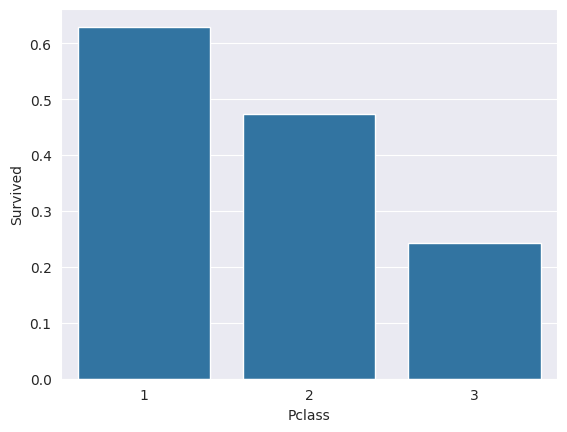

In [22]:
sns.barplot(data=df_all, x='Pclass', y='Survived', ci = None)
plt.show()

In [23]:
pd.crosstab(df_all['Pclass'],df_all['Survived'], margins=True).style.background_gradient(cmap = 'Greens')

Survived,0.000000,1.000000,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


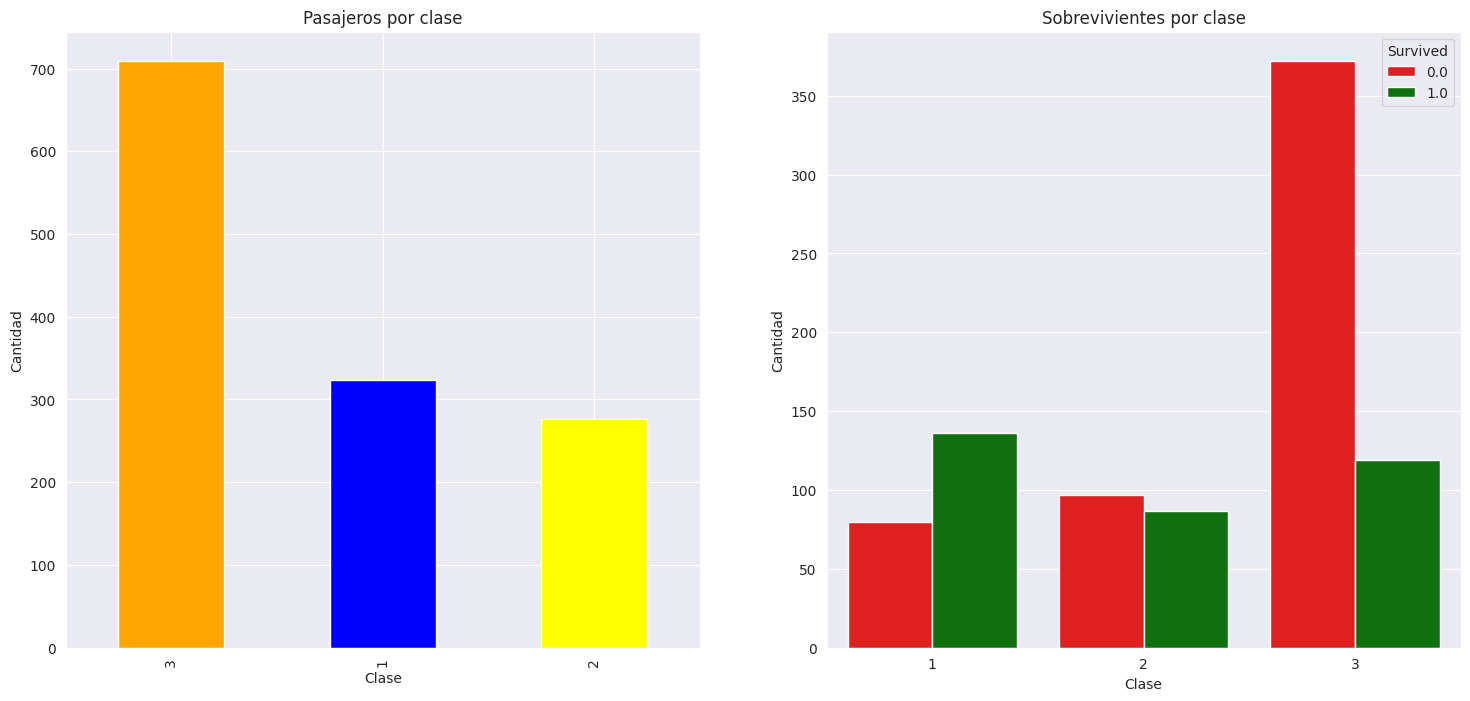

In [24]:
fig, axs = plt.subplots(1, 2, figsize = (18, 8))
df_all['Pclass'] .value_counts().plot.bar(ax =axs[0], color = ['orange', 'blue', 'yellow'])
axs[0].set_title('Pasajeros por clase')
axs[0].set_xlabel('Clase')
axs[0].set_ylabel('Cantidad')

sns.countplot(x='Pclass', hue = 'Survived', data = df_all, ax = axs[1], palette=['red',"green"])
axs[1].set_title('Sobrevivientes por clase')
axs[1].set_xlabel('Clase')
axs[1].set_ylabel('Cantidad')

plt.show()

**IMPACTO DEL SEXO Y LA CLASE:**

In [25]:
pd.crosstab([df_all['Sex'], df_all['Survived']], df_all['Pclass'], margins = False).style.background_gradient(cmap = 'summer_r')

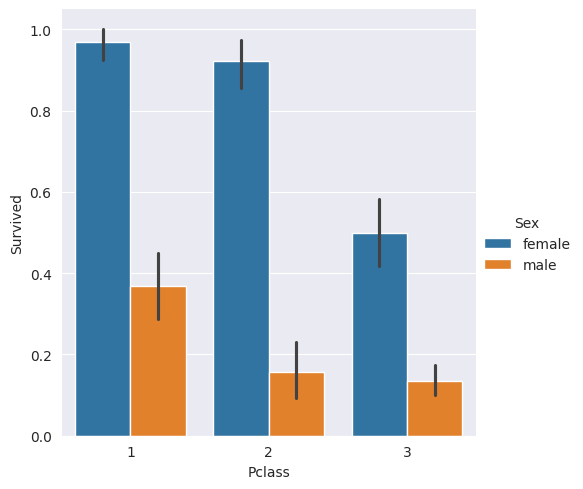

In [26]:
#sns.factorplot('Pclass','Survived', hue = 'Sex', data = df_all)
sns.catplot(x='Pclass', y='Survived', hue='Sex', data=df_all, kind='bar')

plt.show()

**EDAD**

In [27]:
df_train['Age'].value_counts().to_frame().style.background_gradient(cmap = 'BuPu')

,count
Age,
24.000000,30
22.000000,27
18.000000,26
19.000000,25
28.000000,25
30.000000,25
21.000000,24
25.000000,23
36.000000,22


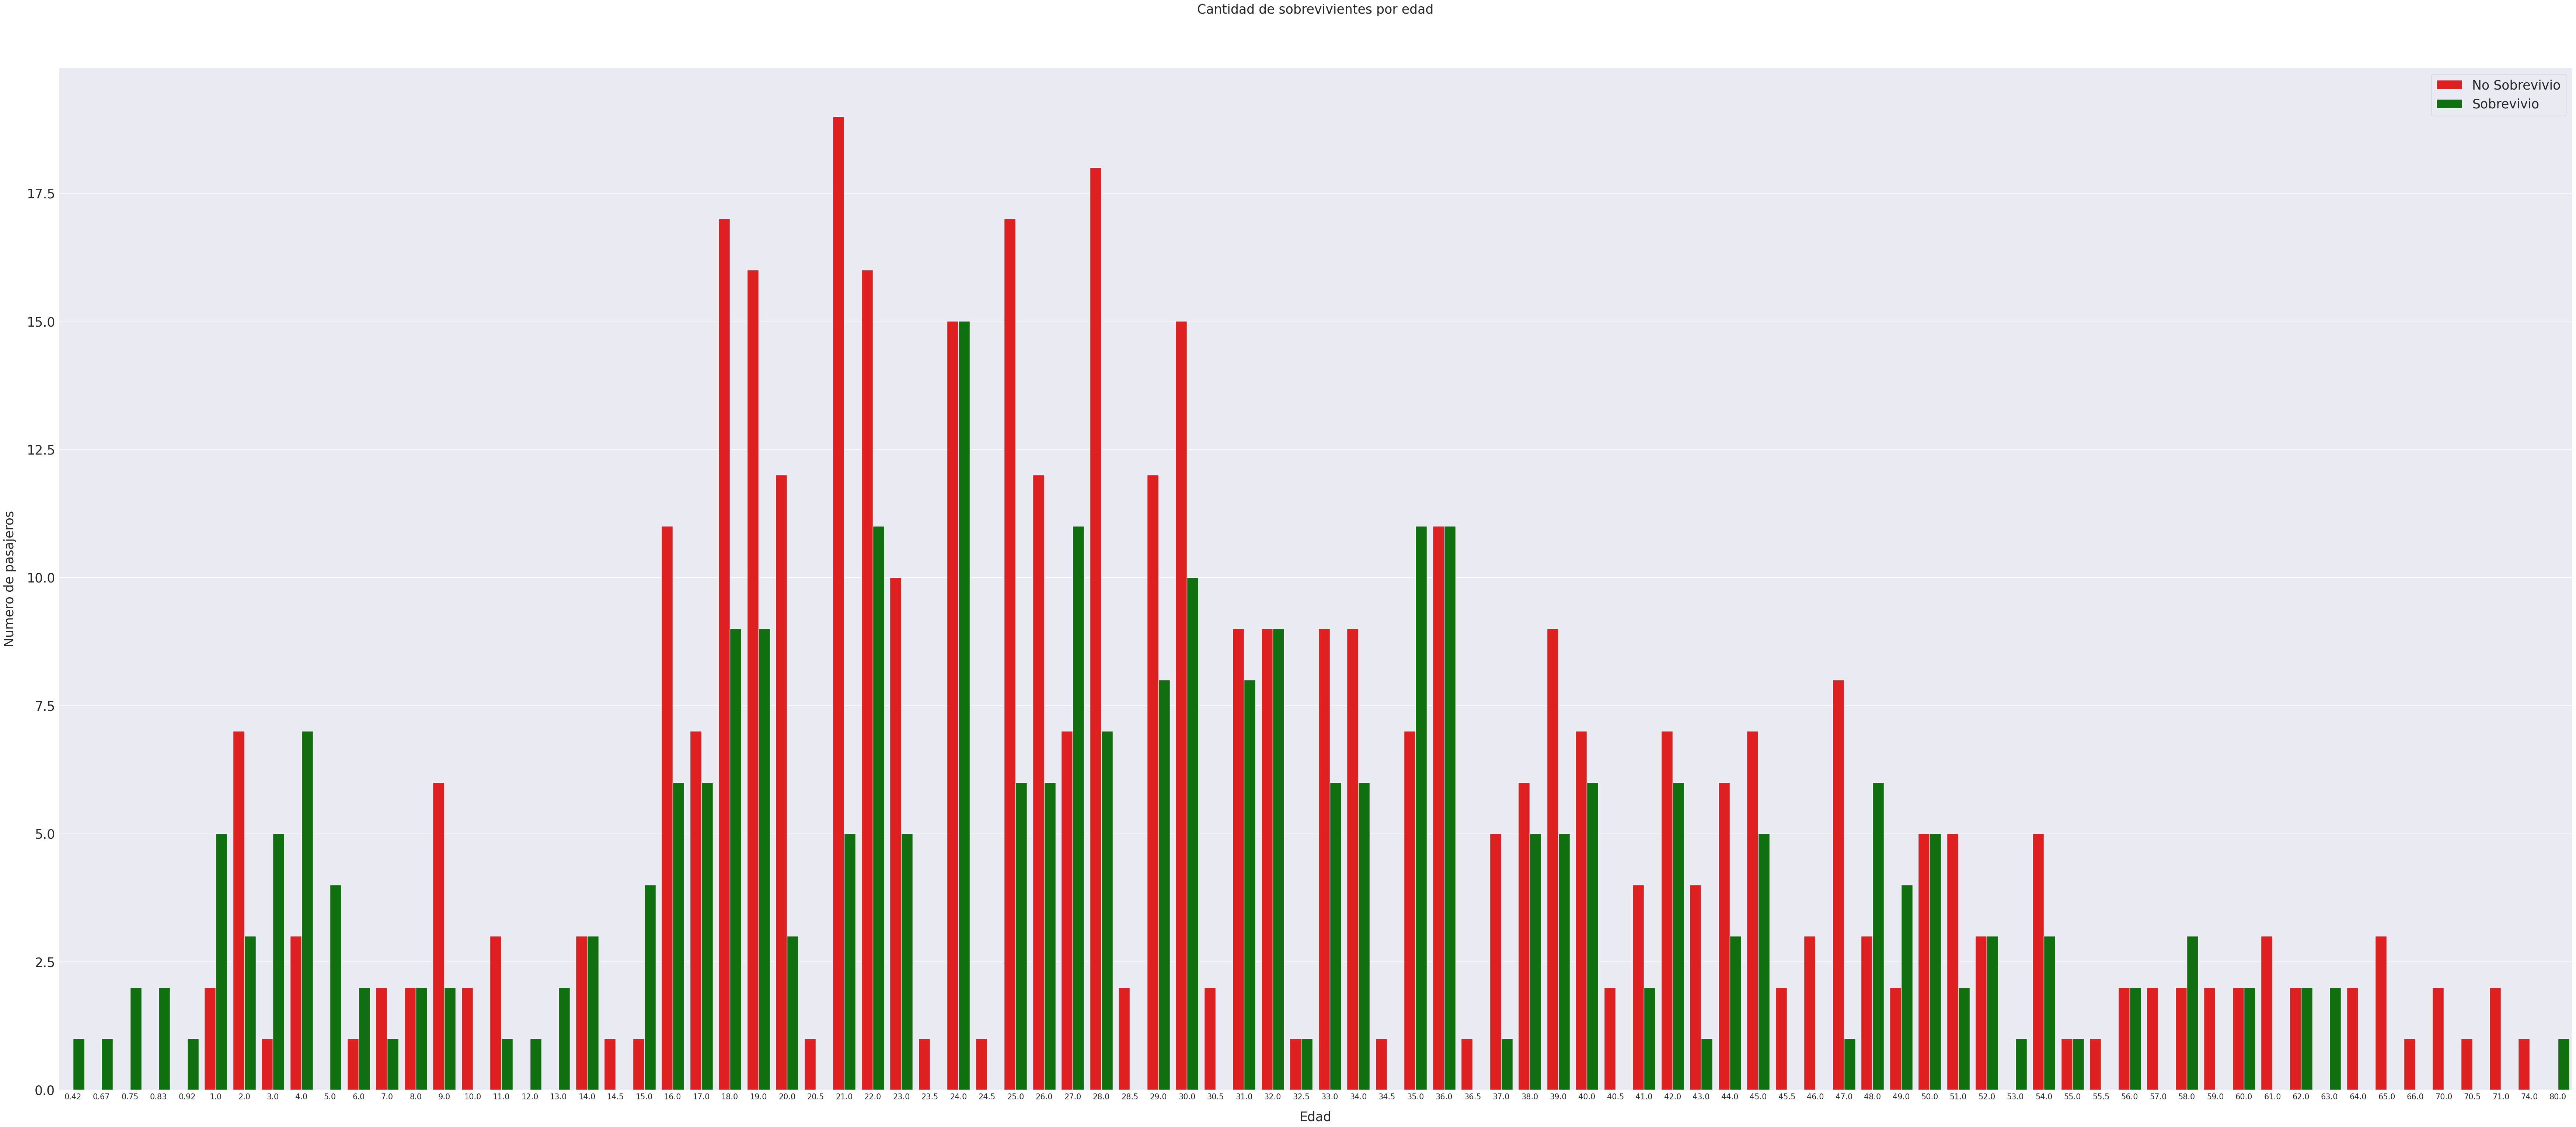

In [28]:
fig, axs = plt.subplots(figsize=(88, 36))

sns.countplot(x='Age', hue='Survived', data=df_train, palette=['red',"green"])

plt.xlabel('Edad', size=25, labelpad=20)
plt.ylabel('Numero de pasajeros', size=25, labelpad=20)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=25)

plt.legend(['No Sobrevivio', 'Sobrevivio'], loc='upper right', prop={'size': 25})
plt.title('Cantidad de sobrevivientes por edad', size=25, y=1.05)

plt.show()

In [29]:
#df_all.loc[df_all['Age'] <= 15, 'Age']

In [30]:

df_all['age_cat'] = 0
df_all.loc[df_all['Age'] <= 15, 'age_cat'] = 0
df_all.loc[(df_all['Age'] > 15) & (df_all['Age'] <= 30), 'age_cat'] = 1
df_all.loc[(df_all['Age'] > 30) & (df_all['Age'] <= 45), 'age_cat'] = 2
df_all.loc[(df_all['Age'] > 45) & (df_all['Age'] <= 60), 'age_cat'] = 3
df_all.loc[(df_all['Age'] > 60) & (df_all['Age'] <= 75), 'age_cat'] = 4
df_all.loc[df_all['Age'] > 75, 'age_cat'] = 5

df_train['age_cat'] = 0
df_train.loc[df_train['Age'] <= 15, 'age_cat'] = 0
df_train.loc[(df_train['Age'] > 15) & (df_train['Age'] <= 30), 'age_cat'] = 1
df_train.loc[(df_train['Age'] > 30) & (df_train['Age'] <= 45), 'age_cat'] = 2
df_train.loc[(df_train['Age'] > 45) & (df_train['Age'] <= 60), 'age_cat'] = 3
df_train.loc[(df_train['Age'] > 60) & (df_train['Age'] <= 75), 'age_cat'] = 4
df_train.loc[df_train['Age'] > 75, 'age_cat'] = 5

df_all.head(10)


,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket,age_cat
0,22.0,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,1,3,male,1,0.0,A/5 21171,1
1,38.0,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1.0,PC 17599,2
2,26.0,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,3,female,0,1.0,STON/O2. 3101282,1
3,35.0,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1.0,113803,2
4,35.0,NaN,S,8.0500,"Allen, Mr. William Henry",0,5,3,male,0,0.0,373450,2
5,NaN,NaN,Q,8.4583,"Moran, Mr. James",0,6,3,male,0,0.0,330877,0
6,54.0,E46,S,51.8625,"McCarthy, Mr. Timothy J",0,7,1,male,0,0.0,17463,3
7,2.0,NaN,S,21.0750,"Palsson, Master. Gosta Leonard",1,8,3,male,3,0.0,349909,0
8,27.0,NaN,S,11.1333,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",2,9,3,female,0,1.0,347742,1
9,14.0,NaN,C,30.0708,"Nasser, Mrs. Nicholas (Adele Achem)",0,10,2,female,1,1.0,237736,0


In [31]:
df_all['age_cat'].value_counts().to_frame().style.background_gradient(cmap = 'BuPu')

,count
age_cat,
1,494
0,378
2,282
3,122
4,31
5,2


In [32]:
df_train['age_cat'].value_counts().to_frame().style.background_gradient(cmap = 'BuPu')

,count
age_cat,
1,326
0,260
2,202
3,81
4,21
5,1


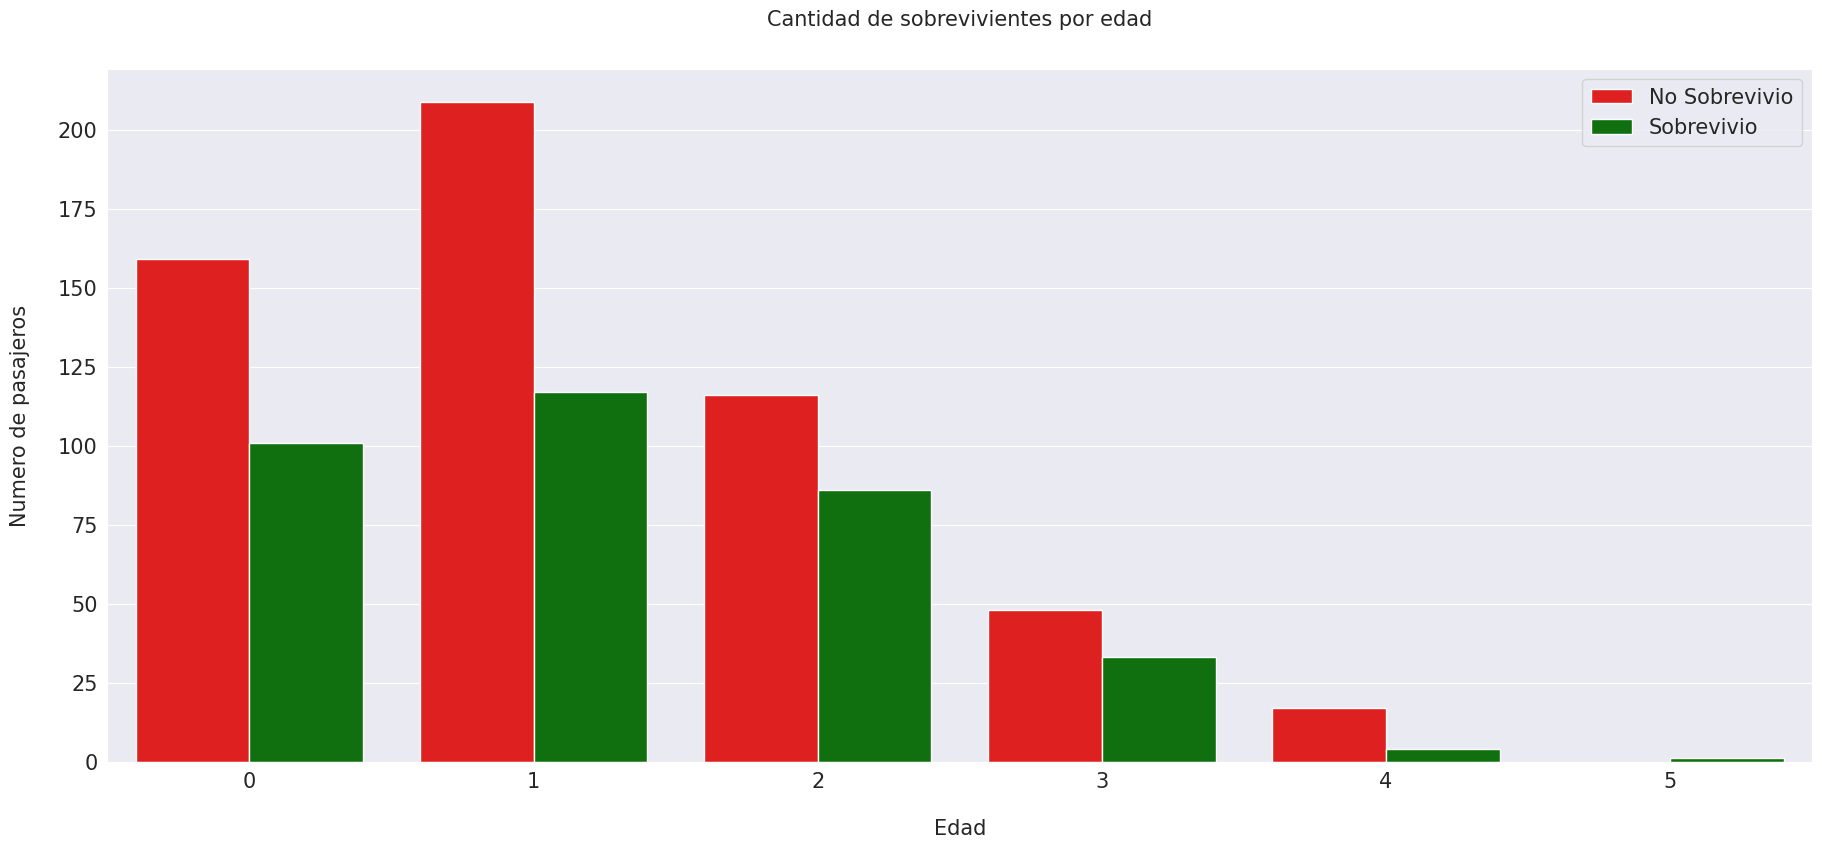

In [33]:
fig, axs = plt.subplots(figsize=(22, 9))

#sns.countplot(x='Age', hue='Survived', data=df_all, palette=['red',"green"])
sns.countplot(x='age_cat', hue='Survived', data=df_train, palette=['red',"green"])

plt.xlabel('Edad', size=15, labelpad=20)
plt.ylabel('Numero de pasajeros', size=15, labelpad=20)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)

plt.legend(['No Sobrevivio', 'Sobrevivio'], loc='upper right', prop={'size': 15})
plt.title('Cantidad de sobrevivientes por edad', size=15, y=1.05)

plt.show()

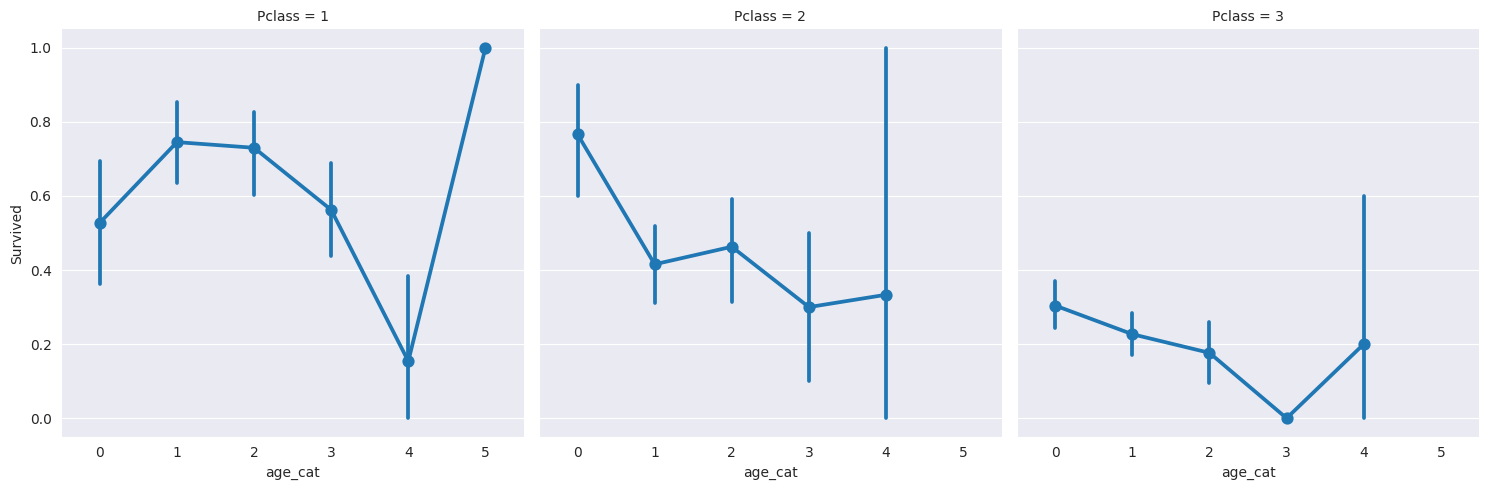

In [34]:
#sns.factorplot('age_cat', 'Survived', data=df_train, col='Pclass')
sns.catplot(x='age_cat', y='Survived', data=df_train, col='Pclass', kind='point')

plt.show()

**Fare**

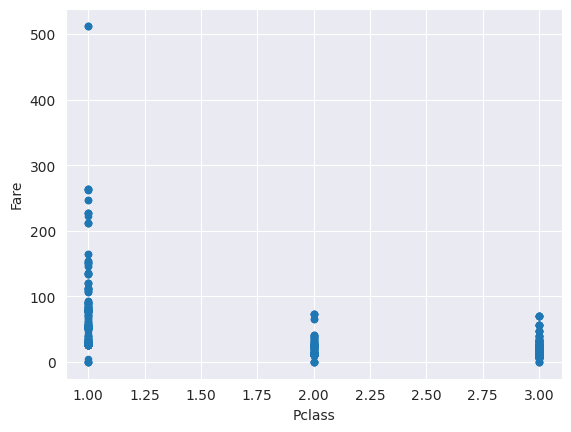

In [35]:
# diagrama de dispersión
disp= df_train.plot(kind='scatter', x='Pclass', y='Fare')

In [36]:
df_all['fare_range'] = pd.qcut(df_all['Fare'], 13)
df_all.groupby(['fare_range'])['Survived'].mean().to_frame().style.background_gradient('summer_r')


,Survived
fare_range,
"(-0.001, 7.25]",0.132530
"(7.25, 7.75]",0.315789
"(7.75, 7.896]",0.180723
"(7.896, 8.05]",0.225806
"(8.05, 10.5]",0.230769
"(10.5, 13.0]",0.461538
"(13.0, 15.742]",0.326531
"(15.742, 23.25]",0.529412
"(23.25, 26.55]",0.467532


In [37]:
df_all['fare_cat'] = 0
df_all.loc[df_all['Fare'] <= 7.229, 'fare_cat'] = 0
df_all.loc[(df_all['Fare'] > 7.229) & (df_all['Fare'] <= 7.75), 'fare_cat'] = 1
df_all.loc[(df_all['Fare'] > 7.75) & (df_all['Fare'] <= 7.896), 'fare_cat'] = 2
df_all.loc[(df_all['Fare'] > 7.896) & (df_all['Fare'] <= 8.05), 'fare_cat'] = 3
df_all.loc[(df_all['Fare'] > 8.05) & (df_all['Fare'] <= 10.5), 'fare_cat'] = 4
df_all.loc[(df_all['Fare'] > 10.5) & (df_all['Fare'] <= 13.0), 'fare_cat'] = 5
df_all.loc[(df_all['Fare'] > 13.0) & (df_all['Fare'] <= 15.85), 'fare_cat'] = 6
df_all.loc[(df_all['Fare'] > 15.85) & (df_all['Fare'] <= 24.0), 'fare_cat'] = 7
df_all.loc[(df_all['Fare'] > 24.0) & (df_all['Fare'] <=  26.55), 'fare_cat'] = 8
df_all.loc[(df_all['Fare'] > 26.55) & (df_all['Fare'] <= 33.308), 'fare_cat'] = 9
df_all.loc[(df_all['Fare'] > 33.308) & (df_all['Fare'] <= 55.9), 'fare_cat'] = 10
df_all.loc[(df_all['Fare'] > 55.9) & (df_all['Fare'] <= 83.158), 'fare_cat'] = 11
df_all.loc[(df_all['Fare'] > 83.158) & (df_all['Fare'] <= 512.329), 'fare_cat'] = 12


#df_all.head(10)

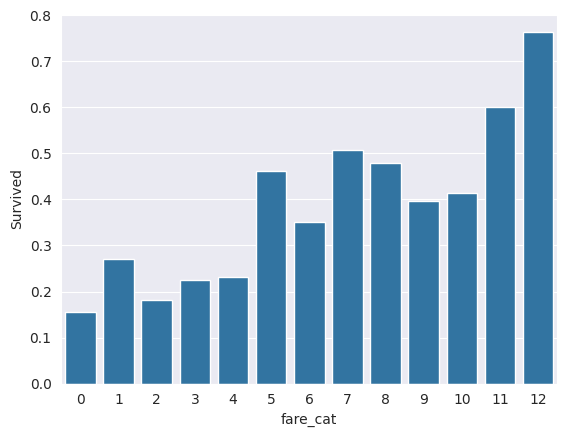

In [38]:
sns.barplot(data=df_all, x='fare_cat', y='Survived', ci = None)
plt.show()

In [39]:
tar12 = df_all.loc[df_all['fare_cat'] == 12]
tar12 = tar12[['Fare', 'fare_cat','Survived']]
print(tar12)

          Fare  fare_cat  Survived
27    263.0000        12       0.0
31    146.5208        12       1.0
62     83.4750        12       0.0
88    263.0000        12       1.0
118   247.5208        12       0.0
...        ...       ...       ...
1281   93.5000        12       NaN
1291  164.8667        12       NaN
1298  211.5000        12       NaN
1302   90.0000        12       NaN
1305  108.9000        12       NaN

[104 rows x 3 columns]


In [40]:
tar12.describe()

,Fare,fare_cat,Survived
count,104.000000,104.0,68.000000
mean,157.004686,12.0,0.764706
std,61.876426,0.0,0.427336
min,83.158300,12.0,0.000000
25%,106.425000,12.0,1.000000
50%,136.206250,12.0,1.000000
75%,211.500000,12.0,1.000000
max,263.000000,12.0,1.000000


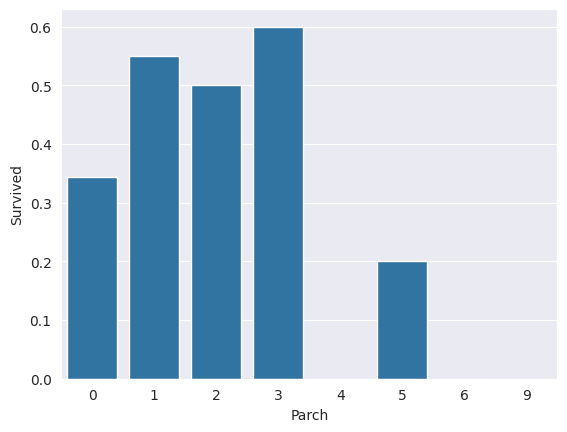

In [41]:
sns.barplot(data=df_all, x='Parch', y='Survived', ci = None)
plt.show()

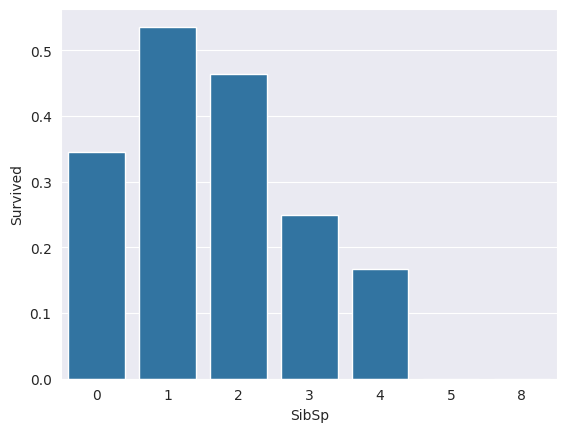

In [42]:
sns.barplot(data=df_all, x='SibSp', y='Survived', ci = None)
plt.show()

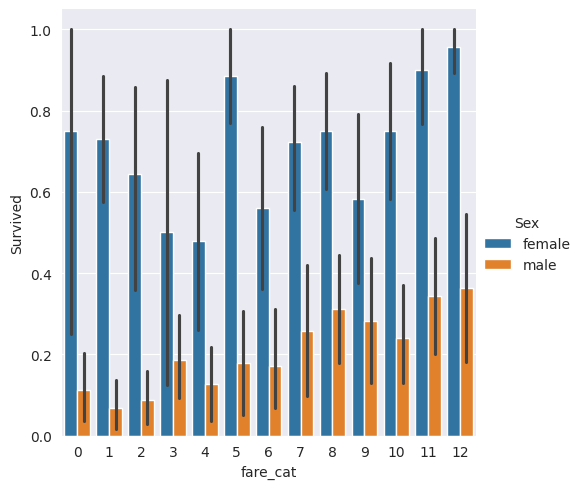

In [43]:
#sns.factorplot('fare_cat', 'Survived', data=df_all, hue='Sex')
sns.catplot(x='fare_cat', y='Survived', hue='Sex', data=df_all, kind='bar')

plt.show()

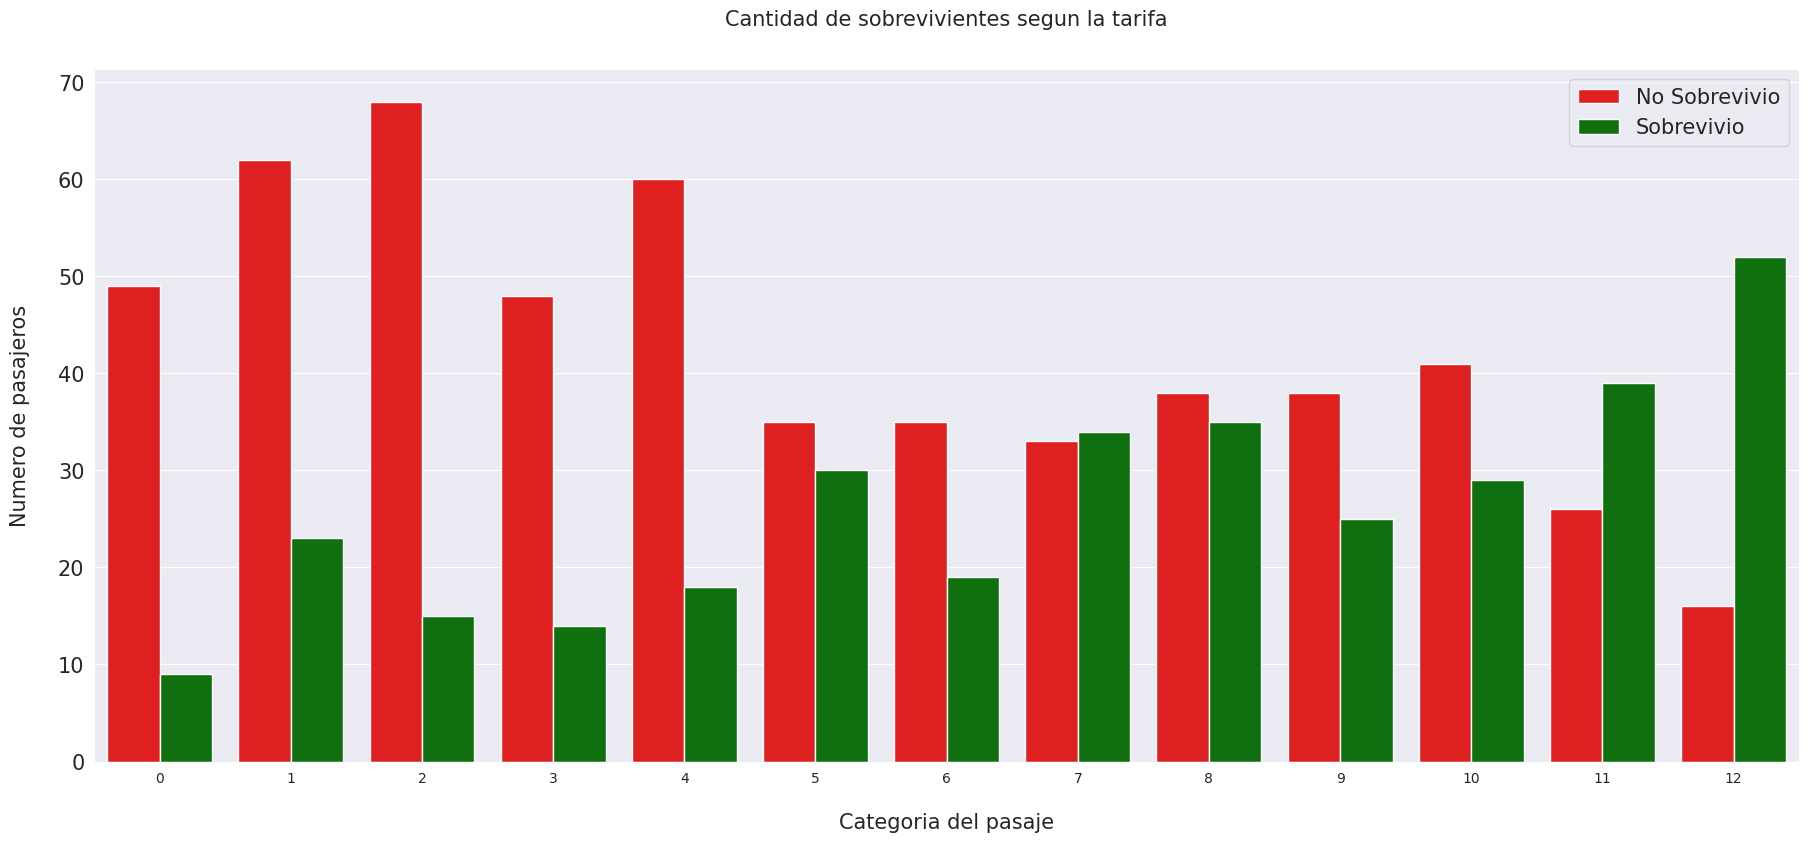

In [44]:
fig, axs = plt.subplots(figsize=(22, 9))
sns.countplot(x='fare_cat', hue='Survived', data=df_all, palette=['red',"green"])

plt.xlabel('Categoria del pasaje', size=15, labelpad=20)
plt.ylabel('Numero de pasajeros', size=15, labelpad=20)
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=15)

plt.legend(['No Sobrevivio', 'Sobrevivio'], loc='upper right', prop={'size': 15})
plt.title('Cantidad de sobrevivientes segun la tarifa', size=15, y=1.05)

plt.show()

In [45]:
df_all.head()

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket,age_cat,fare_range,fare_cat
0,22.0,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,1,3,male,1,0.0,A/5 21171,1,"(-0.001, 7.25]",1
1,38.0,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1.0,PC 17599,2,"(56.496, 83.475]",11
2,26.0,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,3,female,0,1.0,STON/O2. 3101282,1,"(7.896, 8.05]",3
3,35.0,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1.0,113803,2,"(34.157, 56.496]",10
4,35.0,NaN,S,8.0500,"Allen, Mr. William Henry",0,5,3,male,0,0.0,373450,2,"(7.896, 8.05]",3


**II MISSING VALUES**

Es conveniente trabajar en conjuntos de prueba y entrenamiento concatenados mientras se trabaja con valores faltantes; de lo contrario, los datos completos pueden sobreajustarse a las muestras del conjunto de prueba o entrenamiento.

In [46]:
total_datos_perdidos = df_train.isnull().sum().sort_values(ascending=False)
print(total_datos_perdidos)


Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
age_cat          0
dtype: int64


In [47]:
porc_perdidos = (df_train.isnull().sum()/df_train.isnull().count())*100
print(porc_perdidos)


PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
age_cat         0.000000
dtype: float64


In [48]:
round_porc_perdidos = (round(porc_perdidos, 2)).sort_values(ascending=False)
print(round_porc_perdidos)


Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
age_cat         0.00
dtype: float64


In [49]:
datos_perdidos = pd.concat([total_datos_perdidos, porc_perdidos], axis=1, keys=['Datos Perdidos','Porcentaje de Datos Perdidos'])
datos_perdidos.head(3)

,Datos Perdidos,Porcentaje de Datos Perdidos
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


In [50]:
df_train.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,age_cat
0,False,False,False,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False


In [51]:
df_train.isnull().mean()  #Porque usamos mean?

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.198653
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [52]:
#print(df_train.info())
df_train.sample(100, random_state = None)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,age_cat
433,434,0,3,"Kallio, Mr. Nikolai Erland",male,17.0,0,0,STON/O 2. 3101274,7.1250,NaN,S,1
94,95,0,3,"Coxon, Mr. Daniel",male,59.0,0,0,364500,7.2500,NaN,S,3
63,64,0,3,"Skoog, Master. Harald",male,4.0,3,2,347088,27.9000,NaN,S,0
350,351,0,3,"Odahl, Mr. Nils Martin",male,23.0,0,0,7267,9.2250,NaN,S,1
235,236,0,3,"Harknett, Miss. Alice Phoebe",female,NaN,0,0,W./C. 6609,7.5500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,599,0,3,"Boulos, Mr. Hanna",male,NaN,0,0,2664,7.2250,NaN,C,0
440,441,1,2,"Hart, Mrs. Benjamin (Esther Ada Bloomfield)",female,45.0,1,1,F.C.C. 13529,26.2500,NaN,S,2
512,513,1,1,"McGough, Mr. James Robert",male,36.0,0,0,PC 17473,26.2875,E25,S,2
309,310,1,1,"Francatelli, Miss. Laura Mabel",female,30.0,0,0,PC 17485,56.9292,E36,C,1


In [53]:
df_test.isnull().mean()

,0
PassengerId,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.205742
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.002392
Cabin,0.782297


In [54]:
#print(df_test.info())
df_test.sample(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
122,1014,1,"Schabert, Mrs. Paul (Emma Mock)",female,35.0,1,0,13236,57.7500,C28,C
277,1169,2,"Faunthorpe, Mr. Harry",male,40.0,1,0,2926,26.0000,NaN,S
320,1212,3,"Andersson, Mr. Johan Samuel",male,26.0,0,0,347075,7.7750,NaN,S
394,1286,3,"Kink-Heilmann, Mr. Anton",male,29.0,3,1,315153,22.0250,NaN,S
313,1205,3,"Carr, Miss. Jeannie",female,37.0,0,0,368364,7.7500,NaN,Q
391,1283,1,"Lines, Mrs. Ernest H (Elizabeth Lindsey James)",female,51.0,0,1,PC 17592,39.4000,D28,S
249,1141,3,"Khalil, Mrs. Betros (Zahie Maria"" Elias)""",female,NaN,1,0,2660,14.4542,NaN,C
52,944,2,"Hocking, Miss. Ellen Nellie""""",female,20.0,2,1,29105,23.0000,NaN,S
56,948,3,"Cor, Mr. Bartol",male,35.0,0,0,349230,7.8958,NaN,S
66,958,3,"Burns, Miss. Mary Delia",female,18.0,0,0,330963,7.8792,NaN,Q


In [55]:
def display_missing(df):
    for col in df.columns.tolist():
        print('Columna {} valores perdidos: {}'.format(col, df[col].isnull().sum()))
    print('\n')

for df in dfs:
    print('{}'.format(df.name))
    display_missing(df)

Conjunto de entrenamiento
Columna PassengerId valores perdidos: 0
Columna Survived valores perdidos: 0
Columna Pclass valores perdidos: 0
Columna Name valores perdidos: 0
Columna Sex valores perdidos: 0
Columna Age valores perdidos: 177
Columna SibSp valores perdidos: 0
Columna Parch valores perdidos: 0
Columna Ticket valores perdidos: 0
Columna Fare valores perdidos: 0
Columna Cabin valores perdidos: 687
Columna Embarked valores perdidos: 2
Columna age_cat valores perdidos: 0


Conjunto de prueba
Columna PassengerId valores perdidos: 0
Columna Pclass valores perdidos: 0
Columna Name valores perdidos: 0
Columna Sex valores perdidos: 0
Columna Age valores perdidos: 86
Columna SibSp valores perdidos: 0
Columna Parch valores perdidos: 0
Columna Ticket valores perdidos: 0
Columna Fare valores perdidos: 1
Columna Cabin valores perdidos: 327
Columna Embarked valores perdidos: 0




**AGE**

No es conveniente eliminar la edad pues debemos saber si impacto en la sobrevivencia de los pasajeros. Veremos de imputar un valor en los datos faltantes. Lo primero que se nos ocurrira es llenar las edades faltantes con la mediana de la edad de todos los datos.

In [62]:
# Calcula la matriz de correlaciones para las columnas numéricas en el DataFrame df_all
# La función corr() calcula la correlación de Pearson entre las columnas numéricas, que mide la relación lineal entre ellas.
# El método abs() toma el valor absoluto de las correlaciones, ignorando la dirección de la relación (positiva o negativa).
# Esto es útil para entender la fuerza de la relación entre las variables numéricas, independientemente de si la relación es positiva o negativa.
correlation_matrix = df_all[numeric_columns].corr().abs()

print(correlation_matrix)

# Convierte la matriz de correlación en una serie, deshaciendo la estructura de matriz
# El método unstack() transforma la matriz de correlación de un formato bidimensional a una serie unidimensional,
# donde cada par de variables es un índice de múltiples niveles.
# Esto facilita el ordenamiento y filtrado de las correlaciones.
df_all_corr = correlation_matrix.unstack()
print (df_all_corr)

# Ordena los valores de correlación en orden descendente y restablece el índice
# Ordenar las correlaciones ayuda a identificar rápidamente las relaciones más fuertes
df_all_corr = df_all_corr.sort_values(kind="quicksort", ascending=False).reset_index()

# Renombra las columnas del DataFrame para una mejor legibilidad
# Renombrar las columnas hace que el DataFrame sea más fácil de entender y trabajar con él
df_all_corr.rename(columns={"level_0": "Variable 1", "level_1": "Variable 2", 0: 'Coeficiente de Correlacion'}, inplace=True)

# Filtra las filas donde "Variable 1" es "Age"
# Filtrar por "Age" permite centrarse en cómo la variable "Age" se correlaciona con otras variables, lo cual puede ser importante para ciertos análisis
df_age_corr = df_all_corr[df_all_corr['Variable 1'] == 'Age']

# df_age_corr ahora contiene las correlaciones de "Age" con las demás variables
# Esto proporciona una vista específica de las relaciones que involucran la edad, lo cual puede ser crucial para estudios demográficos, epidemiológicos, etc.


             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000  0.005007  0.038354  0.028814  0.055224  0.008942   
Survived        0.005007  1.000000  0.338481  0.077221  0.035322  0.081629   
Pclass          0.038354  0.338481  1.000000  0.408106  0.060832  0.018322   
Age             0.028814  0.077221  0.408106  1.000000  0.243699  0.150917   
SibSp           0.055224  0.035322  0.060832  0.243699  1.000000  0.373587   
Parch           0.008942  0.081629  0.018322  0.150917  0.373587  1.000000   
Fare            0.031428  0.257307  0.558629  0.178740  0.160238  0.221539   

                 Fare  
PassengerId  0.031428  
Survived     0.257307  
Pclass       0.558629  
Age          0.178740  
SibSp        0.160238  
Parch        0.221539  
Fare         1.000000  
PassengerId  PassengerId    1.000000
             Survived       0.005007
             Pclass         0.038354
             Age            0.028814
             SibSp          0.05522

In [63]:
df_all_corr = df_all[numeric_columns].corr().abs().unstack()
df_all_corr = df_all_corr.sort_values(kind="quicksort", ascending=False).reset_index()
df_all_corr.rename(columns={"level_0": "Variable 1", "level_1": "Variable 2", 0: 'Coeficiente de Correlacion'}, inplace=True)
#df_all_corr
df_all_corr[df_all_corr['Variable 1'] == 'Pclass']

,Variable 1,Variable 2,Coeficiente de Correlacion
4,Pclass,Pclass,1.000000
8,Pclass,Fare,0.558629
10,Pclass,Age,0.408106
14,Pclass,Survived,0.338481
31,Pclass,SibSp,0.060832
36,Pclass,PassengerId,0.038354
44,Pclass,Parch,0.018322


In [64]:
age_by_pclass_sex = df_all.groupby(['Sex', 'Pclass'])
age_by_pclass_sex = age_by_pclass_sex[numeric_columns].median()['Age']

#print(age_by_pclass_sex)
for pclass in range(1, 4):
    for sex in ['female', 'male']:
        print('Edad Mediana de Pclass {} {}s: {}'.format(pclass, sex, age_by_pclass_sex[sex][pclass]))

print('Edad mediana de todos los pasajeros: {}'.format(df_all['Age'].median()))

# Llenamos los valores perdidos de Age con la mediana del agrupamiento por Sex y Pclass .apply(lambda x: x.fillna(x.median()))
df_all['Age'] = df_all.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.mean()))


Edad Mediana de Pclass 1 females: 36.0
Edad Mediana de Pclass 1 males: 42.0
Edad Mediana de Pclass 2 females: 28.0
Edad Mediana de Pclass 2 males: 29.5
Edad Mediana de Pclass 3 females: 22.0
Edad Mediana de Pclass 3 males: 25.0
Edad mediana de todos los pasajeros: 28.0


In [65]:
df_all

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket,age_cat,fare_range,fare_cat
0,22.000000,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,1,3,male,1,0.0,A/5 21171,1,"(-0.001, 7.25]",1
1,38.000000,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1.0,PC 17599,2,"(56.496, 83.475]",11
2,26.000000,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,3,female,0,1.0,STON/O2. 3101282,1,"(7.896, 8.05]",3
3,35.000000,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1.0,113803,2,"(34.157, 56.496]",10
4,35.000000,NaN,S,8.0500,"Allen, Mr. William Henry",0,5,3,male,0,0.0,373450,2,"(7.896, 8.05]",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,25.962264,NaN,S,8.0500,"Spector, Mr. Woolf",0,1305,3,male,0,NaN,A.5. 3236,0,"(7.896, 8.05]",3
1305,39.000000,C105,C,108.9000,"Oliva y Ocana, Dona. Fermina",0,1306,1,female,0,NaN,PC 17758,2,"(83.475, 512.329]",12
1306,38.500000,NaN,S,7.2500,"Saether, Mr. Simon Sivertsen",0,1307,3,male,0,NaN,SOTON/O.Q. 3101262,2,"(-0.001, 7.25]",1
1307,25.962264,NaN,S,8.0500,"Ware, Mr. Frederick",0,1308,3,male,0,NaN,359309,0,"(7.896, 8.05]",3


**PUERTO DE EMBARQUE**

In [66]:
df_all[df_all['Embarked'].isnull()]

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket,age_cat,fare_range,fare_cat
61,38.0,B28,NaN,80.0,"Icard, Miss. Amelie",0,62,1,female,0,1.0,113572,2,"(56.496, 83.475]",11
829,62.0,B28,NaN,80.0,"Stone, Mrs. George Nelson (Martha Evelyn)",0,830,1,female,0,1.0,113572,4,"(56.496, 83.475]",11


In [67]:
df_all['Embarked'] = df_all['Embarked'].fillna('S')

**FARE**

La tarifa está relacionada con el tamaño de la familia (Parch y SibSp) y las variable Pclass. El valor de la mediana para un hombre con un boleto de tercera clase y sin familia es una opción lógica para llenar el valor faltante.

In [68]:
print('Pasaje minimo: ', df_all['Fare'].min())
print('Pasaje maximo: ', df_all['Fare'].max())

Pasaje minimo:  0.0
Pasaje maximo:  512.3292


In [69]:
df_all[df_all['Fare'].isnull()]

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket,age_cat,fare_range,fare_cat
1043,60.5,NaN,S,NaN,"Storey, Mr. Thomas",0,1044,3,male,0,NaN,3701,4,NaN,0


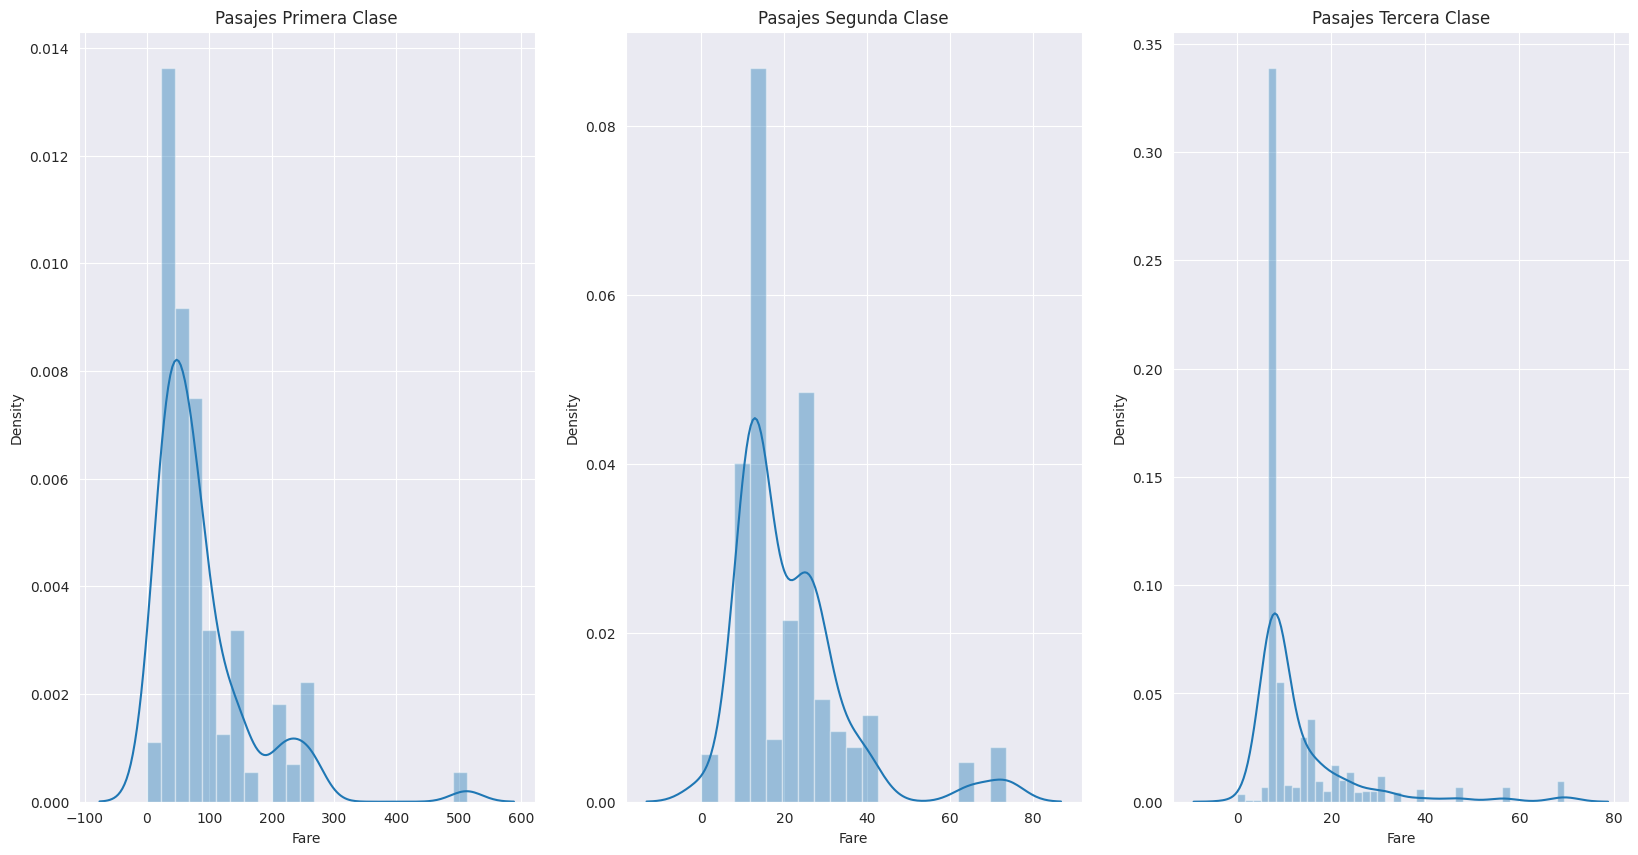

In [73]:
#La Estimación de Densidad de Kernel (KDE) es una forma de crear una curva suave que muestra cómo se distribuyen los datos en un conjunto.
#En lugar de mostrar solo los valores individuales o un gráfico de barras, KDE proporciona una línea continua que te ayuda a ver la "forma" general de los datos.

# Crea una figura con 3 subplots en una fila y especifica el tamaño de la figura
fig, axs = plt.subplots(1, 3, figsize=(20, 10))

# Gráfica de distribución del precio de los pasajes para la Primera Clase
# sns.distplot se utiliza para mostrar la distribución de una variable continua. Combina un histograma y una estimación de densidad kernel (KDE).
sns.distplot(df_all[df_all['Pclass'] == 1]['Fare'], ax=axs[0])
# Establece el título del subplot para identificar qué clase de pasaje se está mostrando
axs[0].set_title('Pasajes Primera Clase')

# Gráfica de distribución del precio de los pasajes para la Segunda Clase
# Repite el proceso para la segunda clase, mostrando cómo varían los precios de los pasajes.
sns.distplot(df_all[df_all['Pclass'] == 2]['Fare'], ax=axs[1])
# Establece el título del subplot para identificar qué clase de pasaje se está mostrando
axs[1].set_title('Pasajes Segunda Clase')

# Gráfica de distribución del precio de los pasajes para la Tercera Clase
# Repite el proceso para la tercera clase, mostrando cómo varían los precios de los pasajes.
sns.distplot(df_all[df_all['Pclass'] == 3]['Fare'], ax=axs[2])
# Establece el título del subplot para identificar qué clase de pasaje se está mostrando
axs[2].set_title('Pasajes Tercera Clase')

# Muestra la figura con los tres subplots
plt.show()


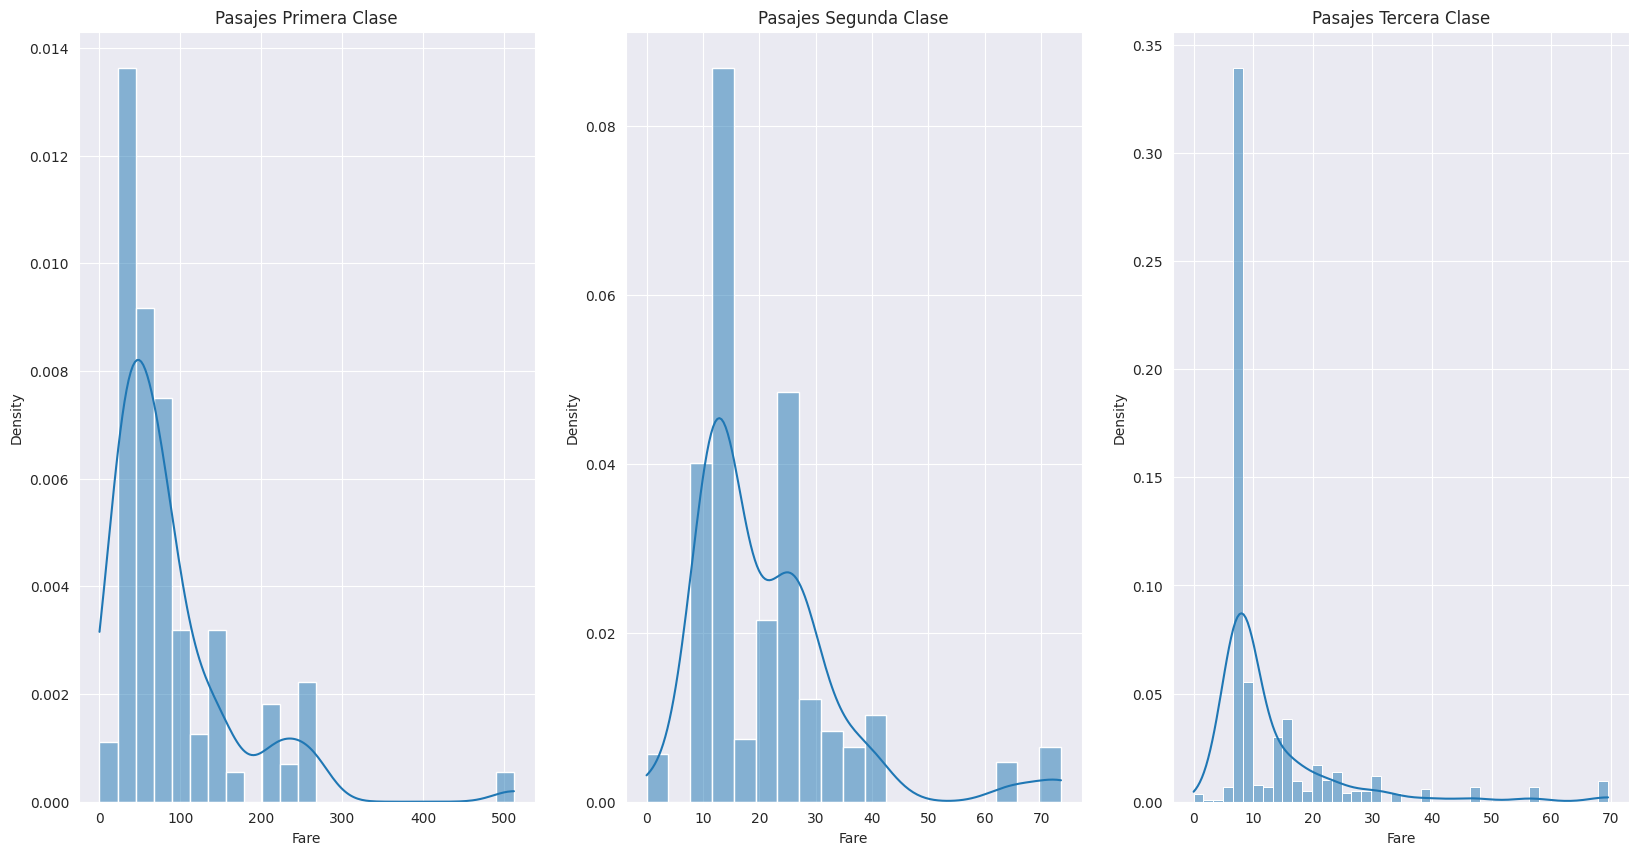

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crea una figura con 3 subplots en una fila y especifica el tamaño de la figura
fig, axs = plt.subplots(1, 3, figsize=(20, 10))

# Gráfica de distribución del precio de los pasajes para la Primera Clase
# sns.histplot se utiliza para mostrar la distribución de una variable continua con kde=True para incluir la estimación de densidad kernel (KDE).
sns.histplot(df_all[df_all['Pclass'] == 1]['Fare'], kde=True, stat="density", ax=axs[0])
# Establece el título del subplot para identificar qué clase de pasaje se está mostrando
axs[0].set_title('Pasajes Primera Clase')

# Gráfica de distribución del precio de los pasajes para la Segunda Clase
# Repite el proceso para la segunda clase, mostrando cómo varían los precios de los pasajes.
sns.histplot(df_all[df_all['Pclass'] == 2]['Fare'], kde=True, stat="density", ax=axs[1])
# Establece el título del subplot para identificar qué clase de pasaje se está mostrando
axs[1].set_title('Pasajes Segunda Clase')

# Gráfica de distribución del precio de los pasajes para la Tercera Clase
# Repite el proceso para la tercera clase, mostrando cómo varían los precios de los pasajes.
sns.histplot(df_all[df_all['Pclass'] == 3]['Fare'], kde=True, stat="density", ax=axs[2])
# Establece el título del subplot para identificar qué clase de pasaje se está mostrando
axs[2].set_title('Pasajes Tercera Clase')

# Muestra la figura con los tres subplots
plt.show()


In [74]:
med_fare = df_all.groupby(['Pclass', 'Parch', 'SibSp']).Fare.median()
print(med_fare)
med_fare = med_fare[3][0][0]
print(med_fare)
# Llenamos el valor perdido con la mediana de la tarifa de un pasajero solo de tercera clase
df_all['Fare'] = df_all['Fare'].fillna(med_fare)
df_all['fare_cat'] = 2

df_train['Fare'] = df_train['Fare'].fillna(med_fare)
df_train['fare_cat'] = 2

df_test['Fare'] = df_test['Fare'].fillna(med_fare)
df_test['fare_cat'] = 2

Pclass  Parch  SibSp
1       0      0         31.33960
               1         75.25000
               2         51.47920
        1      0         63.35830
               1         83.15830
        2      0         83.15830
               1        120.00000
               2        262.37500
               3        263.00000
        3      1        262.37500
        4      1        263.00000
2       0      0         13.00000
               1         26.00000
               2         73.50000
               3         21.00000
        1      0         23.00000
               1         26.25000
               2         33.00000
        2      0         26.25000
               1         41.57920
        3      0         39.00000
               1         23.00000
               2         18.75000
3       0      0          7.85420
               1         14.45625
               2         19.83960
               3         16.92500
        1      0         12.47500
               1         15

In [75]:
#df_all.drop(['Age', 'Fare', 'Name', 'PassengerId', 'Ticket'], axis = 1, inplace = True)

In [76]:
df_all

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket,age_cat,fare_range,fare_cat
0,22.000000,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,1,3,male,1,0.0,A/5 21171,1,"(-0.001, 7.25]",2
1,38.000000,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1.0,PC 17599,2,"(56.496, 83.475]",2
2,26.000000,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,3,female,0,1.0,STON/O2. 3101282,1,"(7.896, 8.05]",2
3,35.000000,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1.0,113803,2,"(34.157, 56.496]",2
4,35.000000,NaN,S,8.0500,"Allen, Mr. William Henry",0,5,3,male,0,0.0,373450,2,"(7.896, 8.05]",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,25.962264,NaN,S,8.0500,"Spector, Mr. Woolf",0,1305,3,male,0,NaN,A.5. 3236,0,"(7.896, 8.05]",2
1305,39.000000,C105,C,108.9000,"Oliva y Ocana, Dona. Fermina",0,1306,1,female,0,NaN,PC 17758,2,"(83.475, 512.329]",2
1306,38.500000,NaN,S,7.2500,"Saether, Mr. Simon Sivertsen",0,1307,3,male,0,NaN,SOTON/O.Q. 3101262,2,"(-0.001, 7.25]",2
1307,25.962264,NaN,S,8.0500,"Ware, Mr. Frederick",0,1308,3,male,0,NaN,359309,0,"(7.896, 8.05]",2


Sexo y Embarque se deben pasar a numerico

In [77]:
df_all['Sex'].replace(['male', 'female'], [0, 1], inplace=True)
df_all['Embarked'].replace(['S', 'C', 'Q'], [0, 1, 2], inplace=True)

In [78]:
df_all.head()

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket,age_cat,fare_range,fare_cat
0,22.0,NaN,0,7.2500,"Braund, Mr. Owen Harris",0,1,3,0,1,0.0,A/5 21171,1,"(-0.001, 7.25]",2
1,38.0,C85,1,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,1,1,1.0,PC 17599,2,"(56.496, 83.475]",2
2,26.0,NaN,0,7.9250,"Heikkinen, Miss. Laina",0,3,3,1,0,1.0,STON/O2. 3101282,1,"(7.896, 8.05]",2
3,35.0,C123,0,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,1,1,1.0,113803,2,"(34.157, 56.496]",2
4,35.0,NaN,0,8.0500,"Allen, Mr. William Henry",0,5,3,0,0,0.0,373450,2,"(7.896, 8.05]",2


**Cabina**
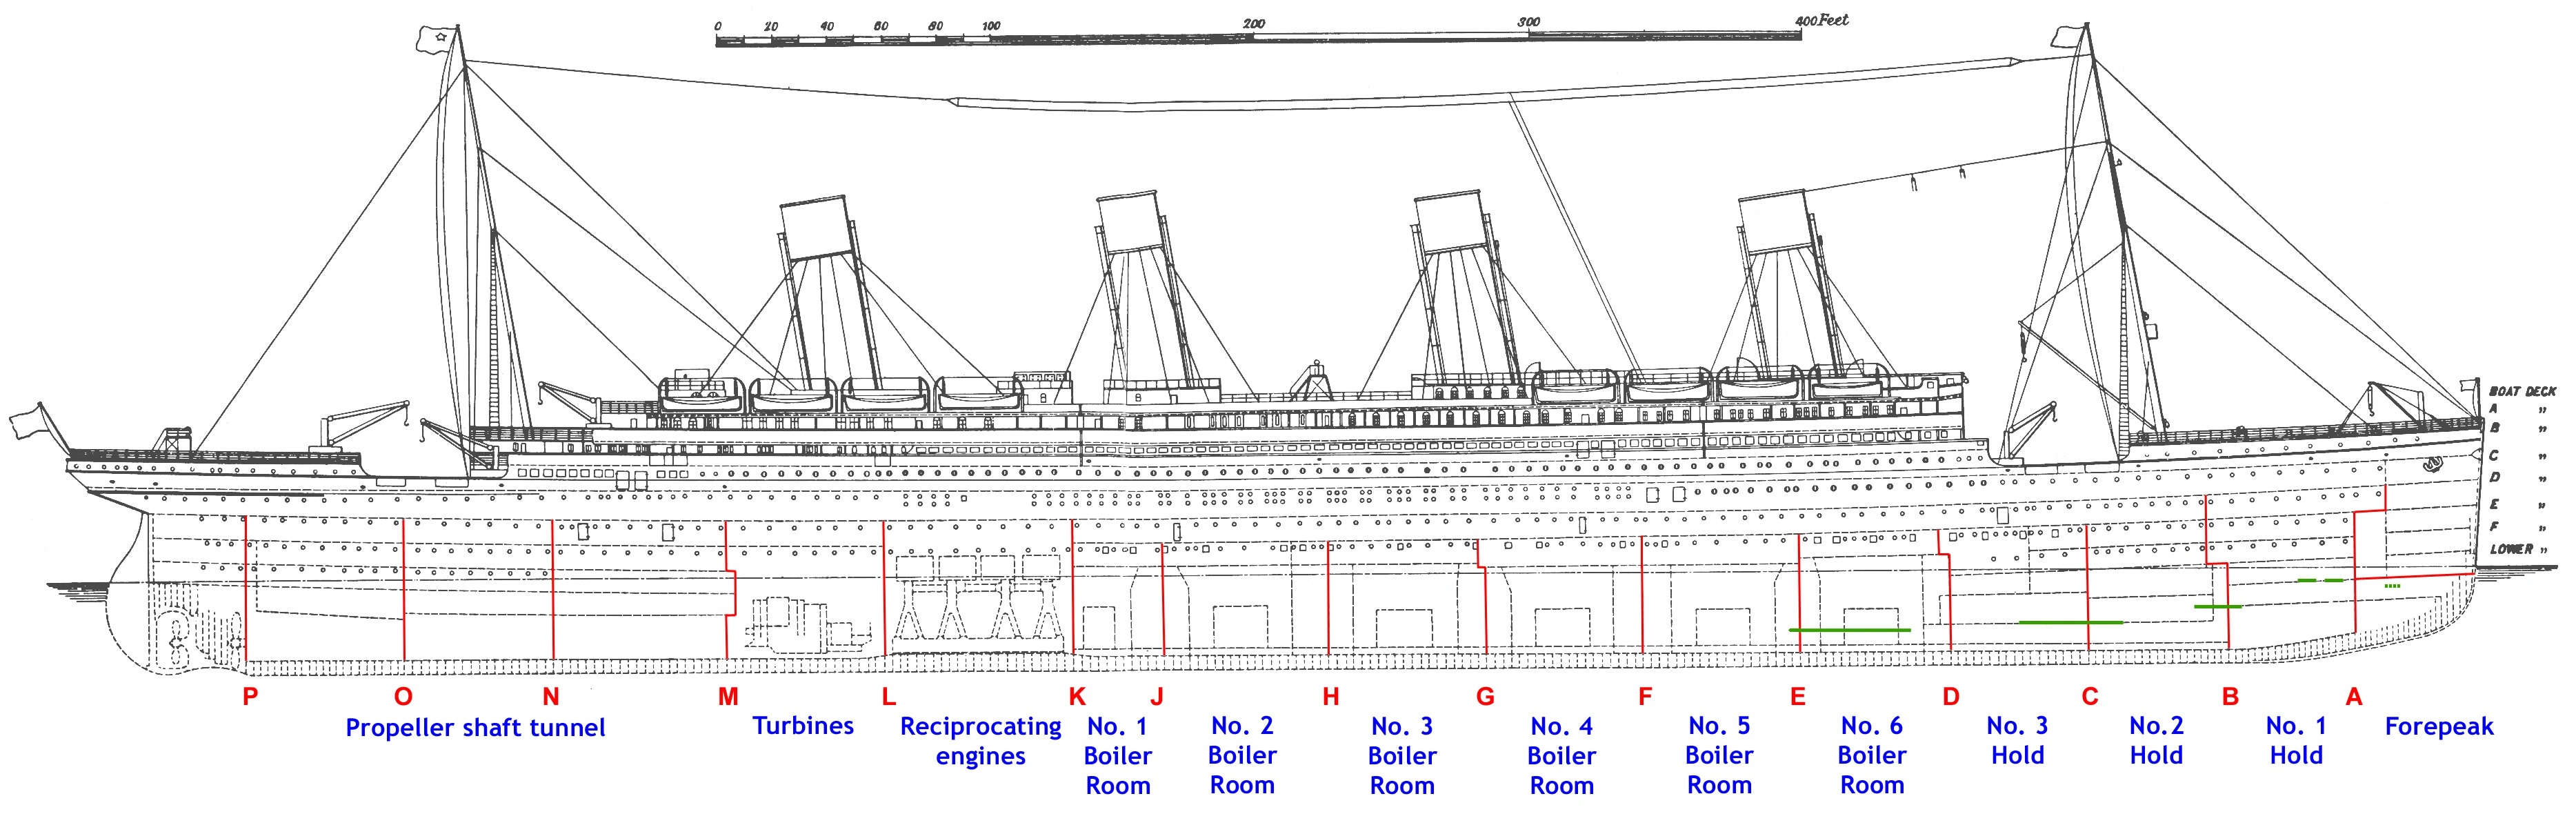

En la cubierta de botes había 6 habitaciones etiquetadas como T, U, W, X, Y, Z pero solo la cabina T está presente en el conjunto de datos.

Las cubiertas A, B y C eran solo para pasajeros de 1ra clase

Las cubiertas D y E eran para todas las clases.

Las cubiertas F y G eran para pasajeros de segunda y tercera clase.

Para ir de G a A, la distancia a la escalera aumenta, lo que podría ser un factor de supervivencia.

            0          1           2
A  100.000000   0.000000    0.000000
B  100.000000   0.000000    0.000000
C  100.000000   0.000000    0.000000
D   86.956522  13.043478    0.000000
E   82.926829   9.756098    7.317073
F    0.000000  61.904762   38.095238
G    0.000000   0.000000  100.000000
M    6.607495  25.049310   68.343195
T  100.000000   0.000000    0.000000


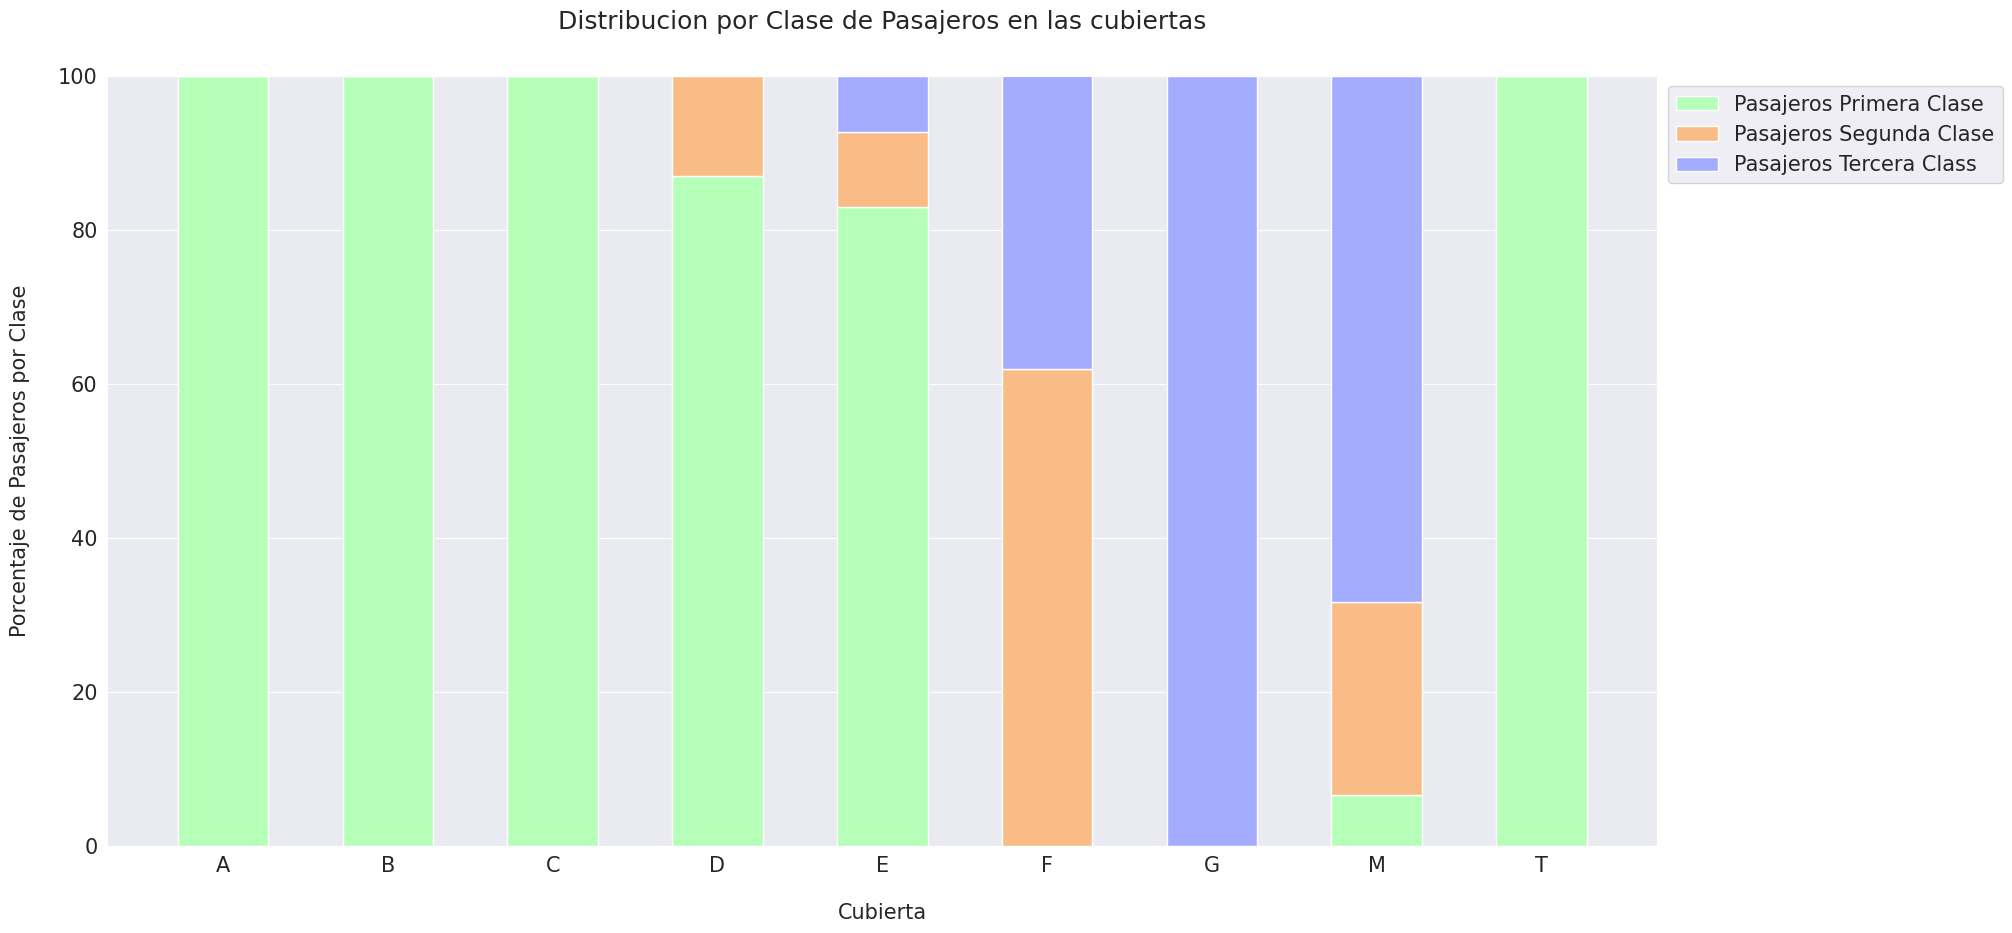

In [79]:
# Creamos el campo 'Cubierta/Deck'con la primera letra del campo 'Cabin' (M significa Missing)
df_all['Deck'] = df_all['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')
df_all_decks = df_all.groupby(['Deck', 'Pclass']).count().drop(columns=['Survived', 'Sex', 'Age', 'SibSp', 'Parch',
                                                                        'Fare', 'Embarked', 'Cabin', 'PassengerId', 'Ticket']).rename(columns={'Name': 'Count'}).transpose()

def get_pclass_dist(df):

    # Creamos un diccionario para el total de pasajeros por clase en cada cubierta
    deck_counts = {'A': {}, 'B': {}, 'C': {}, 'D': {}, 'E': {}, 'F': {}, 'G': {}, 'M': {}, 'T': {}}
    decks = df.columns.levels[0]

    for deck in decks:
        for pclass in range(1, 4):
            try:
                count = df[deck][pclass][0]
                deck_counts[deck][pclass] = count
            except KeyError:
                deck_counts[deck][pclass] = 0

    df_decks = pd.DataFrame(deck_counts)
    deck_percentages = {}

    # Creamos un diccionario para el porcentaje de pasajeros por clase en cada cubierta
    for col in df_decks.columns:
        deck_percentages[col] = [(count / df_decks[col].sum()) * 100 for count in df_decks[col]]

    return deck_counts, deck_percentages

def display_pclass_dist(percentages):
    #print(percentages)
    df_percentages = pd.DataFrame(percentages).transpose()
    print(df_percentages)
    deck_names = ('A', 'B', 'C', 'D', 'E', 'F', 'G', 'M', 'T')
    bar_count = np.arange(len(deck_names))
    bar_width = 0.55

    pclass1 = df_percentages[0]
    pclass2 = df_percentages[1]
    pclass3 = df_percentages[2]

    plt.figure(figsize=(20, 10))
    plt.bar(bar_count, pclass1, color='#b5ffb9', edgecolor='white', width=bar_width, label='Pasajeros Primera Clase')
    plt.bar(bar_count, pclass2, bottom=pclass1, color='#f9bc86', edgecolor='white', width=bar_width, label='Pasajeros Segunda Clase')
    plt.bar(bar_count, pclass3, bottom=pclass1 + pclass2, color='#a3acff', edgecolor='white', width=bar_width, label='Pasajeros Tercera Class')

    plt.xlabel('Cubierta', size=15, labelpad=20)
    plt.ylabel('Porcentaje de Pasajeros por Clase', size=15, labelpad=20)
    plt.xticks(bar_count, deck_names)
    plt.tick_params(axis='x', labelsize=15)
    plt.tick_params(axis='y', labelsize=15)

    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 15})
    plt.title('Distribucion por Clase de Pasajeros en las cubiertas', size=18, y=1.05)

    plt.show()

all_deck_count, all_deck_per = get_pclass_dist(df_all_decks)

display_pclass_dist(all_deck_per)

In [80]:
# Pasajero en la cubierta T se cambia a A
idx = df_all[df_all['Deck'] == 'T'].index
df_all.loc[idx, 'Deck'] = 'A'

           0          1
A  56.250000  43.750000
B  25.531915  74.468085
C  40.677966  59.322034
D  24.242424  75.757576
E  25.000000  75.000000
F  38.461538  61.538462
G  50.000000  50.000000
M  70.014556  29.985444


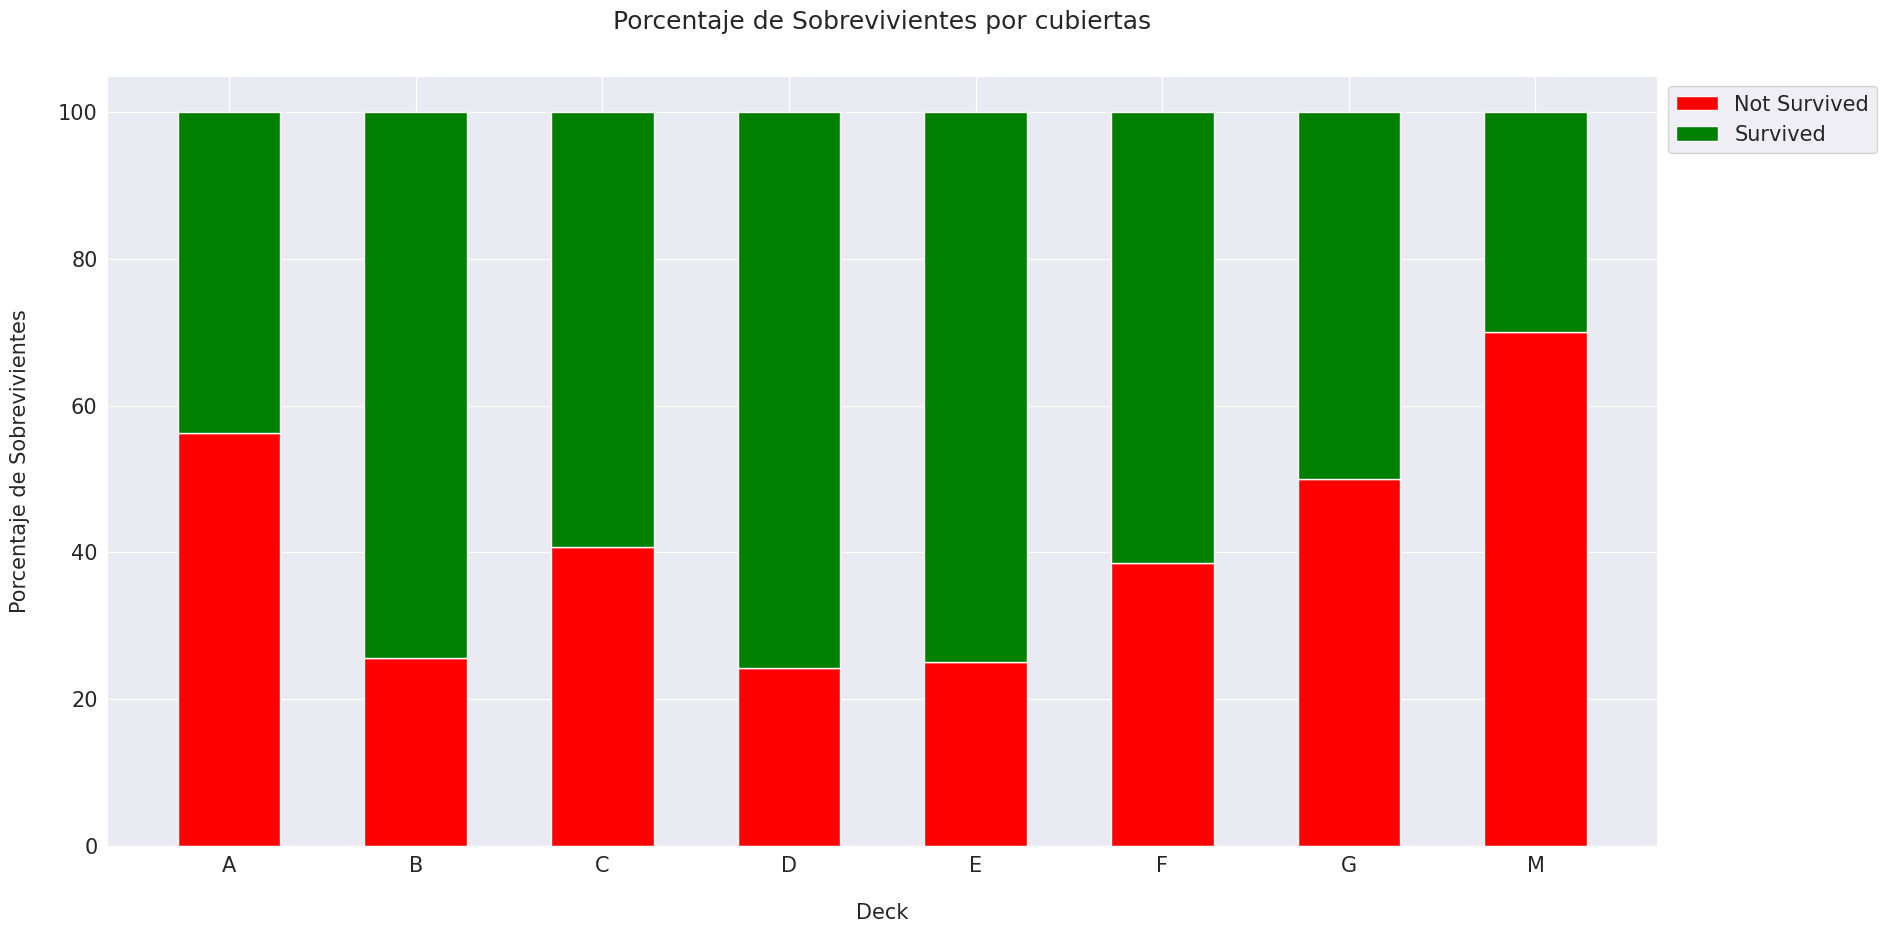

In [81]:
df_all_decks_survived = df_all.groupby(['Deck', 'Survived']).count().drop(columns=['Sex', 'Age', 'SibSp', 'Parch', 'Fare',
                                                                                   'Embarked', 'Pclass', 'Cabin', 'PassengerId', 'Ticket']).rename(columns={'Name':'Count'}).transpose()

def get_survived_dist(df):

    # Creamos un diccionario para cada sobreviviente contado en cada cubierta
    surv_counts = {'A':{}, 'B':{}, 'C':{}, 'D':{}, 'E':{}, 'F':{}, 'G':{}, 'M':{}}
    decks = df.columns.levels[0]

    for deck in decks:
        for survive in range(0, 2):
            surv_counts[deck][survive] = df[deck][survive][0]

    df_surv = pd.DataFrame(surv_counts)
    surv_percentages = {}

    for col in df_surv.columns:
        surv_percentages[col] = [(count / df_surv[col].sum()) * 100 for count in df_surv[col]]

    return surv_counts, surv_percentages

def display_surv_dist(percentages):

    df_survived_percentages = pd.DataFrame(percentages).transpose()
    print(df_survived_percentages)
    deck_names = ('A', 'B', 'C', 'D', 'E', 'F', 'G', 'M')
    bar_count = np.arange(len(deck_names))
    bar_width = 0.55

    not_survived = df_survived_percentages[0]
    survived = df_survived_percentages[1]

    plt.figure(figsize=(20, 10))
    plt.bar(bar_count, not_survived, color='red', edgecolor='white', width=bar_width, label="Not Survived")
    plt.bar(bar_count, survived, bottom=not_survived, color='green', edgecolor='white', width=bar_width, label="Survived")

    plt.xlabel('Deck', size=15, labelpad=20)
    plt.ylabel('Porcentaje de Sobrevivientes', size=15, labelpad=20)
    plt.xticks(bar_count, deck_names)
    plt.tick_params(axis='x', labelsize=15)
    plt.tick_params(axis='y', labelsize=15)

    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 15})
    plt.title('Porcentaje de Sobrevivientes por cubiertas', size=18, y=1.05)

    plt.show()

all_surv_count, all_surv_per = get_survived_dist(df_all_decks_survived)
display_surv_dist(all_surv_per)

In [82]:
df_all['Deck'] = df_all['Deck'].replace(['A', 'B', 'C'], 'ABC')
df_all['Deck'] = df_all['Deck'].replace(['D', 'E'], 'DE')
df_all['Deck'] = df_all['Deck'].replace(['F', 'G'], 'FG')

df_all['Deck'].value_counts()


,count
Deck,
M,1014
ABC,182
DE,87
FG,26


In [83]:
# Desechamos la variable cabina pues usamos la nueva variable Deck

df_all.drop(['Cabin'], inplace=True, axis=1)

df_train, df_test = divide_df(df_all)
dfs = [df_train, df_test]

for df in dfs:
    display_missing(df)

Columna Age valores perdidos: 0
Columna Embarked valores perdidos: 0
Columna Fare valores perdidos: 0
Columna Name valores perdidos: 0
Columna Parch valores perdidos: 0
Columna PassengerId valores perdidos: 0
Columna Pclass valores perdidos: 0
Columna Sex valores perdidos: 0
Columna SibSp valores perdidos: 0
Columna Survived valores perdidos: 0
Columna Ticket valores perdidos: 0
Columna age_cat valores perdidos: 0
Columna fare_range valores perdidos: 0
Columna fare_cat valores perdidos: 0
Columna Deck valores perdidos: 0


Columna Age valores perdidos: 0
Columna Embarked valores perdidos: 0
Columna Fare valores perdidos: 0
Columna Name valores perdidos: 0
Columna Parch valores perdidos: 0
Columna PassengerId valores perdidos: 0
Columna Pclass valores perdidos: 0
Columna Sex valores perdidos: 0
Columna SibSp valores perdidos: 0
Columna Ticket valores perdidos: 0
Columna age_cat valores perdidos: 0
Columna fare_range valores perdidos: 1
Columna fare_cat valores perdidos: 0
Columna Deck v

Distribucion de los Sobrevivientes (Target):

342 de 891 pasajeros sobrevivieron y eso es el 38.38% del conjunto de entrenamiento.
549 de 891 pasajeros no sobrevivieron y eso es el 61.62%  del conjunto de entrenamiento.


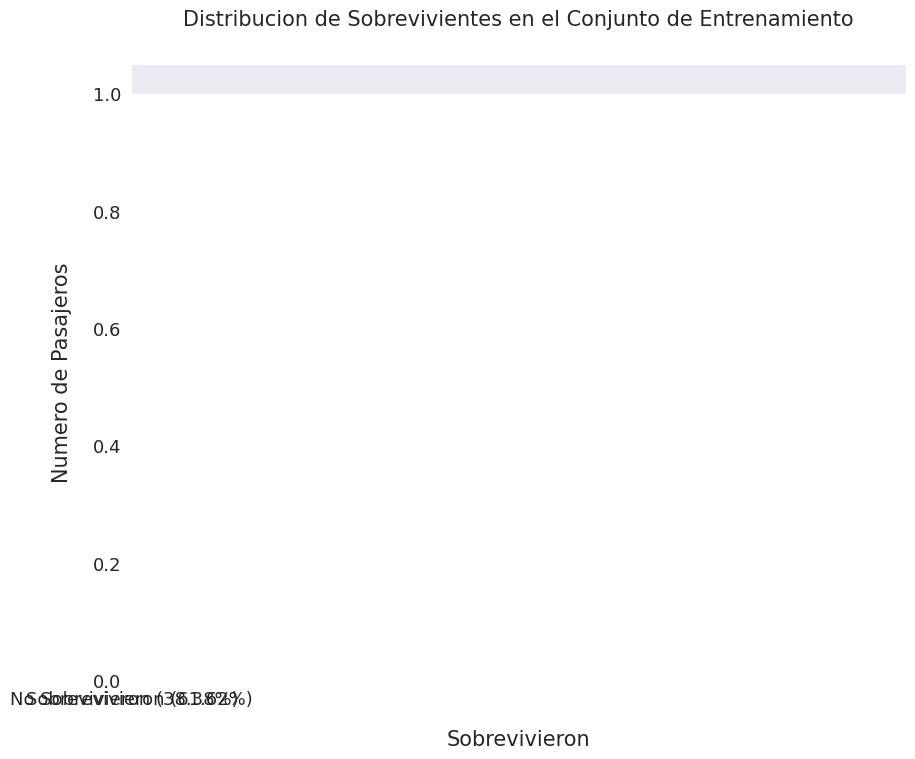

In [84]:
survived = df_train['Survived'].value_counts()[1]
not_survived = df_train['Survived'].value_counts()[0]
survived_per = survived / df_train.shape[0] * 100
not_survived_per = not_survived / df_train.shape[0] * 100

print('{} de {} pasajeros sobrevivieron y eso es el {:.2f}% del conjunto de entrenamiento.'.format(survived, df_train.shape[0], survived_per))
print('{} de {} pasajeros no sobrevivieron y eso es el {:.2f}%  del conjunto de entrenamiento.'.format(not_survived, df_train.shape[0], not_survived_per))

plt.figure(figsize=(10, 8))
sns.countplot(df_train['Survived'])

plt.xlabel('Sobrevivieron', size=15, labelpad=15)
plt.ylabel('Numero de Pasajeros', size=15, labelpad=15)
plt.xticks((0, 1), ['No Sobrevivieron ({0:.2f}%)'.format(not_survived_per), 'Sobrevivieron ({0:.2f}%)'.format(survived_per)])
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)

plt.title('Distribucion de Sobrevivientes en el Conjunto de Entrenamiento', size=15, y=1.05)

plt.show()

**Correlaciones:**

Las características están altamente correlacionadas entre sí y dependen unas de otras. La correlación más alta entre características es 0.549500 en el conjunto de entrenamiento y 0.577147 en el conjunto de prueba (entre Tarifa y Pclass). Las otras características también están altamente correlacionadas. Hay 9 correlaciones en el conjunto de entrenamiento y 6 correlaciones en el conjunto de prueba que son superiores a 0,1.

In [85]:
df_train.shape

(891, 15)

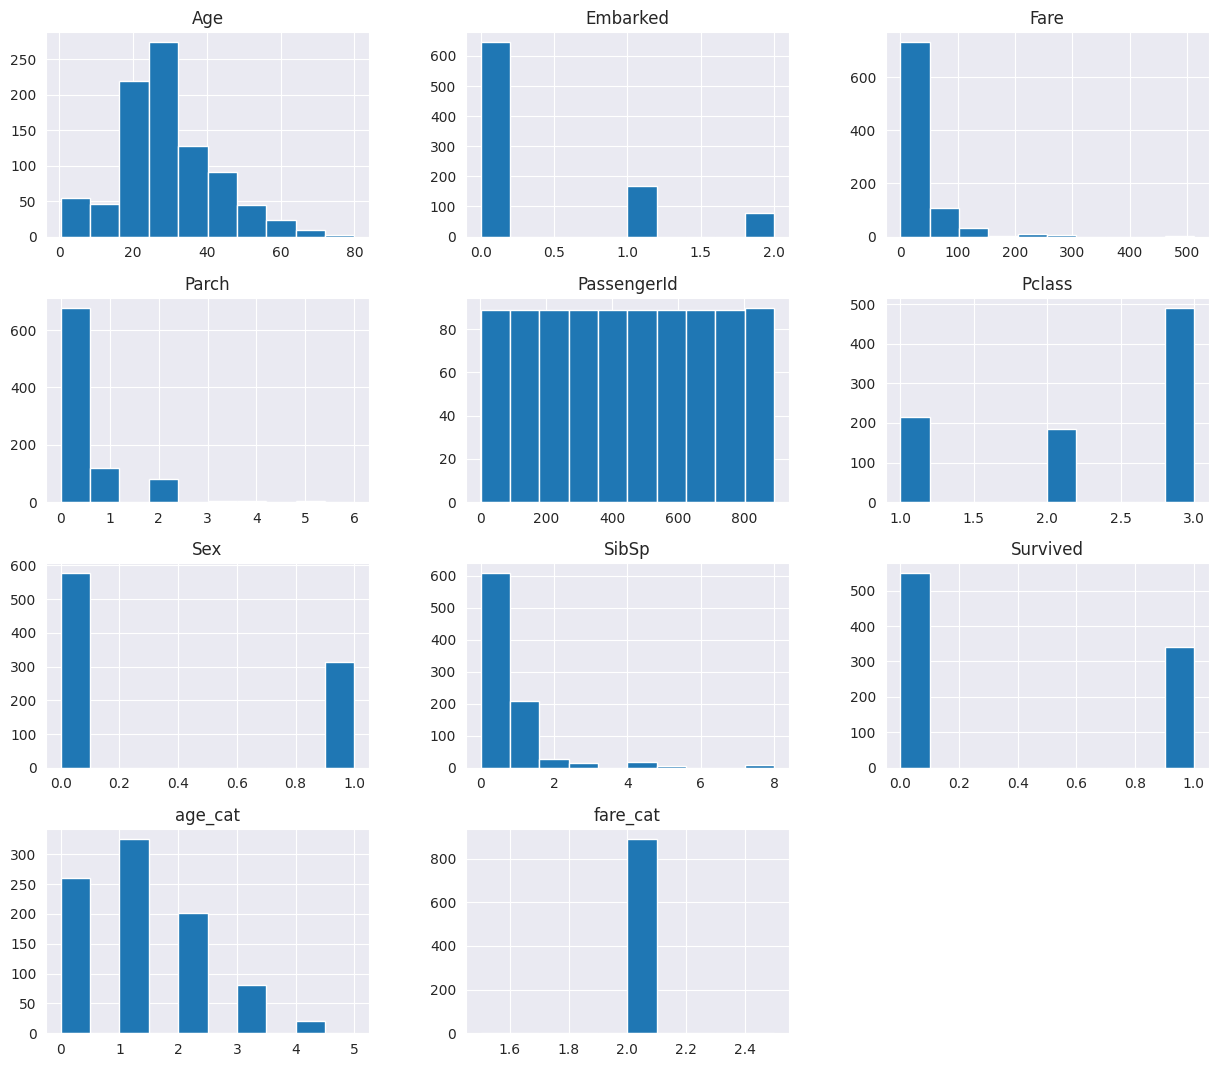

In [86]:
df_train.hist(figsize=(15,13))
plt.show()

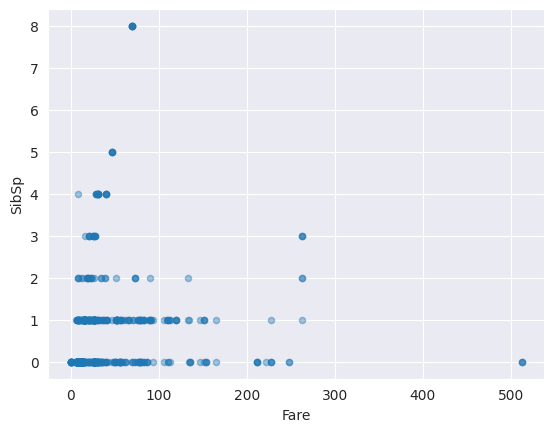

In [87]:
df_train.plot(x="Fare", y="SibSp", kind="scatter", alpha=0.4)
plt.show()

In [88]:
def process_correlation_matrix(df, drop_column=None):
    # Eliminar la columna específica si se proporciona
    if drop_column:
        df = df.drop([drop_column], axis=1)

    # Seleccionar solo las columnas numéricas
    df_numeric = df.select_dtypes(include=[float, int])

    # Calcular la matriz de correlación
    df_corr = df_numeric.corr(method='pearson').abs().unstack().sort_values(kind="quicksort", ascending=False).reset_index()

    # Renombrar las columnas resultantes
    df_corr.rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: 'Coeficiente Correlacion'}, inplace=True)

    # Eliminar duplicados donde Feature 1 es igual a Feature 2
    df_corr = df_corr[df_corr['Feature 1'] != df_corr['Feature 2']]

    # Eliminar duplicados inversos
    df_corr = df_corr.drop_duplicates(subset=['Coeficiente Correlacion'])

    return df_corr

In [89]:
df_train_corr = process_correlation_matrix(df_train, drop_column='PassengerId')
df_train_corr_nd = df_train_corr[df_train_corr['Coeficiente Correlacion'] != 1.0]

# Procesar la matriz de correlación para df_test
df_test_corr = process_correlation_matrix(df_test)
df_test_corr_nd = df_test_corr[df_test_corr['Coeficiente Correlacion'] != 1.0]

# Mostrar los resultados
print("Matriz de Correlación de Entrenamiento (sin duplicados y correlaciones perfectas):")
print(df_train_corr_nd)

print("\nMatriz de Correlación de Prueba (sin duplicados y correlaciones perfectas):")
print(df_test_corr_nd)

Matriz de Correlación de Entrenamiento (sin duplicados y correlaciones perfectas):
   Feature 1 Feature 2  Coeficiente Correlacion
9    age_cat       Age                 0.800405
11      Fare    Pclass                 0.549500
13  Survived       Sex                 0.543351
15     SibSp     Parch                 0.414838
17       Age    Pclass                 0.411177
19    Pclass   age_cat                 0.371435
21    Pclass  Survived                 0.338481
23      Fare  Survived                 0.257307
25       Age     SibSp                 0.249843
27     Parch       Sex                 0.245489
29     Parch      Fare                 0.216225
31     SibSp   age_cat                 0.188968
33       Sex      Fare                 0.182333
35  Embarked   age_cat                 0.181932
37       Age     Parch                 0.179520
39      Fare     SibSp                 0.159651
41   age_cat      Fare                 0.137060
43    Pclass       Sex                 0.131900
45   

In [90]:
'''df_train_corr = df_train.drop(['PassengerId'], axis=1).corr(method='pearson').abs().unstack().sort_values(kind="quicksort", ascending=False).reset_index()
df_train_corr.rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: 'Coeficiente Correlacion'}, inplace=True)
df_train_corr.drop(df_train_corr.iloc[1::2].index, inplace=True)
df_train_corr_nd = df_train_corr.drop(df_train_corr[df_train_corr['Coeficiente Correlacion'] == 1.0].index)

df_test_corr = df_test.corr(method='pearson').abs().unstack().sort_values(kind="quicksort", ascending=False).reset_index()
df_test_corr.rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: 'Coeficiente Correlacion'}, inplace=True)
df_test_corr.drop(df_test_corr.iloc[1::2].index, inplace=True)
df_test_corr_nd = df_test_corr.drop(df_test_corr[df_test_corr['Coeficiente Correlacion'] == 1.0].index)'''

'df_train_corr = df_train.drop([\'PassengerId\'], axis=1).corr(method=\'pearson\').abs().unstack().sort_values(kind="quicksort", ascending=False).reset_index()\ndf_train_corr.rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: \'Coeficiente Correlacion\'}, inplace=True)\ndf_train_corr.drop(df_train_corr.iloc[1::2].index, inplace=True)\ndf_train_corr_nd = df_train_corr.drop(df_train_corr[df_train_corr[\'Coeficiente Correlacion\'] == 1.0].index)\n\ndf_test_corr = df_test.corr(method=\'pearson\').abs().unstack().sort_values(kind="quicksort", ascending=False).reset_index()\ndf_test_corr.rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: \'Coeficiente Correlacion\'}, inplace=True)\ndf_test_corr.drop(df_test_corr.iloc[1::2].index, inplace=True)\ndf_test_corr_nd = df_test_corr.drop(df_test_corr[df_test_corr[\'Coeficiente Correlacion\'] == 1.0].index)'

In [91]:
# Conjunto de entrenamiento - correlaciones altas
corr = df_train_corr_nd['Coeficiente Correlacion'] > 0.1
df_train_corr_nd[corr]


,Feature 1,Feature 2,Coeficiente Correlacion
9,age_cat,Age,0.800405
11,Fare,Pclass,0.549500
13,Survived,Sex,0.543351
15,SibSp,Parch,0.414838
17,Age,Pclass,0.411177
19,Pclass,age_cat,0.371435
21,Pclass,Survived,0.338481
23,Fare,Survived,0.257307
25,Age,SibSp,0.249843
27,Parch,Sex,0.245489


In [92]:
# Conjunto de prueba - correlaciones altas
corr = df_test_corr_nd['Coeficiente Correlacion'] > 0.1
df_test_corr_nd[corr]

,Feature 1,Feature 2,Coeficiente Correlacion
9,age_cat,Age,0.824386
11,Pclass,Fare,0.577489
13,Age,Pclass,0.519454
15,age_cat,Pclass,0.499127
17,age_cat,Fare,0.353389
19,Age,Fare,0.342450
21,Parch,SibSp,0.306895
23,Parch,Fare,0.230410
25,Fare,Sex,0.192226
27,Fare,SibSp,0.172032


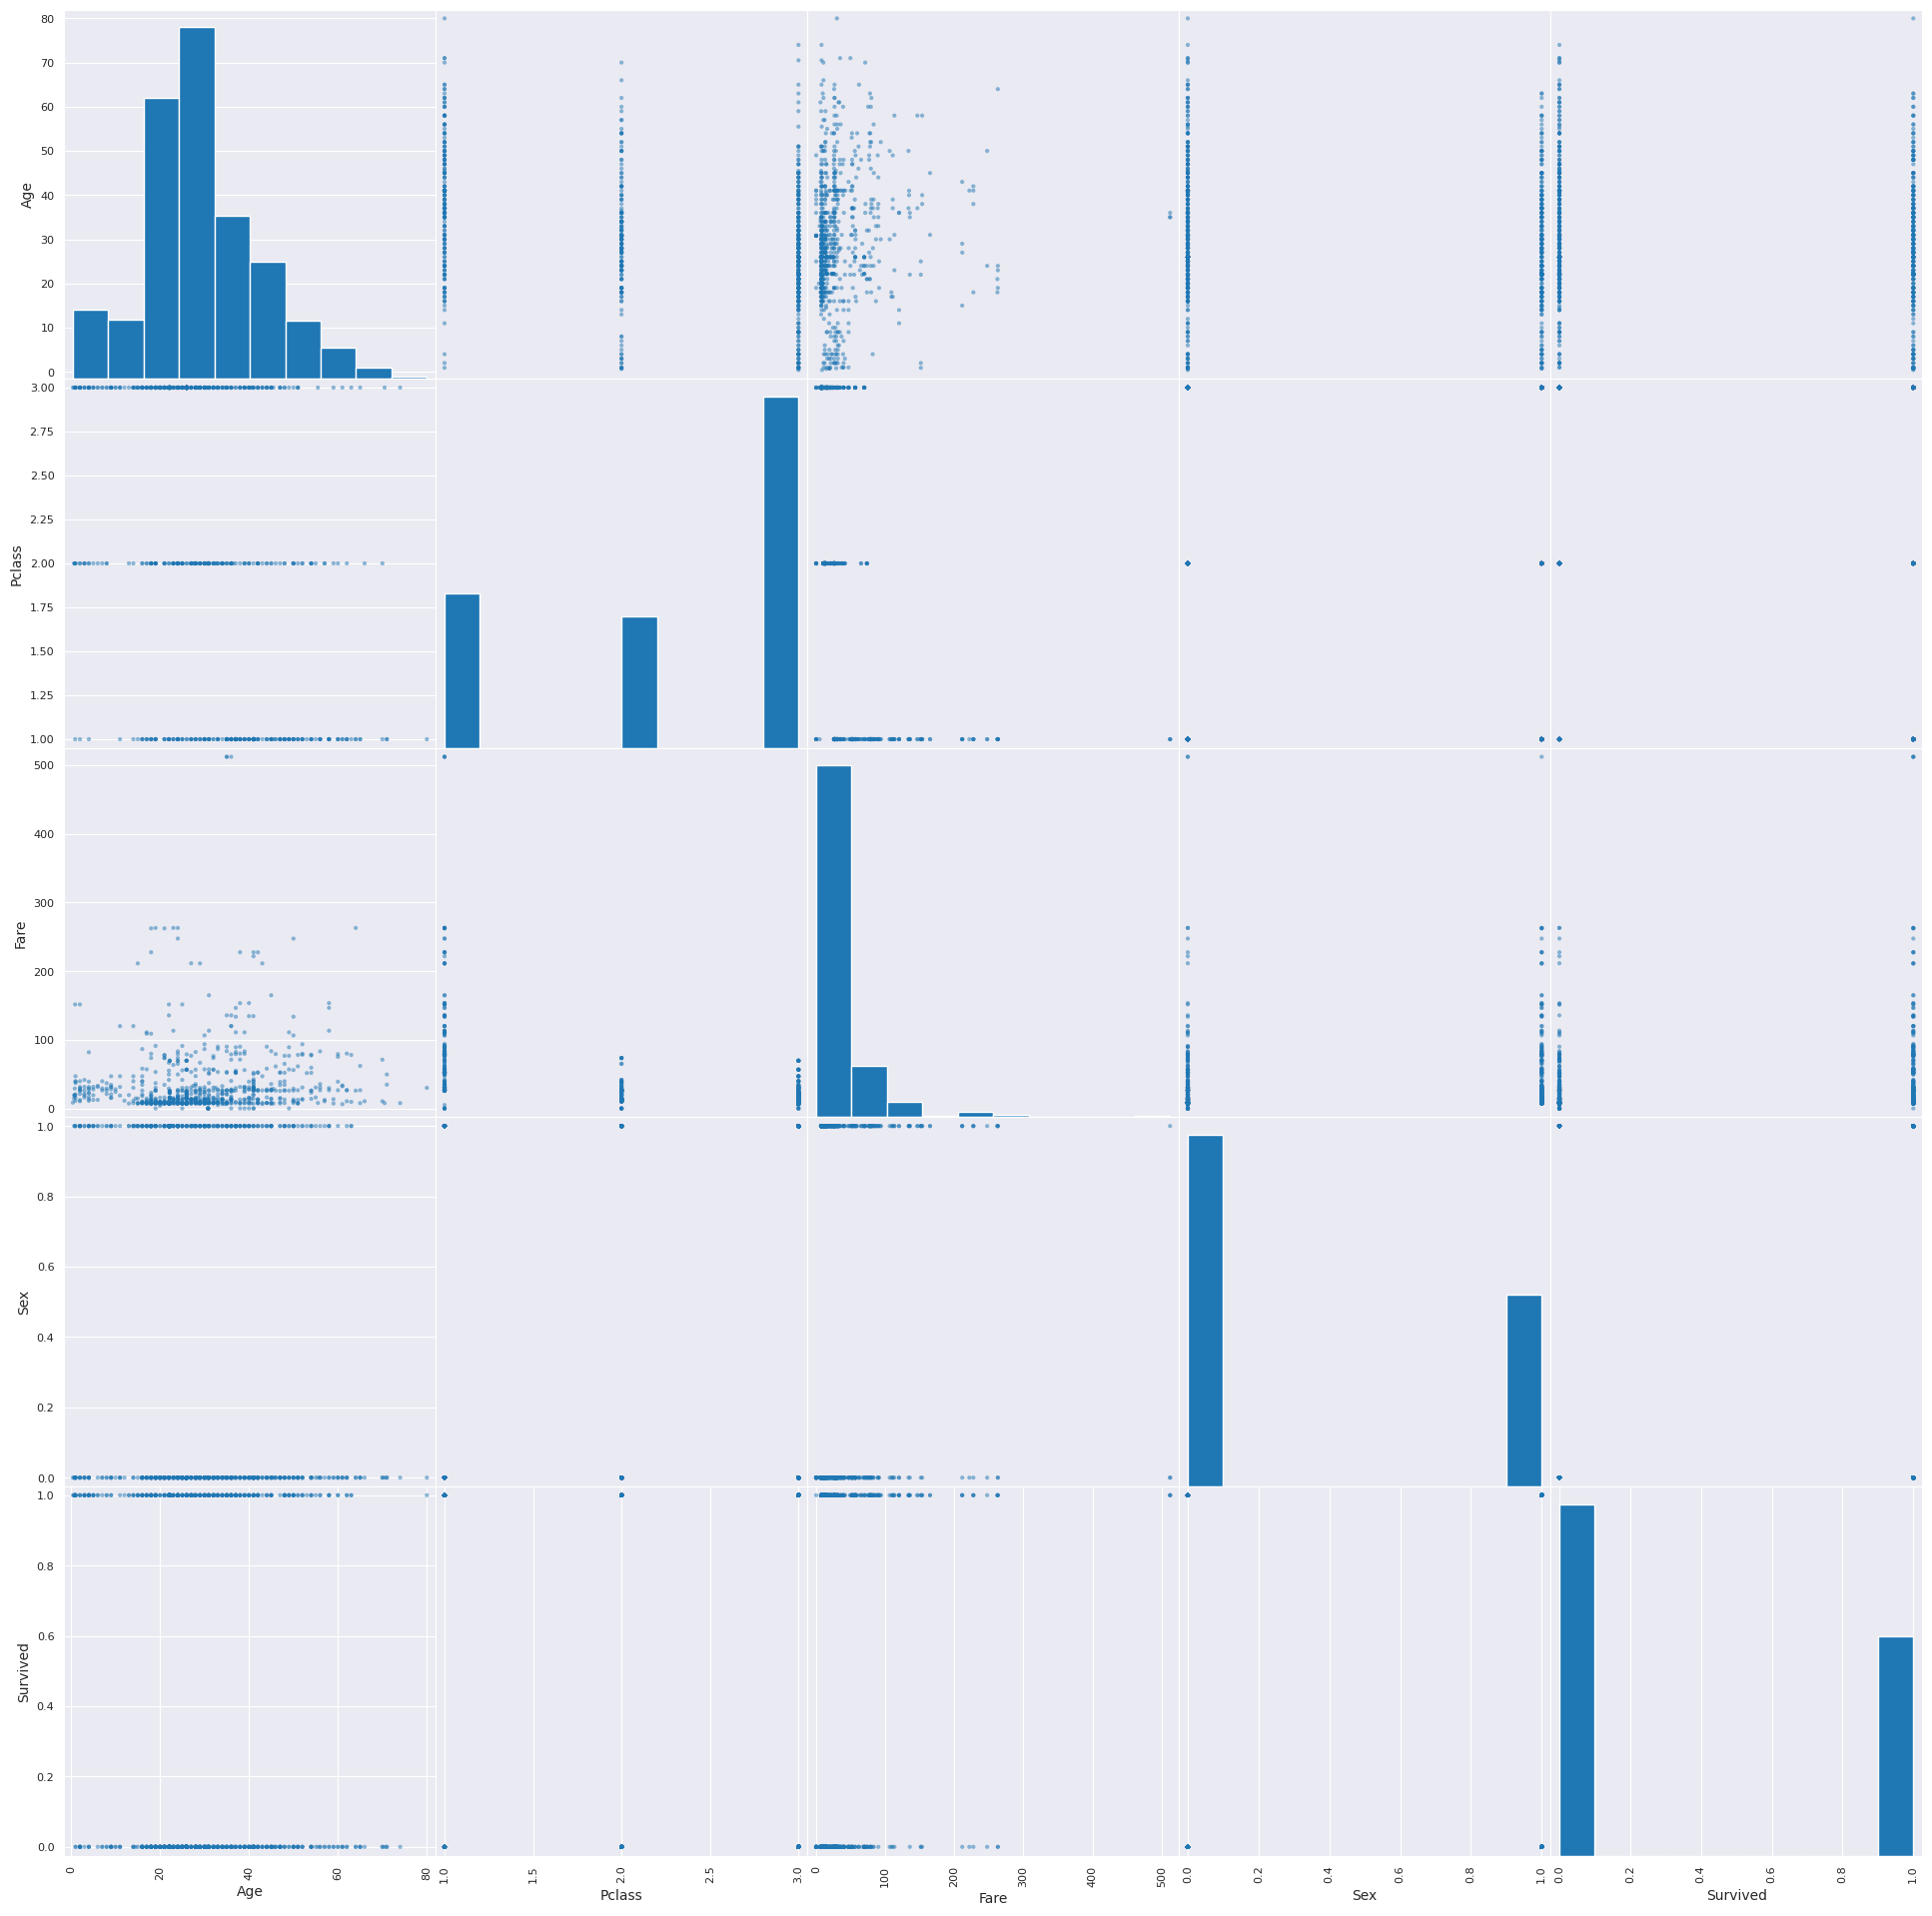

In [93]:
from pandas.plotting import scatter_matrix
attributes = ["Age","Pclass","Fare","Sex","Survived"]
scatter_matrix(df_train[attributes], figsize=(24,24))
plt.show()

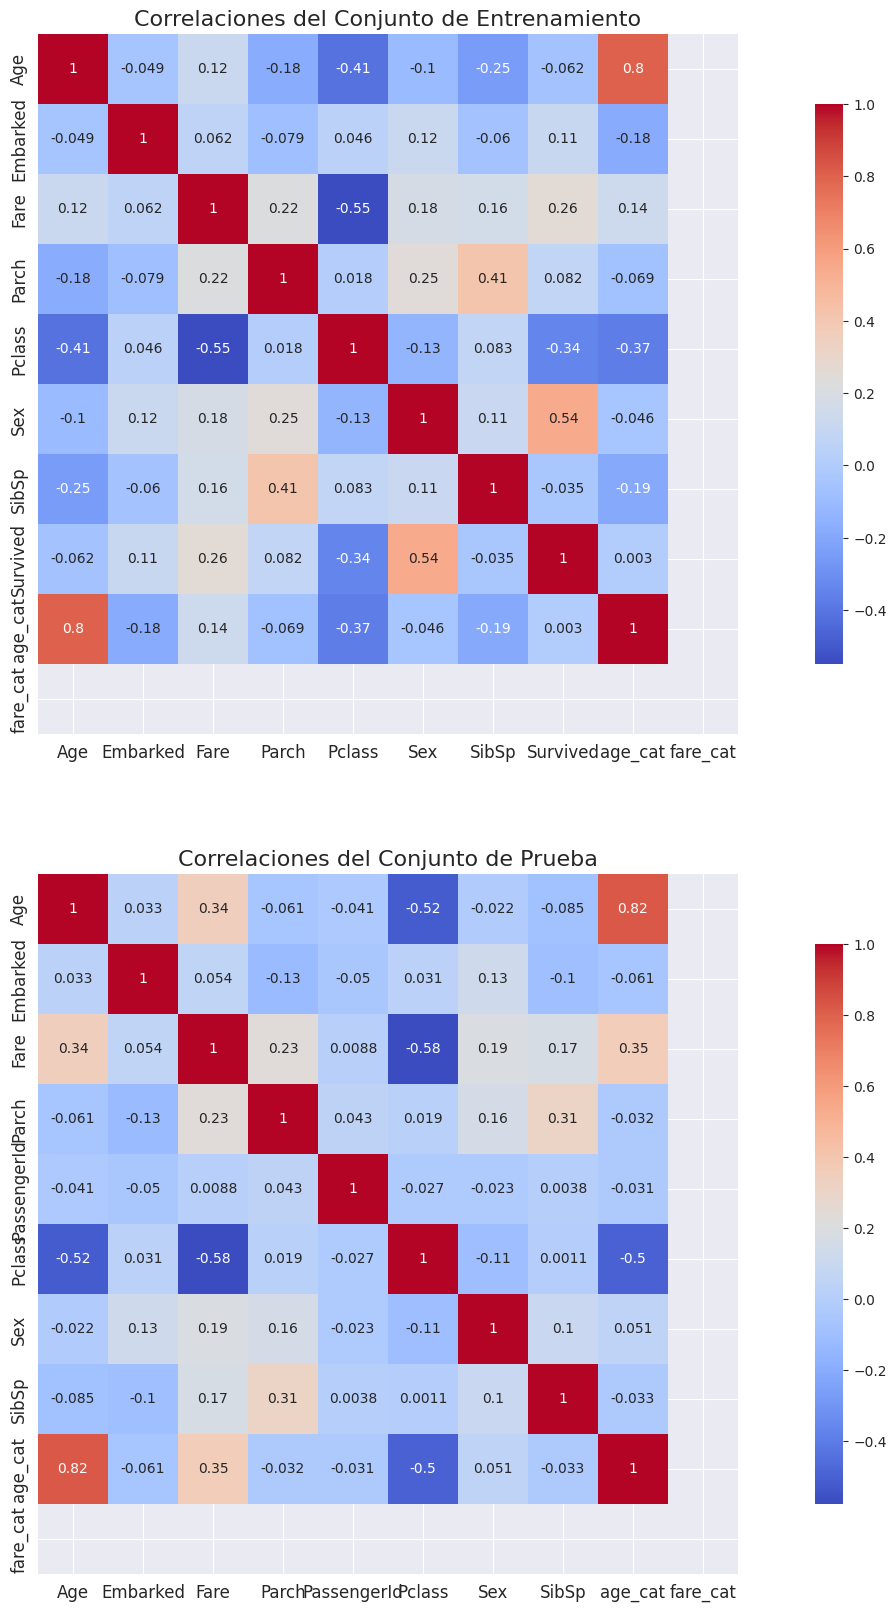

In [94]:
# Selecciona únicamente las columnas numéricas de df_train
df_train_numeric = df_train.drop(['PassengerId'], axis=1).select_dtypes(include=[float, int])

# Selecciona únicamente las columnas numéricas de df_test
df_test_numeric = df_test.select_dtypes(include=[float, int])

# Configuración del tamaño de la figura
fig, axs = plt.subplots(nrows=2, figsize=(20, 20))  # Tamaño ajustado para una mejor visualización

# Mapa de calor para el conjunto de entrenamiento
sns.heatmap(
    df_train_numeric.corr(),
    ax=axs[0],
    annot=True,
    square=True,
    cmap='coolwarm',
    annot_kws={'size': 10},  # Tamaño de la anotación ajustado
    cbar_kws={"shrink": .8}  # Tamaño de la barra de color ajustado
)

# Mapa de calor para el conjunto de prueba
sns.heatmap(
    df_test_numeric.corr(),
    ax=axs[1],
    annot=True,
    square=True,
    cmap='coolwarm',
    annot_kws={'size': 10},  # Tamaño de la anotación ajustado
    cbar_kws={"shrink": .8}  # Tamaño de la barra de color ajustado
)

# Ajustes de los ejes
for i in range(2):
    axs[i].tick_params(axis='x', labelsize=12)
    axs[i].tick_params(axis='y', labelsize=12)

# Títulos de los gráficos
axs[0].set_title('Correlaciones del Conjunto de Entrenamiento', size=16)
axs[1].set_title('Correlaciones del Conjunto de Prueba', size=16)

# Mostrar el gráfico
plt.show()

In [95]:
'''fig, axs = plt.subplots(nrows=2, figsize=(40, 40))

sns.heatmap(df_train.drop(['PassengerId'], axis=1).corr(), ax=axs[0], annot=True, square=True, cmap='coolwarm', annot_kws={'size': 14})
sns.heatmap(df_test.drop(['PassengerId'], axis=1).corr(), ax=axs[1], annot=True, square=True, cmap='coolwarm', annot_kws={'size': 14})

for i in range(2):
    axs[i].tick_params(axis='x', labelsize=14)
    axs[i].tick_params(axis='y', labelsize=14)

axs[0].set_title('Correlaciones del Conjunto de Entrenamiento', size=15)
axs[1].set_title('Correlaciones del Conjunto de Prueba', size=15)

plt.show()'''

"fig, axs = plt.subplots(nrows=2, figsize=(40, 40))\n\nsns.heatmap(df_train.drop(['PassengerId'], axis=1).corr(), ax=axs[0], annot=True, square=True, cmap='coolwarm', annot_kws={'size': 14})\nsns.heatmap(df_test.drop(['PassengerId'], axis=1).corr(), ax=axs[1], annot=True, square=True, cmap='coolwarm', annot_kws={'size': 14})\n\nfor i in range(2):\n    axs[i].tick_params(axis='x', labelsize=14)\n    axs[i].tick_params(axis='y', labelsize=14)\n\naxs[0].set_title('Correlaciones del Conjunto de Entrenamiento', size=15)\naxs[1].set_title('Correlaciones del Conjunto de Prueba', size=15)\n\nplt.show()"

**DISTRIBUCION VARIABLE OBJETIVO POR FEATURES:**



CONTINUOS

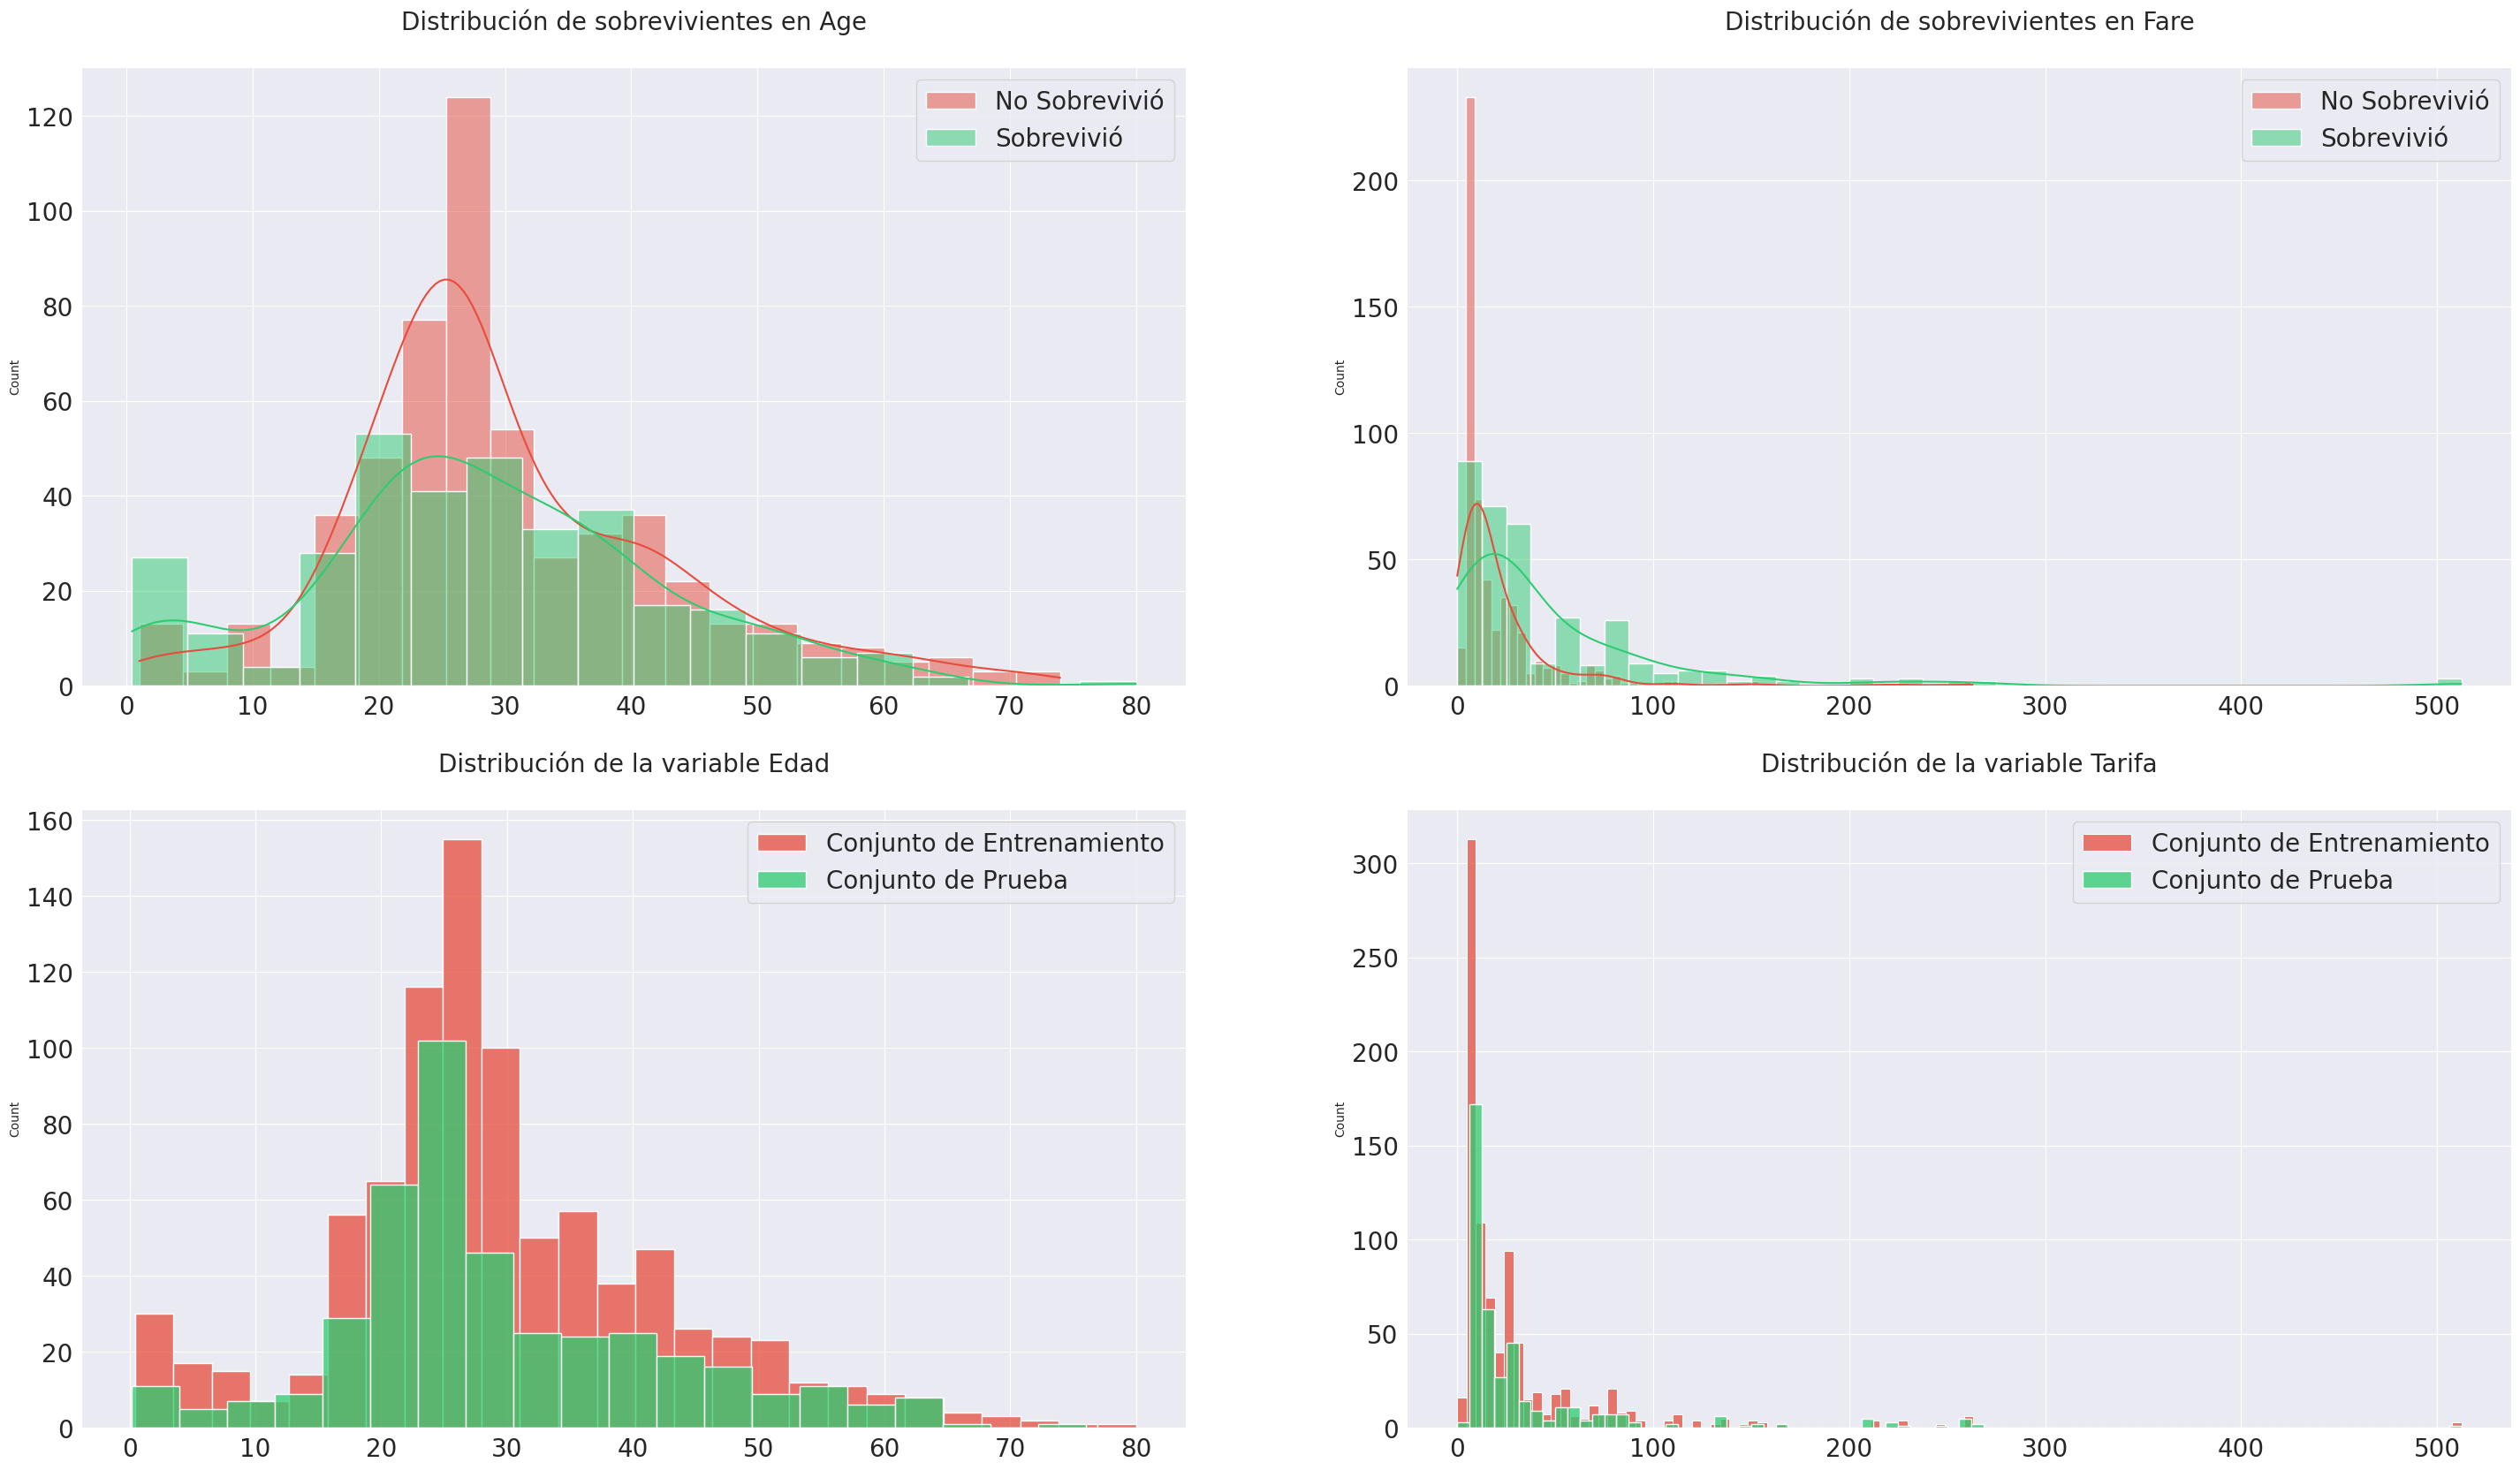

In [97]:
# Lista de características continuas a analizar
cont_features = ['Age', 'Fare']
# Filtro para sobrevivientes
surv = df_train['Survived'] == 1

# Crear una figura con subplots de 2 filas y 2 columnas, y ajustar el tamaño de la figura
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(20, 20))
plt.subplots_adjust(right=1.5)

# Iterar sobre las características continuas para graficar
for i, feature in enumerate(cont_features):
    # Distribución de la característica para los que no sobrevivieron (en rojo) y los que sobrevivieron (en verde)
    sns.histplot(df_train[~surv][feature], label='No Sobrevivió', kde=True, color='#e74c3c', ax=axs[0][i])
    sns.histplot(df_train[surv][feature], label='Sobrevivió', kde=True, color='#2ecc71', ax=axs[0][i])

    # Distribución de la característica en el conjunto de entrenamiento (en rojo) y el conjunto de prueba (en verde)
    sns.histplot(df_train[feature], label='Conjunto de Entrenamiento', kde=False, color='#e74c3c', ax=axs[1][i])
    sns.histplot(df_test[feature], label='Conjunto de Prueba', kde=False, color='#2ecc71', ax=axs[1][i])

    # Eliminar etiquetas del eje x para los gráficos superiores
    axs[0][i].set_xlabel('')
    axs[1][i].set_xlabel('')

    # Ajustar el tamaño de las etiquetas de los ejes x e y
    for j in range(2):
        axs[i][j].tick_params(axis='x', labelsize=20)
        axs[i][j].tick_params(axis='y', labelsize=20)

    # Añadir leyenda a los gráficos superiores e inferiores
    axs[0][i].legend(loc='upper right', prop={'size': 20})
    axs[1][i].legend(loc='upper right', prop={'size': 20})
    # Añadir título a los gráficos superiores
    axs[0][i].set_title('Distribución de sobrevivientes en {}'.format(feature), size=20, y=1.05)

# Títulos para los gráficos inferiores
axs[1][0].set_title('Distribución de la variable {}'.format('Edad'), size=20, y=1.05)
axs[1][1].set_title('Distribución de la variable {}'.format('Tarifa'), size=20, y=1.05)

# Mostrar los gráficos
plt.show()


CATEGORICOS

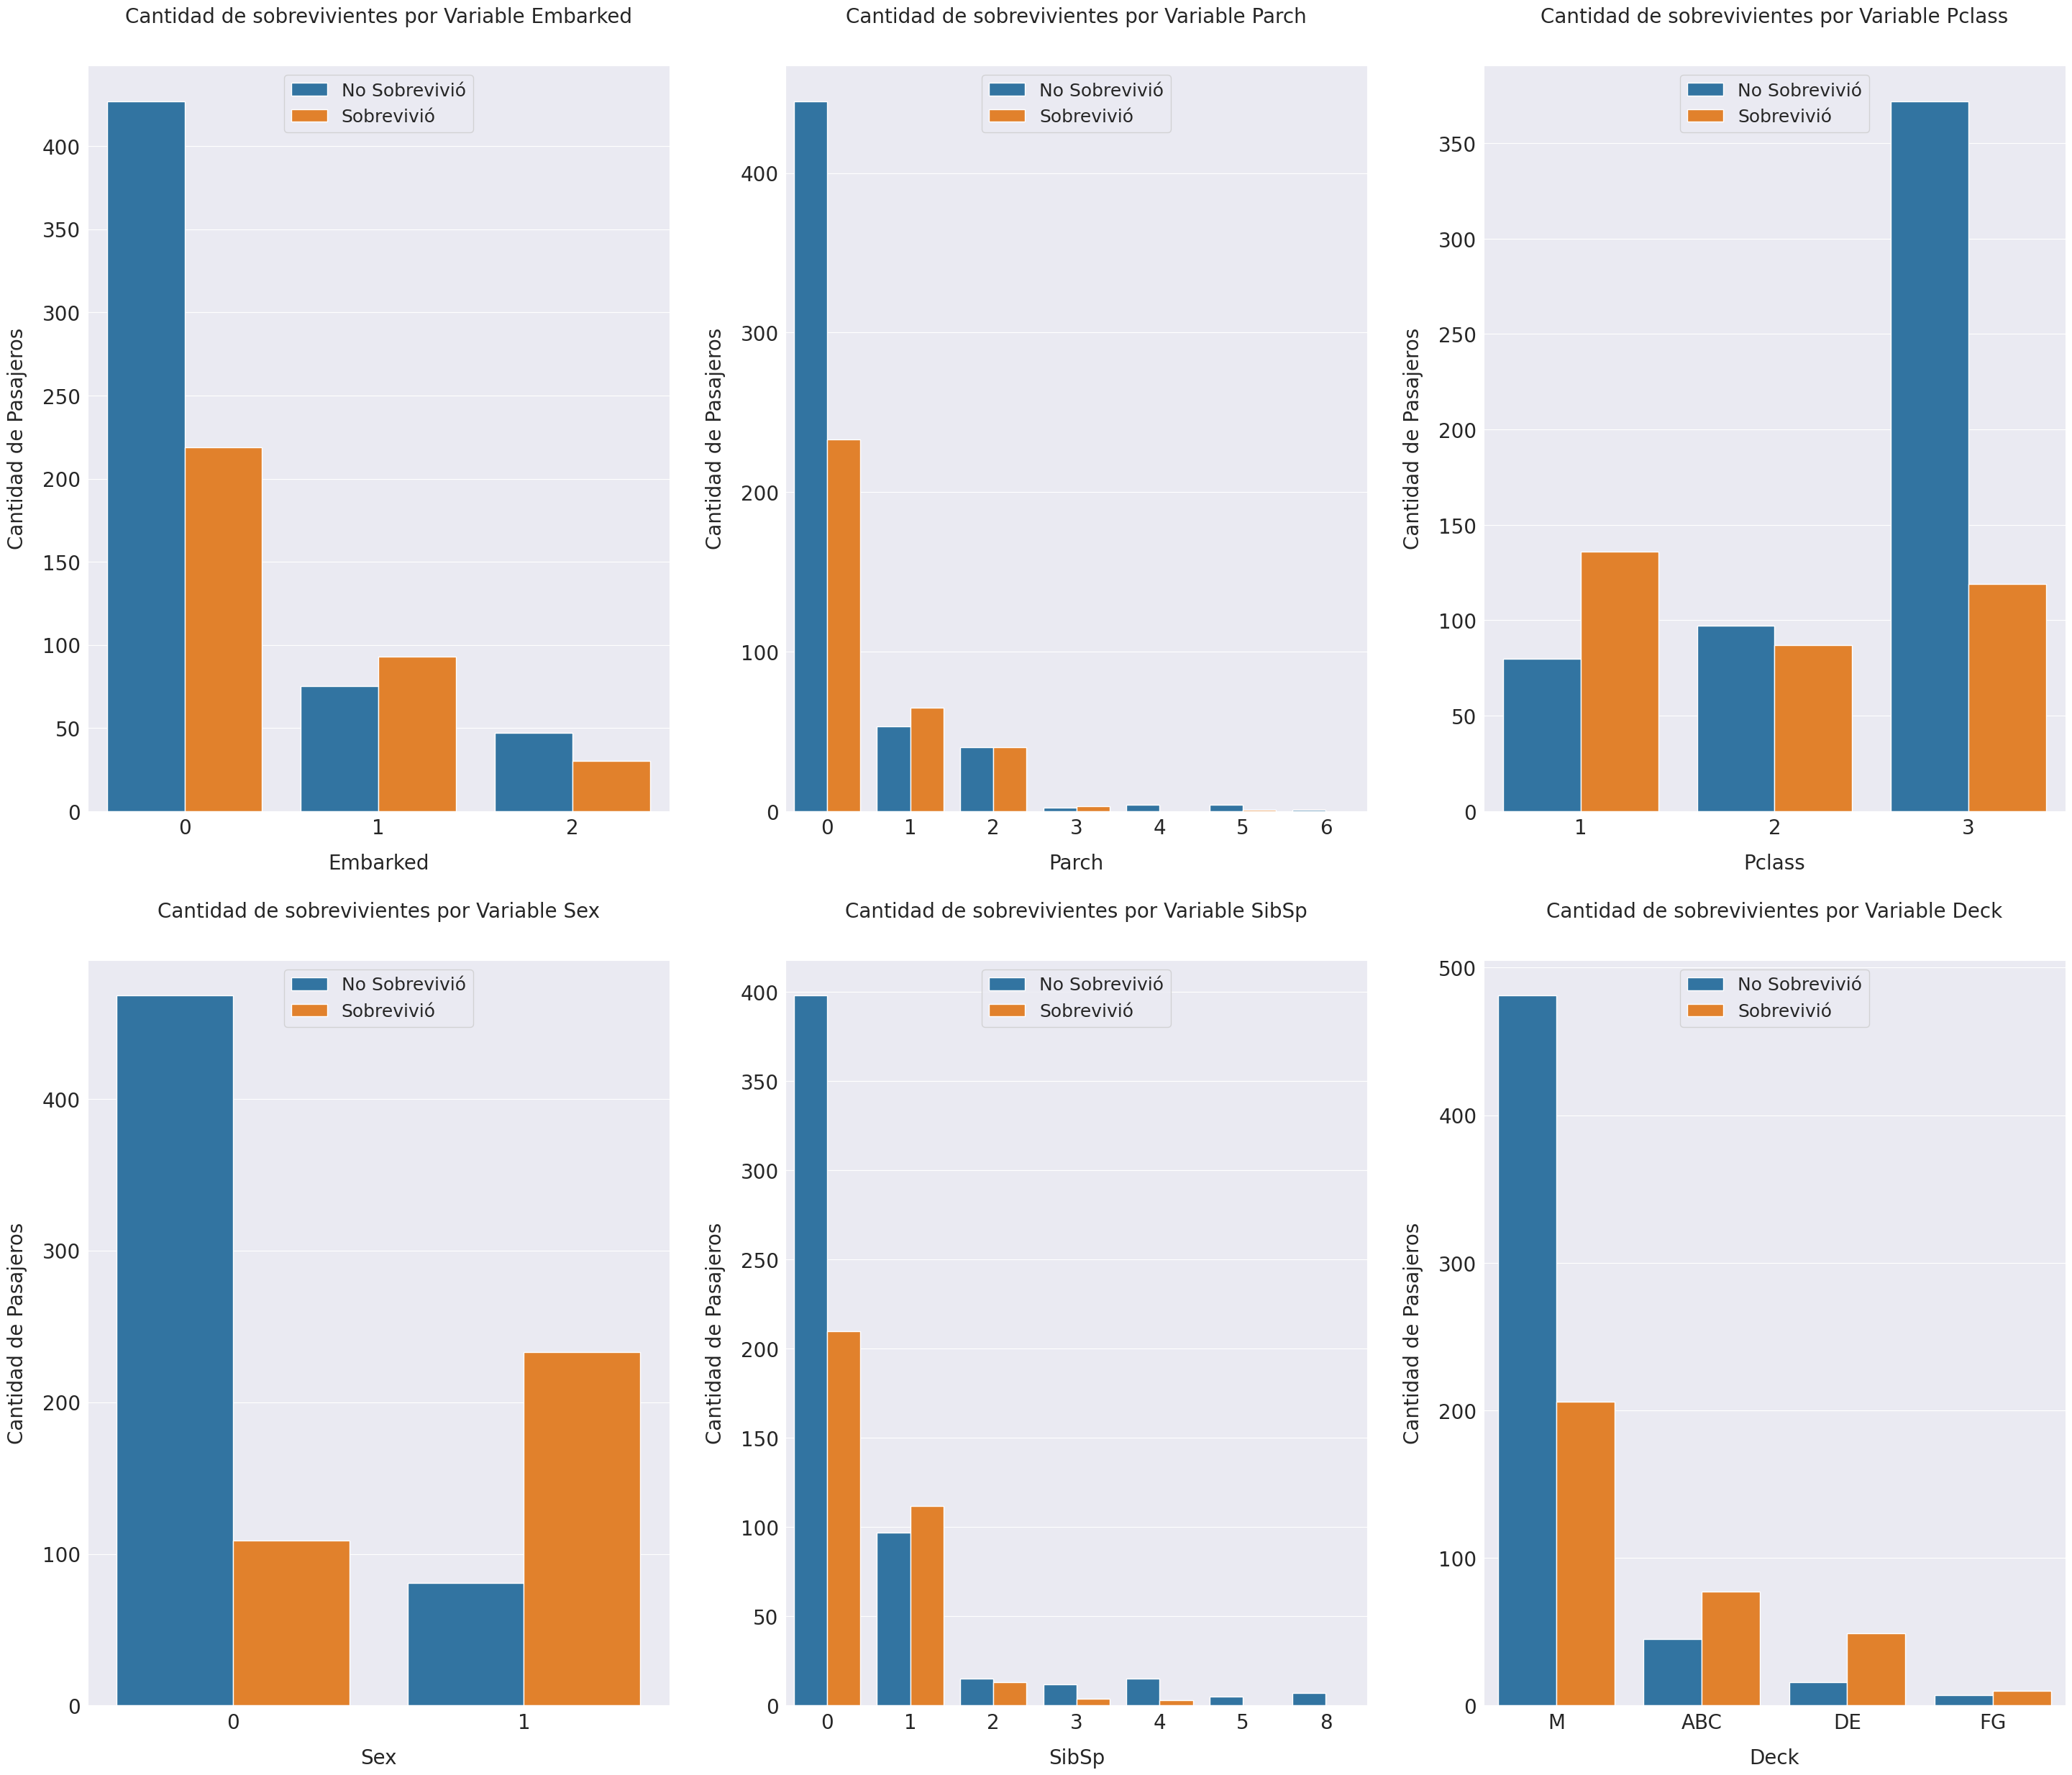

In [99]:
# Lista de características categóricas a analizar
cat_features = ['Embarked', 'Parch', 'Pclass', 'Sex', 'SibSp', 'Deck']

# Crear una figura con subplots de 2 columnas y 3 filas, y ajustar el tamaño de la figura
fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(20, 20))
plt.subplots_adjust(right=1.5, top=1.25)

# Iterar sobre las características categóricas para graficar
for i, feature in enumerate(cat_features, 1):
    # Crear un subplot en la posición correspondiente
    plt.subplot(2, 3, i)

    # Crear un gráfico de conteo para cada característica categórica, diferenciando por sobrevivencia
    sns.countplot(x=feature, hue='Survived', data=df_train)

    # Establecer la etiqueta del eje X con un tamaño de fuente de 20 y un padding de 15
    plt.xlabel('{}'.format(feature), size=20, labelpad=15)

    # Establecer la etiqueta del eje Y con un tamaño de fuente de 20 y un padding de 15
    plt.ylabel('Cantidad de Pasajeros', size=20, labelpad=15)

    # Ajustar el tamaño de las etiquetas del eje X e Y
    plt.tick_params(axis='x', labelsize=20)
    plt.tick_params(axis='y', labelsize=20)

    # Añadir leyenda al gráfico
    plt.legend(['No Sobrevivió', 'Sobrevivió'], loc='upper center', prop={'size': 18})

    # Añadir título al gráfico
    plt.title('Cantidad de sobrevivientes por Variable {}'.format(feature), size=20, y=1.05)

# Mostrar los gráficos
plt.show()


**Tarifa**

In [ ]:
df_all = concat_df(df_train, df_test)
df_all.head()

,Age,Deck,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket,age_cat,fare_cat,fare_range
0,22.0,M,0,7.2500,"Braund, Mr. Owen Harris",0,1,3,0,1,0.0,A/5 21171,1,2,"(-0.001, 7.25]"
1,38.0,ABC,1,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,1,1,1.0,PC 17599,2,2,"(56.496, 83.475]"
2,26.0,M,0,7.9250,"Heikkinen, Miss. Laina",0,3,3,1,0,1.0,STON/O2. 3101282,1,2,"(7.896, 8.05]"
3,35.0,ABC,0,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,1,1,1.0,113803,2,2,"(34.157, 56.496]"
4,35.0,M,0,8.0500,"Allen, Mr. William Henry",0,5,3,0,0,0.0,373450,2,2,"(7.896, 8.05]"


In [100]:
df_all['Fare'] = pd.qcut(df_all['Fare'], 13)

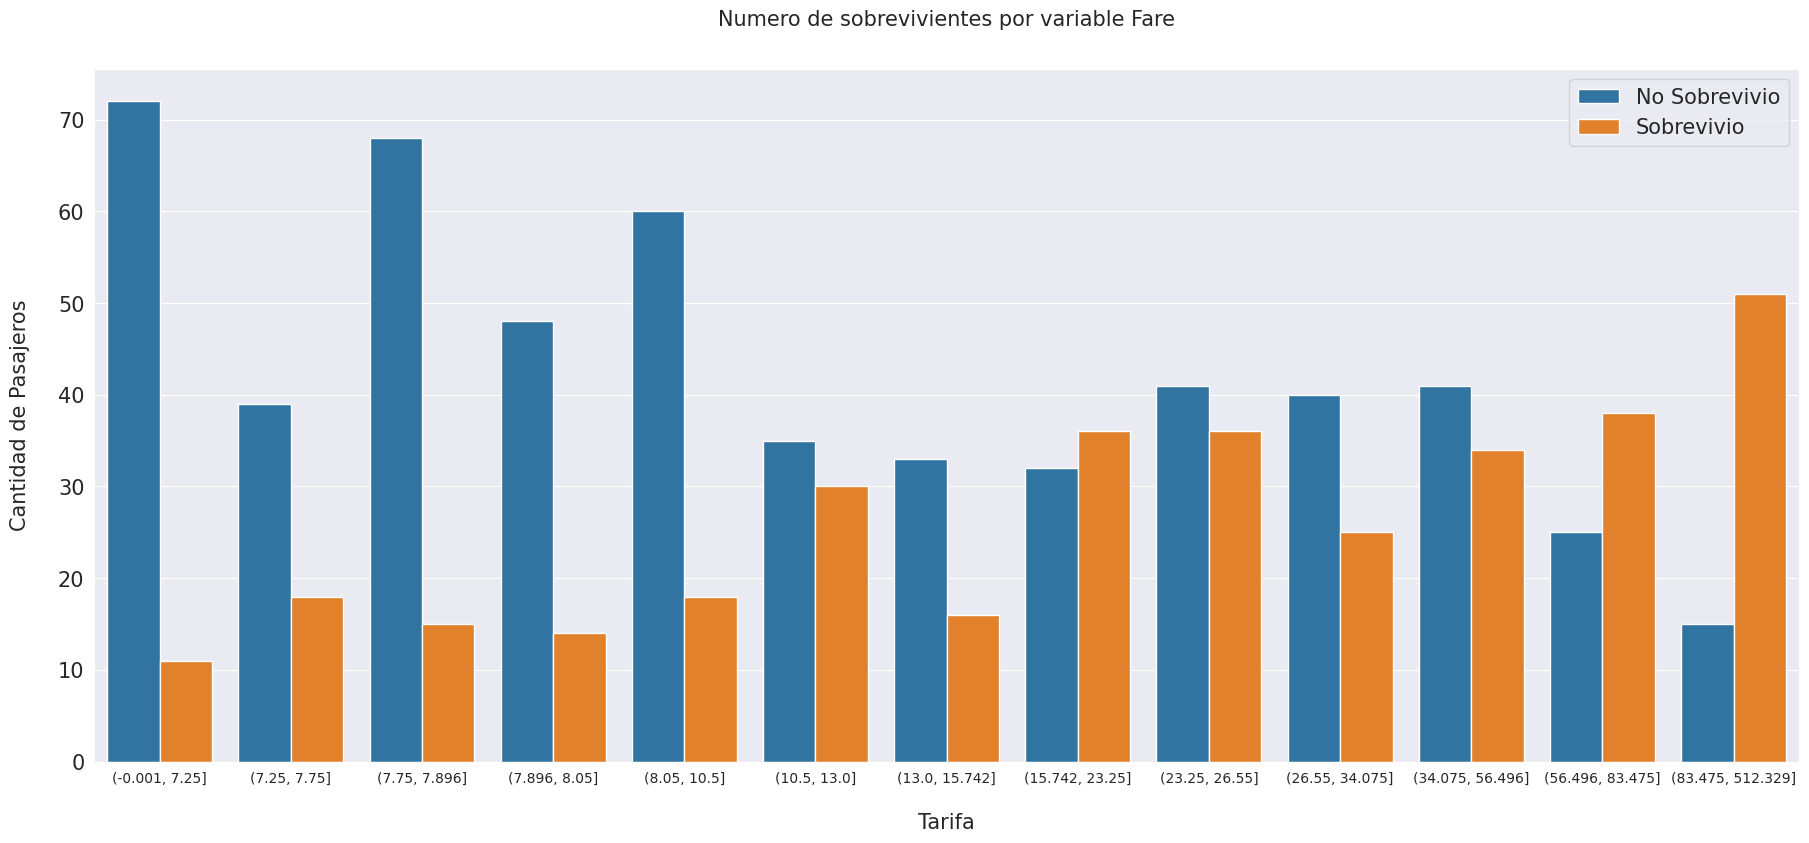

In [101]:
fig, axs = plt.subplots(figsize=(22, 9))
sns.countplot(x='Fare', hue='Survived', data=df_all)

plt.xlabel('Tarifa', size=15, labelpad=20)
plt.ylabel('Cantidad de Pasajeros', size=15, labelpad=20)
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=15)

plt.legend(['No Sobrevivio', 'Sobrevivio'], loc='upper right', prop={'size': 15})
plt.title('Numero de sobrevivientes por variable {}'.format('Fare'), size=15, y=1.05)

plt.show()

**Age**

In [102]:
df_all['Age'] = pd.qcut(df_all['Age'], 10)

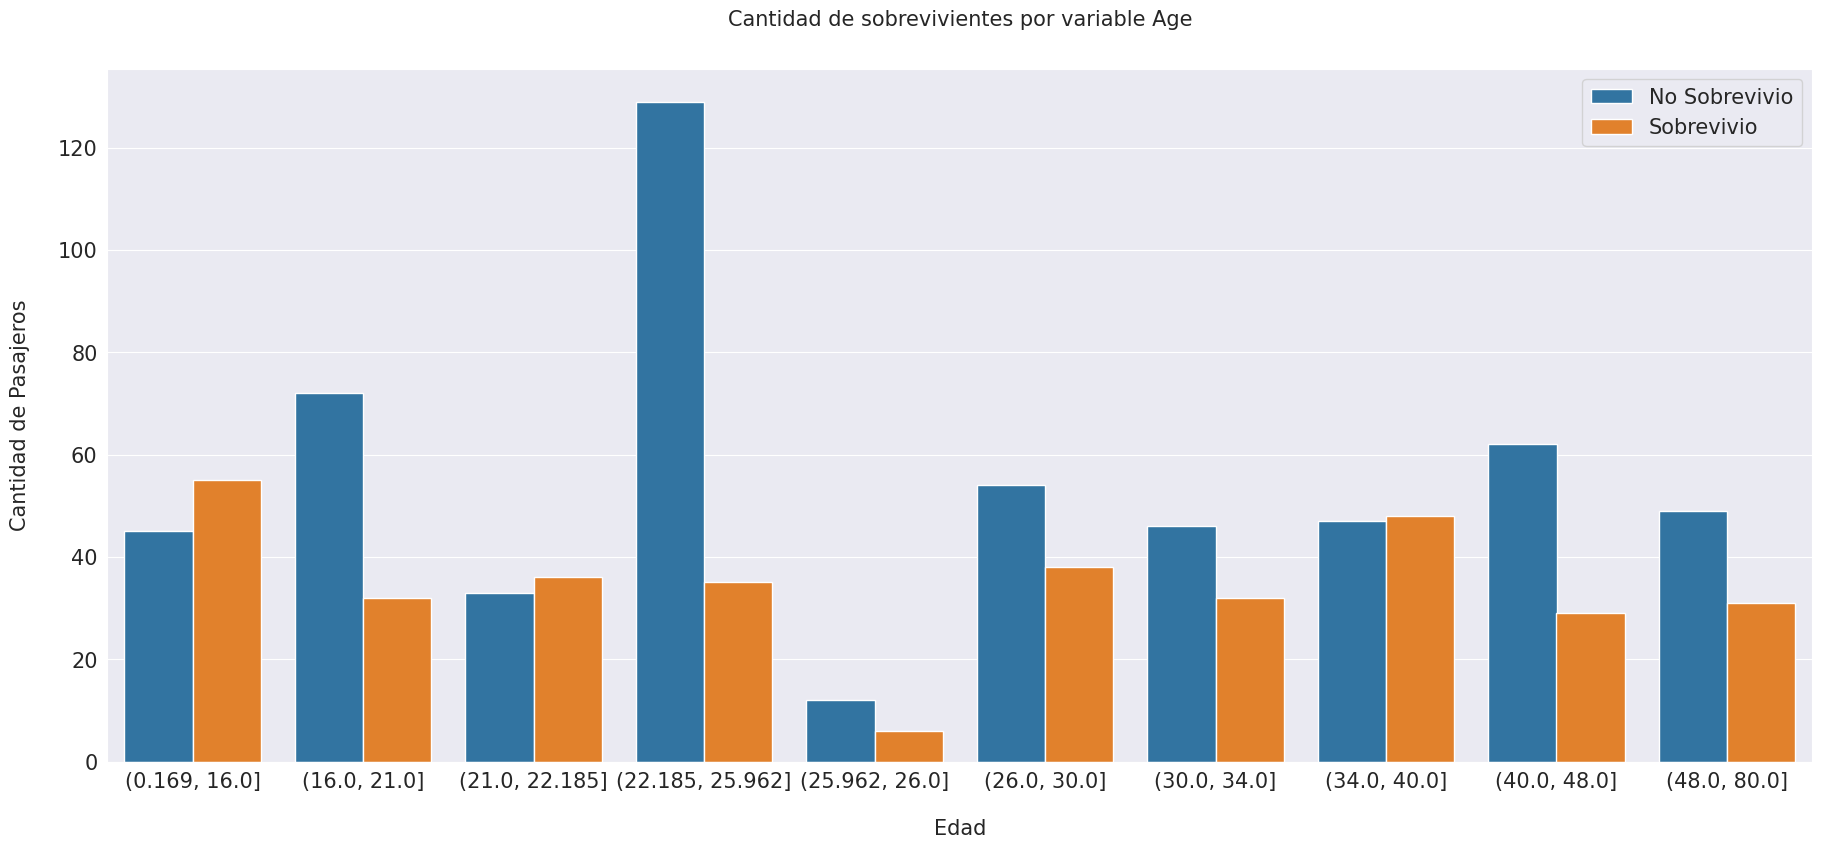

In [103]:
fig, axs = plt.subplots(figsize=(22, 9))
sns.countplot(x='Age', hue='Survived', data=df_all)

plt.xlabel('Edad', size=15, labelpad=20)
plt.ylabel('Cantidad de Pasajeros', size=15, labelpad=20)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)

plt.legend(['No Sobrevivio', 'Sobrevivio'], loc='upper right', prop={'size': 15})
plt.title('Cantidad de sobrevivientes por variable {}'.format('Age'), size=15, y=1.05)

plt.show()

**III FEATURE ENGINEERING**

En muchas actividades prácticas de ciencia de datos, el conjunto de datos contendrá variables categóricas. Estas variables normalmente se almacenan como valores de texto. Dado que el aprendizaje automático se basa en ecuaciones matemáticas, se generara un problema si mantenemos las variables categóricas como están. Muchos algoritmos admiten valores categóricos sin más manipulación, pero en esos casos, sigue siendo un tema de discusión sobre si codificar las variables o no. Los algoritmos que no soportan valores categóricos, en ese caso, utilizaran metodologías de codificación.

**Grouping binning**

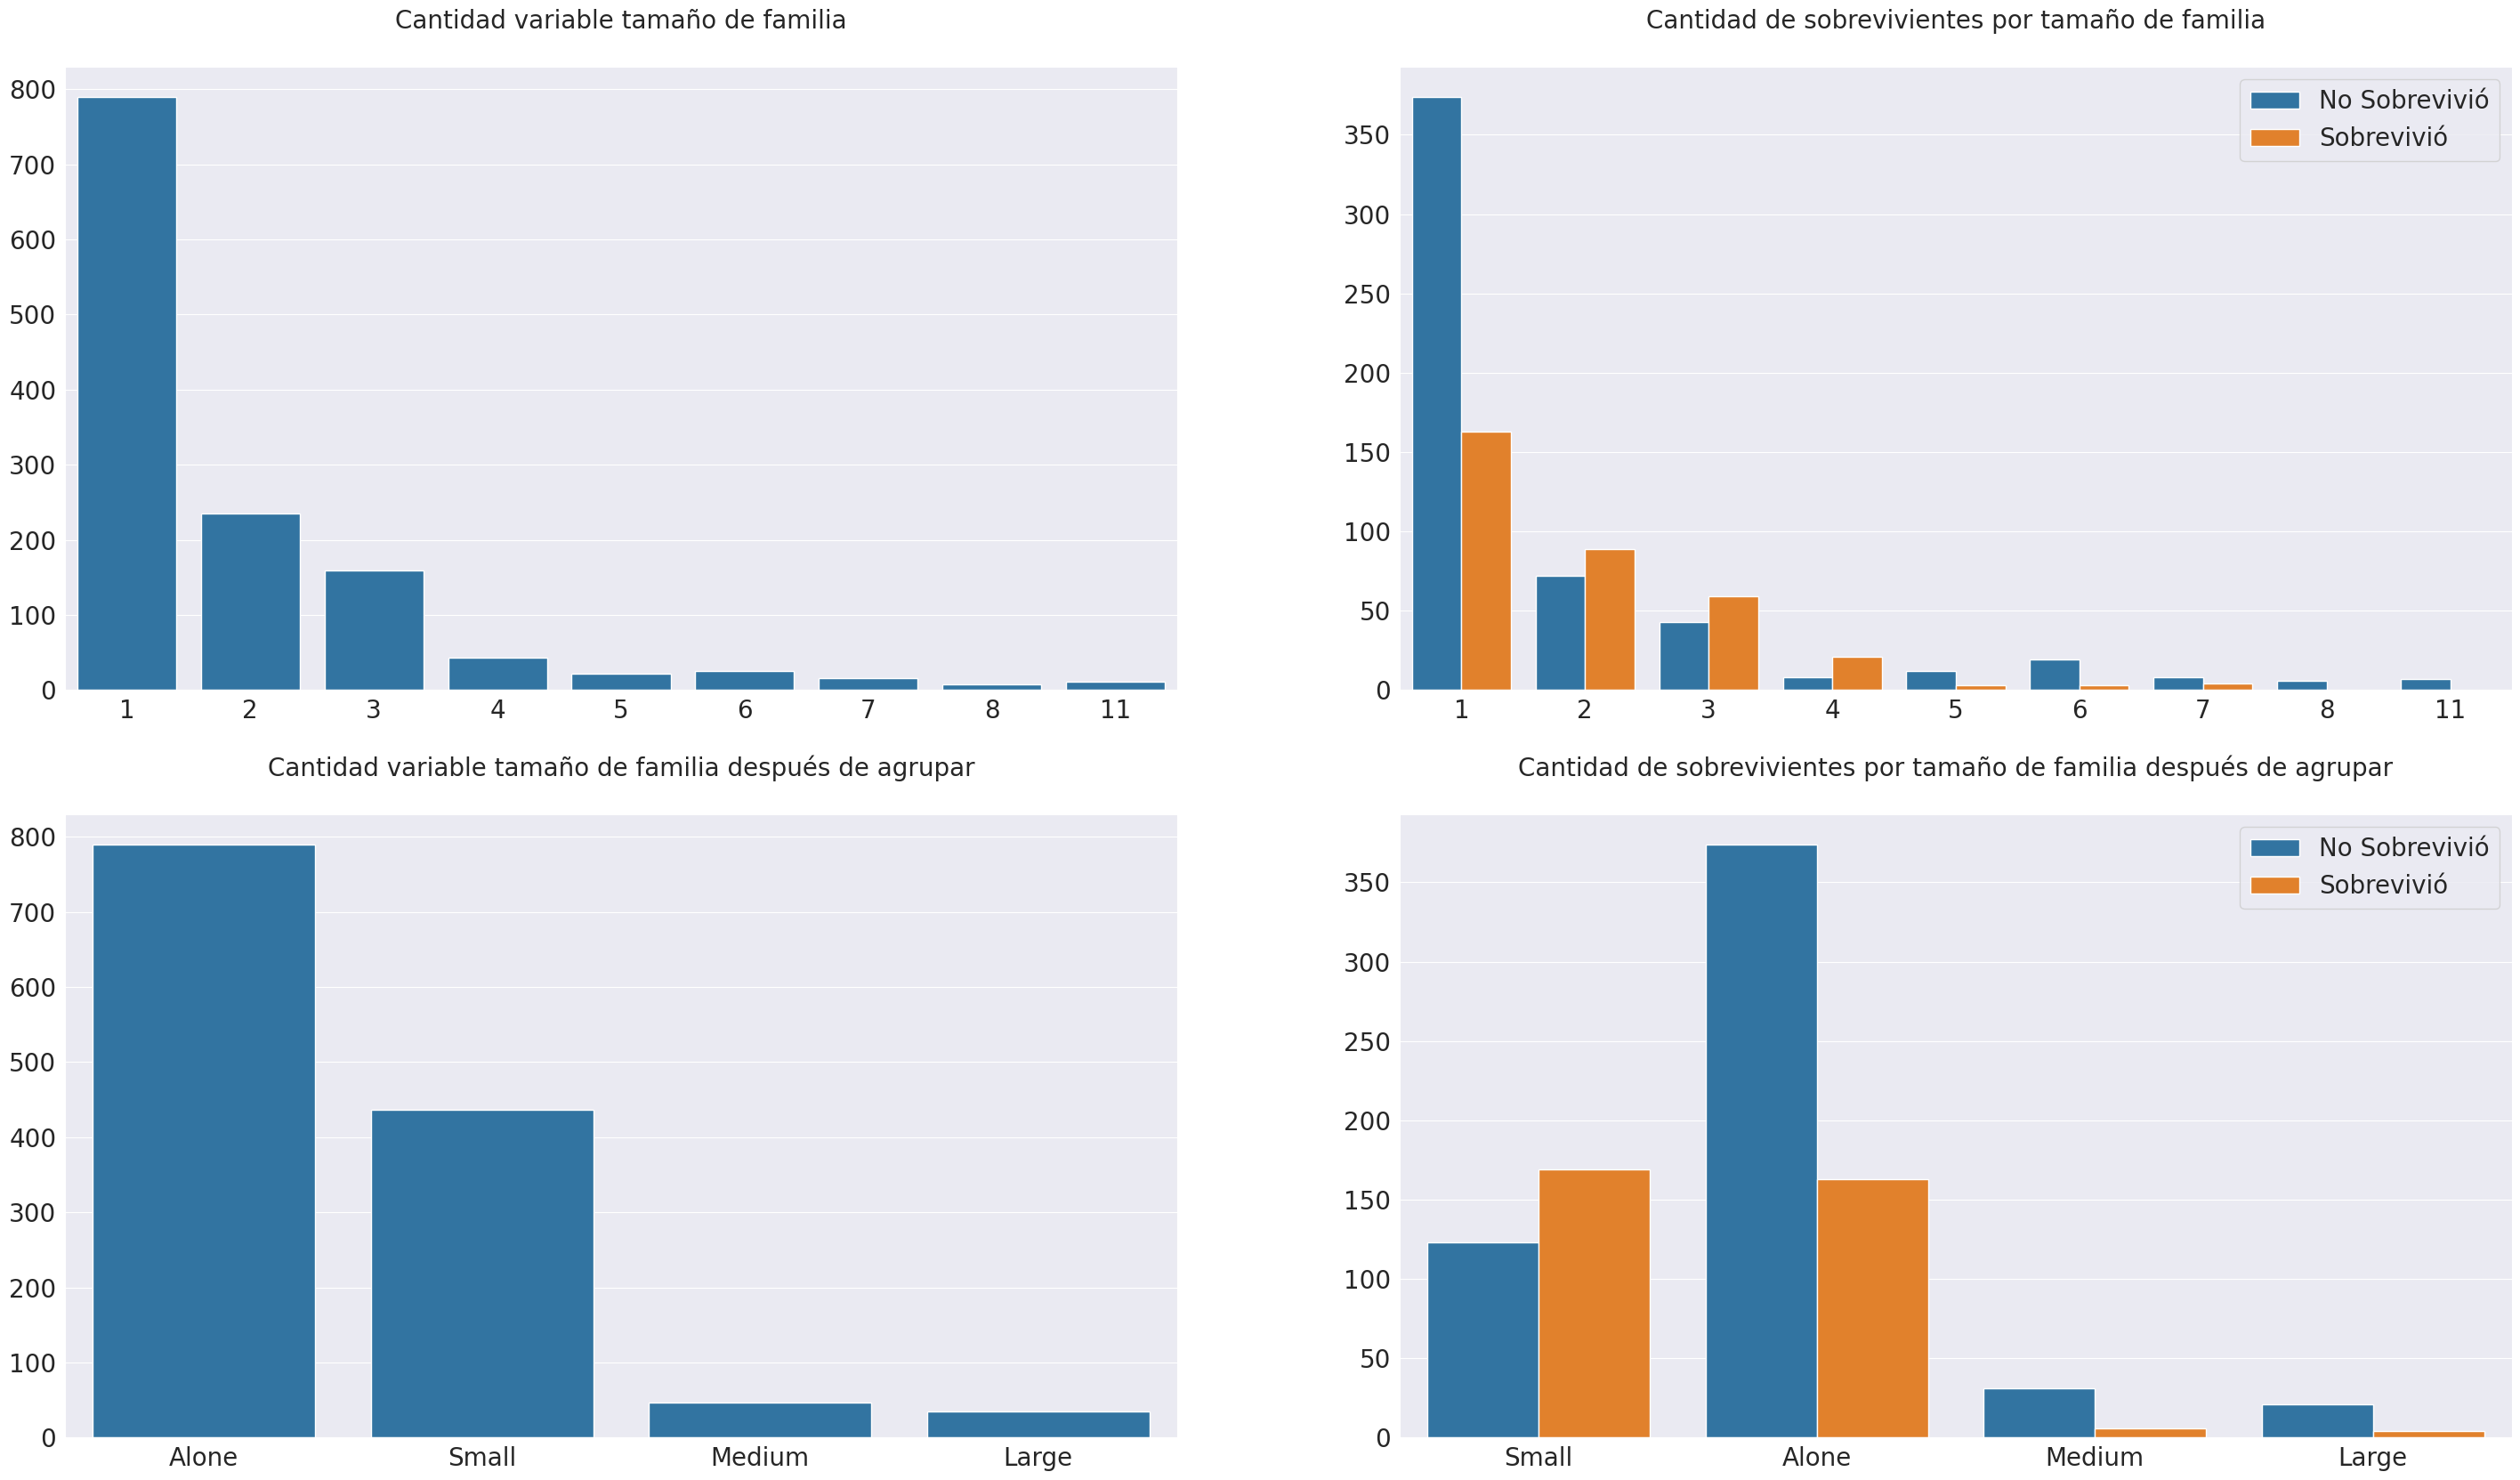

In [106]:
# Crear una nueva columna 'Family_Size' sumando 'SibSp', 'Parch' y 1
# Esto representa el tamaño total de la familia incluyendo al pasajero
df_all['Family_Size'] = df_all['SibSp'] + df_all['Parch'] + 1

# Crear una figura con subplots de 2 filas y 2 columnas y ajustar el tamaño de la figura
fig, axs = plt.subplots(figsize=(20, 20), ncols=2, nrows=2)
plt.subplots_adjust(right=1.5)

# Gráfico de barras para la distribución de 'Family_Size' en el conjunto de datos
sns.barplot(x=df_all['Family_Size'].value_counts().index,
            y=df_all['Family_Size'].value_counts().values, ax=axs[0][0])
# Gráfico de conteo para la distribución de 'Family_Size' diferenciando por supervivencia
sns.countplot(x='Family_Size', hue='Survived', data=df_all, ax=axs[0][1])

# Establecer títulos para los gráficos superiores
axs[0][0].set_title('Cantidad variable tamaño de familia', size=20, y=1.05)
axs[0][1].set_title('Cantidad de sobrevivientes por tamaño de familia', size=20, y=1.05)

# Crear un diccionario para agrupar los tamaños de familia en categorías
family_map = {1: 'Alone', 2: 'Small', 3: 'Small', 4: 'Small', 5: 'Medium', 6: 'Medium', 7: 'Large', 8: 'Large', 11: 'Large'}
# Crear una nueva columna 'Family_Size_Grouped' mapeando 'Family_Size' a las categorías definidas en family_map
df_all['Family_Size_Grouped'] = df_all['Family_Size'].map(family_map)

# Gráfico de barras para la distribución de 'Family_Size_Grouped' en el conjunto de datos
sns.barplot(x=df_all['Family_Size_Grouped'].value_counts().index,
            y=df_all['Family_Size_Grouped'].value_counts().values, ax=axs[1][0])
# Gráfico de conteo para la distribución de 'Family_Size_Grouped' diferenciando por supervivencia
sns.countplot(x='Family_Size_Grouped', hue='Survived', data=df_all, ax=axs[1][1])

# Establecer títulos para los gráficos inferiores
axs[1][0].set_title('Cantidad variable tamaño de familia después de agrupar', size=20, y=1.05)
axs[1][1].set_title('Cantidad de sobrevivientes por tamaño de familia después de agrupar', size=20, y=1.05)

# Ajustar la leyenda y los parámetros de los ejes en todos los gráficos
for i in range(2):
    axs[i][1].legend(['No Sobrevivió', 'Sobrevivió'], loc='upper right', prop={'size': 20})
    for j in range(2):
        axs[i][j].tick_params(axis='x', labelsize=20)
        axs[i][j].tick_params(axis='y', labelsize=20)
        axs[i][j].set_xlabel('')
        axs[i][j].set_ylabel('')

# Mostrar todos los gráficos
plt.show()


In [108]:
df_all['Ticket_Frequency'] = df_all.groupby('Ticket')['Ticket'].transform('count')

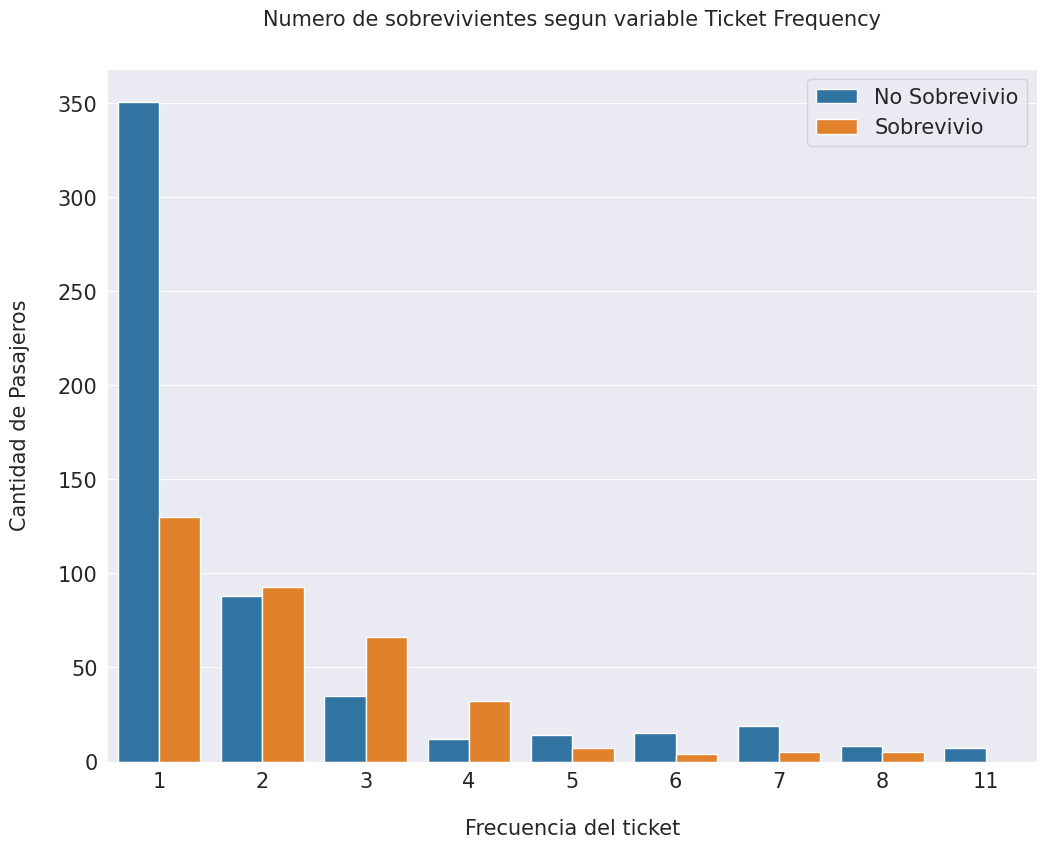

In [109]:
fig, axs = plt.subplots(figsize=(12, 9))
sns.countplot(x='Ticket_Frequency', hue='Survived', data=df_all)

plt.xlabel('Frecuencia del ticket', size=15, labelpad=20)
plt.ylabel('Cantidad de Pasajeros', size=15, labelpad=20)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)

plt.legend(['No Sobrevivio', 'Sobrevivio'], loc='upper right', prop={'size': 15})
plt.title('Numero de sobrevivientes segun variable {}'.format('Ticket Frequency'), size=15, y=1.05)

plt.show()

**Title & Is Married**

In [110]:
df_all['Title'] = df_all['Name'].str.split(', ', expand=True)[1].str.split('.', expand=True)[0]
df_all['Is_Married'] = 0
df_all['Is_Married'].loc[df_all['Title'] == 'Mrs'] = 1

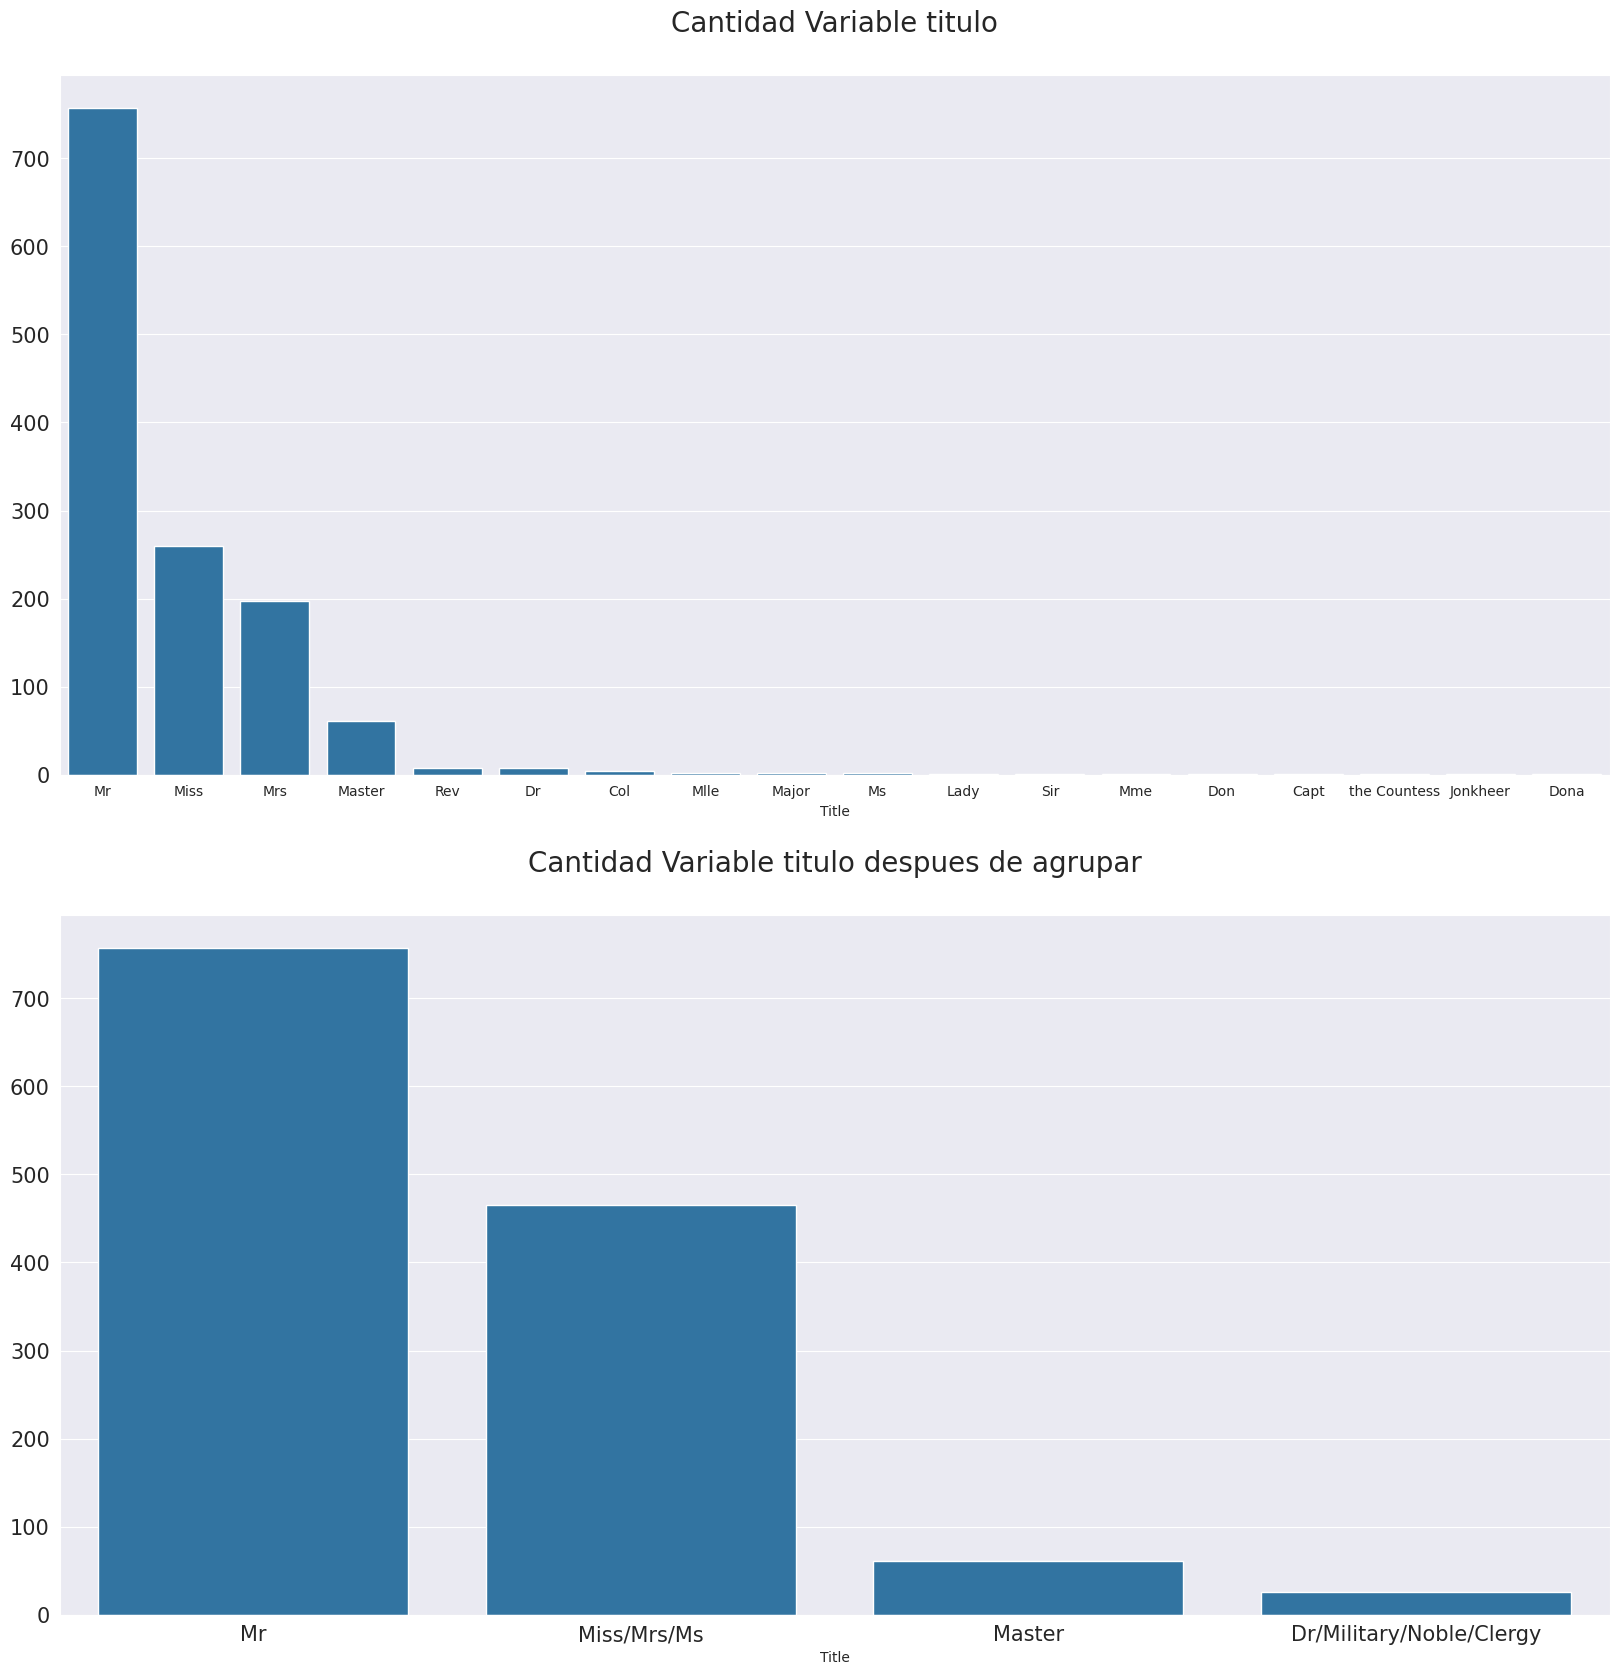

In [111]:
fig, axs = plt.subplots(nrows=2, figsize=(20, 20))
sns.barplot(x=df_all['Title'].value_counts().index, y=df_all['Title'].value_counts().values, ax=axs[0])

axs[0].tick_params(axis='x', labelsize=10)
axs[1].tick_params(axis='x', labelsize=15)

for i in range(2):
    axs[i].tick_params(axis='y', labelsize=15)

axs[0].set_title('Cantidad Variable titulo', size=20, y=1.05)

df_all['Title'] = df_all['Title'].replace(['Miss', 'Mrs','Ms', 'Mlle', 'Lady', 'Mme', 'the Countess', 'Dona'], 'Miss/Mrs/Ms')
df_all['Title'] = df_all['Title'].replace(['Dr', 'Col', 'Major', 'Jonkheer', 'Capt', 'Sir', 'Don', 'Rev'], 'Dr/Military/Noble/Clergy')

sns.barplot(x=df_all['Title'].value_counts().index, y=df_all['Title'].value_counts().values, ax=axs[1])
axs[1].set_title('Cantidad Variable titulo despues de agrupar', size=20, y=1.05)

plt.show()

**Target Encoding**

In [112]:
def extract_surname(data):

    families = []

    for i in range(len(data)):
        name = data.iloc[i]

        if '(' in name:
            name_no_bracket = name.split('(')[0]
        else:
            name_no_bracket = name

        family = name_no_bracket.split(',')[0]
        title = name_no_bracket.split(',')[1].strip().split(' ')[0]

        for c in string.punctuation:
            family = family.replace(c, '').strip()

        families.append(family)

    return families

df_all['Family'] = extract_surname(df_all['Name'])
df_train = df_all.loc[:890]
df_test = df_all.loc[891:]
dfs = [df_train, df_test]

In [113]:
# Creando una lista de familias y tickets que ocurren tanto en el conjunto de entrenamiento como en el de prueba
non_unique_families = [x for x in df_train['Family'].unique() if x in df_test['Family'].unique()]
non_unique_tickets = [x for x in df_train['Ticket'].unique() if x in df_test['Ticket'].unique()]

# Agrupando por 'Family' y 'Ticket' y calculando la mediana
df_family_survival_rate = df_train.groupby('Family')[['Survived', 'Family_Size']].median()
df_ticket_survival_rate = df_train.groupby('Ticket')[['Survived', 'Ticket_Frequency']].median()

# Diccionarios para almacenar las tasas de supervivencia por familia y por ticket
family_rates = {}
ticket_rates = {}

# Iterando sobre las filas de df_family_survival_rate
for i in range(len(df_family_survival_rate)):
    family = df_family_survival_rate.index[i]
    family_size = df_family_survival_rate.iloc[i, 1]
    if family in non_unique_families and family_size > 1:
        family_rates[family] = df_family_survival_rate.iloc[i, 0]

# Iterando sobre las filas de df_ticket_survival_rate
for i in range(len(df_ticket_survival_rate)):
    ticket = df_ticket_survival_rate.index[i]
    ticket_frequency = df_ticket_survival_rate.iloc[i, 1]
    if ticket in non_unique_tickets and ticket_frequency > 1:
        ticket_rates[ticket] = df_ticket_survival_rate.iloc[i, 0]

# Mostrando los resultados
print("Family Survival Rates:", family_rates)
print("Ticket Survival Rates:", ticket_rates)


Family Survival Rates: {'Abbott': 0.5, 'Aks': 1.0, 'Allison': 0.0, 'Andersson': 0.0, 'Angle': 1.0, 'Asplund': 1.0, 'Astor': 1.0, 'Becker': 1.0, 'Boulos': 0.0, 'Brown': 1.0, 'Bryhl': 0.0, 'Caldwell': 1.0, 'Caram': 0.0, 'Cardeza': 1.0, 'Cavendish': 0.0, 'Chaffee': 0.0, 'Chapman': 0.0, 'Christy': 1.0, 'Chronopoulos': 0.0, 'Clarke': 1.0, 'Compton': 1.0, 'Coutts': 1.0, 'Cribb': 0.0, 'Crosby': 0.5, 'Cumings': 1.0, 'Danbom': 0.0, 'Davidson': 0.0, 'Davies': 0.0, 'Davison': 1.0, 'Dean': 0.5, 'Dodge': 1.0, 'Douglas': 0.0, 'Drew': 1.0, 'Duran y More': 1.0, 'Elias': 0.0, 'Faunthorpe': 1.0, 'Ford': 0.0, 'Fortune': 0.5, 'Frauenthal': 1.0, 'FrolicherStehli': 1.0, 'Gale': 0.0, 'Giles': 0.0, 'Goldsmith': 1.0, 'Goodwin': 0.0, 'Greenfield': 1.0, 'Hansen': 0.0, 'Harder': 1.0, 'Hays': 1.0, 'Herman': 1.0, 'Hirvonen': 1.0, 'Hocking': 0.5, 'Hold': 0.0, 'Ilmakangas': 0.0, 'Johnston': 0.0, 'Karun': 1.0, 'Kenyon': 1.0, 'Kiernan': 0.0, 'Kimball': 1.0, 'Kink': 0.0, 'KinkHeilmann': 1.0, 'Klasen': 0.0, 'Lahtinen': 0

In [ ]:
# Creating a list of families and tickets that are occuring in both training and test set
'''non_unique_families = [x for x in df_train['Family'].unique() if x in df_test['Family'].unique()]
non_unique_tickets = [x for x in df_train['Ticket'].unique() if x in df_test['Ticket'].unique()]

df_family_survival_rate = df_train.groupby('Family')['Survived', 'Family','Family_Size'].median()
df_ticket_survival_rate = df_train.groupby('Ticket')['Survived', 'Ticket','Ticket_Frequency'].median()

family_rates = {}
ticket_rates = {}

for i in range(len(df_family_survival_rate)):
    # Checking a family exists in both training and test set, and has members more than 1
    if df_family_survival_rate.index[i] in non_unique_families and df_family_survival_rate.iloc[i, 1] > 1:
        family_rates[df_family_survival_rate.index[i]] = df_family_survival_rate.iloc[i, 0]

for i in range(len(df_ticket_survival_rate)):
    # Checking a ticket exists in both training and test set, and has members more than 1
    if df_ticket_survival_rate.index[i] in non_unique_tickets and df_ticket_survival_rate.iloc[i, 1] > 1:
        ticket_rates[df_ticket_survival_rate.index[i]] = df_ticket_survival_rate.iloc[i, 0]'''

"non_unique_families = [x for x in df_train['Family'].unique() if x in df_test['Family'].unique()]\nnon_unique_tickets = [x for x in df_train['Ticket'].unique() if x in df_test['Ticket'].unique()]\n\ndf_family_survival_rate = df_train.groupby('Family')['Survived', 'Family','Family_Size'].median()\ndf_ticket_survival_rate = df_train.groupby('Ticket')['Survived', 'Ticket','Ticket_Frequency'].median()\n\nfamily_rates = {}\nticket_rates = {}\n\nfor i in range(len(df_family_survival_rate)):\n    # Checking a family exists in both training and test set, and has members more than 1\n    if df_family_survival_rate.index[i] in non_unique_families and df_family_survival_rate.iloc[i, 1] > 1:\n        family_rates[df_family_survival_rate.index[i]] = df_family_survival_rate.iloc[i, 0]\n\nfor i in range(len(df_ticket_survival_rate)):\n    # Checking a ticket exists in both training and test set, and has members more than 1\n    if df_ticket_survival_rate.index[i] in non_unique_tickets and df_ticket_

In [114]:
mean_survival_rate = np.mean(df_train['Survived'])

train_family_survival_rate = []
train_family_survival_rate_NA = []
test_family_survival_rate = []
test_family_survival_rate_NA = []

for i in range(len(df_train)):
    if df_train['Family'][i] in family_rates:
        train_family_survival_rate.append(family_rates[df_train['Family'][i]])
        train_family_survival_rate_NA.append(1)
    else:
        train_family_survival_rate.append(mean_survival_rate)
        train_family_survival_rate_NA.append(0)

for i in range(len(df_test)):
    if df_test['Family'].iloc[i] in family_rates:
        test_family_survival_rate.append(family_rates[df_test['Family'].iloc[i]])
        test_family_survival_rate_NA.append(1)
    else:
        test_family_survival_rate.append(mean_survival_rate)
        test_family_survival_rate_NA.append(0)

df_train['Family_Survival_Rate'] = train_family_survival_rate
df_train['Family_Survival_Rate_NA'] = train_family_survival_rate_NA
df_test['Family_Survival_Rate'] = test_family_survival_rate
df_test['Family_Survival_Rate_NA'] = test_family_survival_rate_NA

train_ticket_survival_rate = []
train_ticket_survival_rate_NA = []
test_ticket_survival_rate = []
test_ticket_survival_rate_NA = []

for i in range(len(df_train)):
    if df_train['Ticket'][i] in ticket_rates:
        train_ticket_survival_rate.append(ticket_rates[df_train['Ticket'][i]])
        train_ticket_survival_rate_NA.append(1)
    else:
        train_ticket_survival_rate.append(mean_survival_rate)
        train_ticket_survival_rate_NA.append(0)

for i in range(len(df_test)):
    if df_test['Ticket'].iloc[i] in ticket_rates:
        test_ticket_survival_rate.append(ticket_rates[df_test['Ticket'].iloc[i]])
        test_ticket_survival_rate_NA.append(1)
    else:
        test_ticket_survival_rate.append(mean_survival_rate)
        test_ticket_survival_rate_NA.append(0)

df_train['Ticket_Survival_Rate'] = train_ticket_survival_rate
df_train['Ticket_Survival_Rate_NA'] = train_ticket_survival_rate_NA
df_test['Ticket_Survival_Rate'] = test_ticket_survival_rate
df_test['Ticket_Survival_Rate_NA'] = test_ticket_survival_rate_NA

In [ ]:
for df in [df_train, df_test]:
    df['Survival_Rate'] = (df['Ticket_Survival_Rate'] + df['Family_Survival_Rate']) / 2
    df['Survival_Rate_NA'] = (df['Ticket_Survival_Rate_NA'] + df['Family_Survival_Rate_NA']) / 2

**Feature transformation**

Label Encoding Non-Numerical Features

In [115]:
non_numeric_features = ['Embarked', 'Sex', 'Deck', 'Title', 'Family_Size_Grouped', 'Age', 'Fare']

for df in dfs:
    for feature in non_numeric_features:
        df[feature] = LabelEncoder().fit_transform(df[feature])

One-Hot Encoding the Categorical Features


In [116]:
cat_features = ['Pclass', 'Sex', 'Deck', 'Embarked', 'Title', 'Family_Size_Grouped']
encoded_features = []

for df in dfs:
    for feature in cat_features:
        encoded_feat = OneHotEncoder().fit_transform(df[feature].values.reshape(-1, 1)).toarray()
        n = df[feature].nunique()
        cols = ['{}_{}'.format(feature, n) for n in range(1, n + 1)]
        encoded_df = pd.DataFrame(encoded_feat, columns=cols)
        encoded_df.index = df.index
        encoded_features.append(encoded_df)

df_train = pd.concat([df_train, *encoded_features[:6]], axis=1)
df_test = pd.concat([df_test, *encoded_features[6:]], axis=1)

In [117]:
df_all = concat_df(df_train, df_test)
drop_cols = ['Deck', 'Embarked', 'Family', 'Family_Size', 'Family_Size_Grouped', 'Survived',
             'Name', 'Parch', 'PassengerId', 'Pclass', 'Sex', 'SibSp', 'Ticket', 'Title',
            'Ticket_Survival_Rate', 'Family_Survival_Rate', 'Ticket_Survival_Rate_NA', 'Family_Survival_Rate_NA']

df_all.drop(columns=drop_cols, inplace=True)

df_all.head()

,Age,Deck_1,Deck_2,Deck_3,Deck_4,Embarked_1,Embarked_2,Embarked_3,Family_Size_Freq,Family_Size_Grouped_1,...,Sex_1,Sex_2,Ticket_Frequency,Title_1,Title_2,Title_3,Title_4,age_cat,fare_cat,fare_range
0,2,0.0,0.0,0.0,1.0,1.0,0.0,0.0,235,0.0,...,1.0,0.0,1,0.0,0.0,0.0,1.0,1,2,"(-0.001, 7.25]"
1,7,1.0,0.0,0.0,0.0,0.0,1.0,0.0,235,0.0,...,0.0,1.0,2,0.0,0.0,1.0,0.0,2,2,"(56.496, 83.475]"
2,4,0.0,0.0,0.0,1.0,1.0,0.0,0.0,790,1.0,...,0.0,1.0,1,0.0,0.0,1.0,0.0,1,2,"(7.896, 8.05]"
3,7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,235,0.0,...,0.0,1.0,2,0.0,0.0,1.0,0.0,2,2,"(34.157, 56.496]"
4,7,0.0,0.0,0.0,1.0,1.0,0.0,0.0,790,1.0,...,1.0,0.0,1,0.0,0.0,0.0,1.0,2,2,"(7.896, 8.05]"
